<a href="https://colab.research.google.com/github/sahil-walunj/Formal_verification_of_Deep_Neural_Networks/blob/main/CNN_MILP_VGG16_MaxPooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gurobipy
!pip install tensorflow
!pip install numpy
!pip install matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Flatten, Dense,MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [ ]:
# params = {
#     "WLSACCESSID":"4d102d43-af47-4767-8294-5c56341d0f8a",
#     "WLSSECRET":"dae74acb-a20b-4fec-92b6-9737c8626ca6",
#     "LICENSEID":2778199
# }
# env = gp.Env(params=params)

In [ ]:
print("--- 1. Loading and Preprocessing MNIST Data ---")
(x_train, y_train), (x_test, y_test) = mnist.load_data()



# Normalize and add channel dimension (for CNN)
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)


x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Save original labels
y_test_orig = y_test

# Convert labels to one-hot encoding for training
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

--- 1. Loading and Preprocessing MNIST Data ---
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [ ]:
N_LAYERS = 2
print(f"Model will be built with N={N_LAYERS} convolutional layers.")

Model will be built with N=2 convolutional layers.


In [ ]:
def model_archi_cnn(num_conv_layers):

    inp = Input(shape=(28, 28, 1), name="input")
    x = inp # Initialize x with the input

    # --- Loop to create N CNN Blocks ---
    for i in range(1, num_conv_layers + 1):
        filters = 4 * (2 ** (i-1))   # 4 → 8 → 16
        x = Conv2D(filters, (3, 3), padding='same', name=f"conv{i}_1")(x)
        x = Activation('relu')(x)

        x = Conv2D(filters, (3, 3), padding='same', name=f"conv{i}_2")(x)
        x = Activation('relu')(x)

        x = MaxPooling2D((2,2))(x)

    # Flatten the output of the last conv block
    x = Flatten(name="flatten")(x)

    outputs = Dense(10,activation='softmax',name="output_layer")(x)

    return Model(inputs=inp, outputs=outputs)


model_cnn = model_archi_cnn(num_conv_layers=N_LAYERS)


model_cnn.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 28, 28, 4)         40        
                                                                 
 activation (Activation)     (None, 28, 28, 4)         0         
                                                                 
 conv1_2 (Conv2D)            (None, 28, 28, 4)         148       
                                                                 
 activation_1 (Activation)   (None, 28, 28, 4)         0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 4)         0         
 D)                                                              
                                                           

In [ ]:
print("\n--- 2. Compiling CNN Model ---")

# Use a standard, safe learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_cnn.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=optimizer,
    metrics=['accuracy']
)
print("\nModel compiled successfully.")


--- 2. Compiling CNN Model ---

Model compiled successfully.


In [ ]:
print("\n--- 3. Training CNN Model ---")

history = model_cnn.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test)
)

print("\nTraining complete.")


--- 3. Training CNN Model ---
Epoch 1/10


469/469 [==============================] - 3s 5ms/step - loss: 0.4659 - accuracy: 0.8599 - val_loss: 0.1513 - val_accuracy: 0.9567
Epoch 2/10
469/469 [==============================] - 2s 5ms/step - loss: 0.1335 - accuracy: 0.9596 - val_loss: 0.0917 - val_accuracy: 0.9719
Epoch 3/10
469/469 [==============================] - 3s 5ms/step - loss: 0.0948 - accuracy: 0.9711 - val_loss: 0.0726 - val_accuracy: 0.9762
Epoch 4/10
469/469 [==============================] - 3s 6ms/step - loss: 0.0776 - accuracy: 0.9760 - val_loss: 0.0635 - val_accuracy: 0.9787
Epoch 5/10
469/469 [==============================] - 3s 5ms/step - loss: 0.0675 - accuracy: 0.9792 - val_loss: 0.0647 - val_accuracy: 0.9783
Epoch 6/10
469/469 [==============================] - 3s 6ms/step - loss: 0.0621 - accuracy: 0.9802 - val_loss: 0.0531 - val_accuracy: 0.9828
Epoch 7/10
469/469 [==============================] - 3s 6ms/step - loss: 0.0566 - accuracy: 0.9827 - val_loss: 0.0

In [ ]:
test_loss, test_acc = model_cnn.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0429 - accuracy: 0.9852
Test Loss: 0.04288654401898384
Test Accuracy: 0.9851999878883362


In [ ]:
print(f"\n--- 4. Saving CNN Weights for {N_LAYERS} Layers to cnn_net/ ---")
os.makedirs("cnn_net", exist_ok=True)


def get_layer(name):
    return model_cnn.get_layer(name)

# save weights for N layers
for i in range(1, N_LAYERS + 1):
    conv_1_name = f"conv{i}_1"
    conv_2_name = f"conv{i}_2"

    print(f"Saving weights for {conv_1_name} and {conv_2_name}...")
    # print(get_layer(conv_1_name).get_weights()[0])
    # print(get_layer(conv_2_name).get_weights()[1])

    # Save Conv{i}
    np.save(f"cnn_net/{conv_1_name}.weight", get_layer(conv_1_name).get_weights()[0]) # Kernel
    np.save(f"cnn_net/{conv_1_name}.bias",   get_layer(conv_1_name).get_weights()[1]) # Bias

    # Save BN{i}
    np.save(f"cnn_net/{conv_2_name}.weight",   get_layer(conv_2_name).get_weights()[0]) #Kernel
    np.save(f"cnn_net/{conv_2_name}.bias",     get_layer(conv_2_name).get_weights()[1]) #bias


# Save Output Layer
np.save("cnn_net/output_layer.weight", get_layer("output_layer").get_weights()[0])
np.save("cnn_net/output_layer.bias",   get_layer("output_layer").get_weights()[1])
print(get_layer("output_layer").get_weights()[0].shape)
print(get_layer("output_layer").get_weights()[1].shape)

print("All weights saved.")


--- 4. Saving CNN Weights for 2 Layers to cnn_net/ ---
Saving weights for conv1_1 and conv1_2...
Saving weights for conv2_1 and conv2_2...
(392, 10)
(10,)
All weights saved.


In [ ]:
# print("\n--- 5. Setting up Gurobi Environment and Helpers ---")

# env.setParam('OutputFlag', 0)   # avoids unnecessary outputs
def load_weight_cnn(name):
    return np.load(os.path.join("cnn_net", name + ".npy"))

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


os.makedirs("cnn_failures", exist_ok=True)

# --- Clear old failure images first ---
print("--- 7a. Clearing old failure images ---")
for f in os.listdir("cnn_failures"):
    os.remove(os.path.join("cnn_failures", f))
print("Old files cleared.")

def generate_cutout_images_cnn(model_cnn, x_test, y_test_orig, num_to_find=10):
# def generate_cutout_images_cnn(model_cnn, x_test, y_test_orig):

    print(f"\n--- 7b. Generating up to {num_to_find} Cutout Failure Images ---")
    # print(f"\n--- 7b. Generating up to Cutout Failure Images ---")

    # cutout properties
    grid_size = 4
    x_centre, y_centre = 14, 14 # Center of 28x28
    grid_bound = grid_size // 2
    start_x, start_y = x_centre - grid_bound, y_centre - grid_bound
    end_x, end_y = start_x + grid_size, start_y + grid_size

    images_found = 0

    # Get predictions for the whole test set at once
    predictions_orig = model_cnn.predict(x_test, verbose=0)
    predicted_labels_orig = np.argmax(predictions_orig, axis=1)

    for i in range(len(x_test)):
        original_image = x_test[i]
        true_label = y_test_orig[i]

        # Step 1: Check if the original image is classified CORRECTLY ---
        if predicted_labels_orig[i] == true_label:

            # Step 2: Create the cutout image ---
            cutout_image = np.copy(original_image)
            cutout_image[start_x:end_x, start_y:end_y, 0] = 0.0 # Apply cutout

            # Step 3: Check if the cutout image is classified INCORRECTLY ---
            image_for_pred = np.expand_dims(cutout_image, axis=0)
            pred_cutout = model_cnn.predict(image_for_pred, verbose=0)
            pred_label_cutout = np.argmax(pred_cutout)

            if pred_label_cutout != true_label:
                print(f"Found a failure image at index {i}! (True: {true_label}, Failed Pred: {pred_label_cutout})")

                # --- Step 4: Save the cutout image and its label ---
                save_path_img = os.path.join("cnn_failures", f"failed_image_{i}.npy")
                save_path_lbl = os.path.join("cnn_failures", f"failed_label_{i}.npy")

                np.save(save_path_img, cutout_image) # Save the 28x28x1 cutout image
                np.save(save_path_lbl, np.array(true_label)) # Save the true label

                images_found += 1

                # --- Plot for visual confirmation (optional, can be commented out) ---
                # plt.figure(figsize=(8, 4))
                # plt.subplot(1, 2, 1)
                # plt.imshow(original_image.squeeze(), cmap='gray')
                # plt.title(f"Original (Pred: {predicted_labels_orig[i]})")
                # plt.axis('off')
                # plt.subplot(1, 2, 2)
                # plt.imshow(cutout_image.squeeze(), cmap='gray')
                # plt.title(f"Cutout (Pred: {pred_label_cutout})")
                # plt.axis('off')
                # plt.show()
                # --- End optional plot ---

            if images_found >= num_to_find:
                print(f"\nReached target of {num_to_find} images.")
                break

    if images_found == 0:
        print("\nNo failure images found with this cutout.")
    else:
        print(f"\nSaved {images_found} failure image(s) to 'cnn_failures/' directory.")

# --- Run the function to find n failure images ---
generate_cutout_images_cnn(model_cnn, x_test, y_test_orig, num_to_find=100)
# generate_cutout_images_cnn(model_cnn, x_test, y_test_orig)

--- 7a. Clearing old failure images ---
Old files cleared.

--- 7b. Generating up to 100 Cutout Failure Images ---
Found a failure image at index 9! (True: 9, Failed Pred: 7)
Found a failure image at index 18! (True: 3, Failed Pred: 8)
Found a failure image at index 20! (True: 9, Failed Pred: 7)
Found a failure image at index 44! (True: 3, Failed Pred: 2)
Found a failure image at index 63! (True: 3, Failed Pred: 2)
Found a failure image at index 73! (True: 9, Failed Pred: 7)
Found a failure image at index 78! (True: 9, Failed Pred: 7)
Found a failure image at index 87! (True: 3, Failed Pred: 7)
Found a failure image at index 107! (True: 1, Failed Pred: 4)
Found a failure image at index 151! (True: 9, Failed Pred: 8)
Found a failure image at index 184! (True: 8, Failed Pred: 2)
Found a failure image at index 200! (True: 3, Failed Pred: 8)
Found a failure image at index 213! (True: 3, Failed Pred: 7)
Found a failure image at index 233! (True: 8, Failed Pred: 7)
Found a failure image at i

In [ ]:
print("\n6. Defining Gurobi Encoding Function")

def model_encoding(x_image, true_label, num_conv_layers,tauType):

    # if env is None:
    #     print("Gurobi environment not initialized. Skipping encoding.")
    #     return (None, None)
    #it tau type is =0 it means tau should be binary and if it is 1 tau should be continuos
    # 1. Load all weights
    conv_params = []
    epsilon = 1e-5

    for i in range(1, num_conv_layers + 1):
        w_conv_1 = load_weight_cnn(f"conv{i}_1.weight")
        b_conv_1 = load_weight_cnn(f"conv{i}_1.bias")


        w_conv_2 = load_weight_cnn(f"conv{i}_2.weight")
        b_conv_2 = load_weight_cnn(f"conv{i}_2.bias")
        conv_params.append(((w_conv_1, b_conv_1),(w_conv_2, b_conv_2)))

    w_out = load_weight_cnn("output_layer.weight")
    b_out = load_weight_cnn("output_layer.bias")

    # 3. Create Gurobi Model ---
    m = gp.Model(f"CNN_Corrective_Encoding_ReLU_N{num_conv_layers}")

    # 4 Define Input and Perturbation (Additive Tau) ---
    grid_size = 4
    x_centre, y_centre = 14, 14
    grid_bound = grid_size // 2
    start_x, start_y = x_centre - grid_bound, y_centre - grid_bound

    if(tauType == 0):
      tau = m.addMVar((grid_size, grid_size), vtype=GRB.BINARY, name="tau")
    else:
      tau = m.addMVar((grid_size, grid_size), lb=0,ub=1,vtype=GRB.CONTINUOUS, name="tau")
    x_perturbed = m.addMVar((28, 28, 1), lb=0, ub=1, name="x_perturbed")

    for i in range(28):
        for j in range(28):
            if not (start_x <= i < start_x + grid_size and start_y <= j < start_y + grid_size):
                m.addConstr(x_perturbed[i, j, 0] == x_image[i, j, 0])

    for i in range(grid_size):
        for j in range(grid_size):
            m.addConstr(x_perturbed[start_x + i, start_y + j, 0] ==
                        x_image[start_x + i, start_y + j, 0] + tau[i, j])


    # 5. Encode Layer by Layer

    activation_outputs = [] # List to store the output vars of each block
    current_input = x_perturbed # Start with the main input

    for i in range(num_conv_layers):
        # print(f"Encoding Layer {i+1} (ReLU)...") # Commented out

        # get weights for this blocks conv2D layer1
        w_conv_1, b_conv_1 = conv_params[i][0]

        nr, nc, Cin = current_input.shape
        kh, kw, Cin_w, Cout = w_conv_1.shape
        # Define Gurobi vars for this layer's outputs
        conv_1_out = m.addMVar((nr, nc, Cout), lb=-GRB.INFINITY, name=f"conv{i+1}_1_out")
        act_1_out  = m.addMVar((nr, nc, Cout), lb=0, name=f"act_1_{i+1}_out")

        # handling the padding
        input_padded = m.addMVar((nr+2, nc+2, Cin), lb=-GRB.INFINITY, name=f"input_1_padded{i+1}")
        # top and bottom rows
        m.addConstr(input_padded[0, :, :] == 0)
        m.addConstr(input_padded[nr+1, :, :] == 0)

        # left and right columns
        m.addConstr(input_padded[:, 0, :] == 0)
        m.addConstr(input_padded[:, nc+1, :] == 0)

        # center
        m.addConstr(input_padded[1:-1, 1:-1, :] == current_input[:, :, :])

        # Add constraints for all 28x28 neurons in this block
        for r in range(nr): # row
            for c in range(nc): # col
                for k in range(Cout):#channel number
                  # 1. Conv operation (W*x + b)
                  conv_sum = gp.LinExpr(b_conv_1[k])
                  for ci in range(Cin):
                    for di in range(3):
                      for dj in range(3):
                        conv_sum += (w_conv_1[di, dj, ci, k] *input_padded[r + di, c + dj, ci])

                  m.addConstr(conv_1_out[r, c, k] == conv_sum)
                  # 3. ReLU Activation
                  m.addGenConstrMax(act_1_out[r, c, k], [conv_1_out[r, c, k], 0.0], name=f"relu_1_{i+1}_{r}_{c}_{k}")


        activation_outputs.append(act_1_out)
        current_input = act_1_out

        #same block's second layer
        w_conv_2, b_conv_2 = conv_params[i][1]
        nr, nc, Cin = current_input.shape
        kh, kw, Cin_w, Cout = w_conv_2.shape
        # Define Gurobi vars for this layer's outputs
        conv_2_out = m.addMVar((nr, nc, Cout), lb=-GRB.INFINITY, name=f"conv{i+1}_2_out")
        act_2_out  = m.addMVar((nr, nc, Cout), lb=0, name=f"act_2_{i+1}_out")

        # handling the padding
        input_padded = m.addMVar((nr+2, nc+2, Cin), lb=-GRB.INFINITY, name=f"input_2_padded{i+1}")
        # top and bottom rows
        m.addConstr(input_padded[0, :, :] == 0)
        m.addConstr(input_padded[nr+1, :, :] == 0)

        # left and right columns
        m.addConstr(input_padded[:, 0, :] == 0)
        m.addConstr(input_padded[:, nc+1, :] == 0)

        # center
        m.addConstr(input_padded[1:-1, 1:-1, :] == current_input[:, :, :])

        # Add constraints for all 28x28 neurons in this block
        for r in range(nr): # row
            for c in range(nc): # col
                for k in range(Cout):#channel number
                  # 1. Conv operation (W*x + b)
                  conv_sum = gp.LinExpr(b_conv_2[k])
                  for ci in range(Cin):
                    for di in range(3):
                      for dj in range(3):
                        conv_sum += (w_conv_2[di, dj, ci, k] *input_padded[r + di, c + dj, ci])

                  m.addConstr(conv_2_out[r, c, k] == conv_sum)
                  # 3. ReLU Activation
                  m.addGenConstrMax(act_2_out[r, c, k], [conv_2_out[r, c, k], 0.0], name=f"relu_2_{i+1}_{r}_{c}_{k}")


        activation_outputs.append(act_2_out)
        current_input = act_2_out

        #implement maxpooling milp implementation here
        (nr, nc, ch) = current_input.shape
        pooled_nr = nr // 2
        pooled_nc = nc // 2
        pool_out = m.addMVar((pooled_nr, pooled_nc, ch), lb=0, name=f"pool_{i+1}_out")

        for r in range(pooled_nr):
            for c in range(pooled_nc):
                for k in range(ch):
                    x1 = current_input[2*r,     2*c,     k]
                    x2 = current_input[2*r,     2*c + 1, k]
                    x3 = current_input[2*r + 1, 2*c,     k]
                    x4 = current_input[2*r + 1, 2*c + 1, k]

                    m.addGenConstrMax(pool_out[r, c, k],[x1, x2, x3, x4],name=f"maxpool_{i+1}_{r}_{c}_{k}")

        # Update input for next block
        current_input = pool_out
        activation_outputs.append(pool_out)
        #in next iteration The output of this layer is the input for the next

    # Flatten
    # Get the output of the * last* activation layer
    # Get last layer output
    last_act = activation_outputs[-1]
    nr, nc, ch = last_act.shape
    flat_dim = nr * nc * ch

    # Flatten variable
    flattened_vars = m.addMVar(flat_dim, lb=0, name="flattened")

    # Mapping 3D → 1D
    for r in range(nr):
        for c in range(nc):
            for k in range(ch):
                idx = r * (nc * ch) + c * ch + k
                m.addConstr(flattened_vars[idx] == last_act[r, c, k])

    flat_dim = w_out.shape[0]   # 392

    num_classes = w_out.shape[1] # 10
    logits = m.addMVar(num_classes, lb=-GRB.INFINITY, name="logits")

    for i in range(num_classes):
        expr = gp.LinExpr(b_out[i])
        for j in range(flat_dim):
            expr += w_out[j, i] * flattened_vars[j]   # NOTICE: w_out[j,i]
        m.addConstr(logits[i] == expr)

    # Corrective Constraint
    # print(f"Forcing output to be the true label: {true_label}") # Commented out
    #epsilon = 1e-4
    robust_margin=0.2
    target_logit = logits[true_label]
    for i in range(num_classes):
        if i != true_label:
            m.addConstr(target_logit >= logits[i] + robust_margin, name=f"force_correct_{i}")

    # optimize
    m.setObjective(0, GRB.MINIMIZE)
    print(m.printStats())
    print("Starting Gurobi optimization...") # Commented out
    m.setParam("OutputFlag", 0)
    m.setParam('TimeLimit',600) # 10-minute timeout
    m.optimize()

    # results
    if m.status == GRB.OPTIMAL or (m.status == GRB.TIME_LIMIT and m.SolCount > 0):
        if m.SolCount > 0:
            # print("Corrective perturbation FOUND.") # Commented out
            found_tau_vals = tau.X
            # print(f"Pixels to add: {np.sum(found_tau_vals)}") # Commented out
            return (found_tau_vals, true_label)
        else:
            print("Gurobi timed out before finding a solution.")
            return (None, None)
    elif m.status == GRB.INFEASIBLE:
        print("Model is INFEASIBLE. No corrective perturbation found.")
        return (None, None)
    else:
        print(f"Gurobi exited with status: {m.status}")
        return (None, None)


6. Defining Gurobi Encoding Function



 9. Running Full Verification Test on Multiple Images for binarised TAU
Found 100 failed images. Processing all of them...

--- TEST 1/100: Image Index 1000 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Set parameter Username
Set parameter LicenseID to value 2794202
Academic license - for non-commercial use only - expires 2027-03-18
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1000 - True Label: 9
  Prediction (O

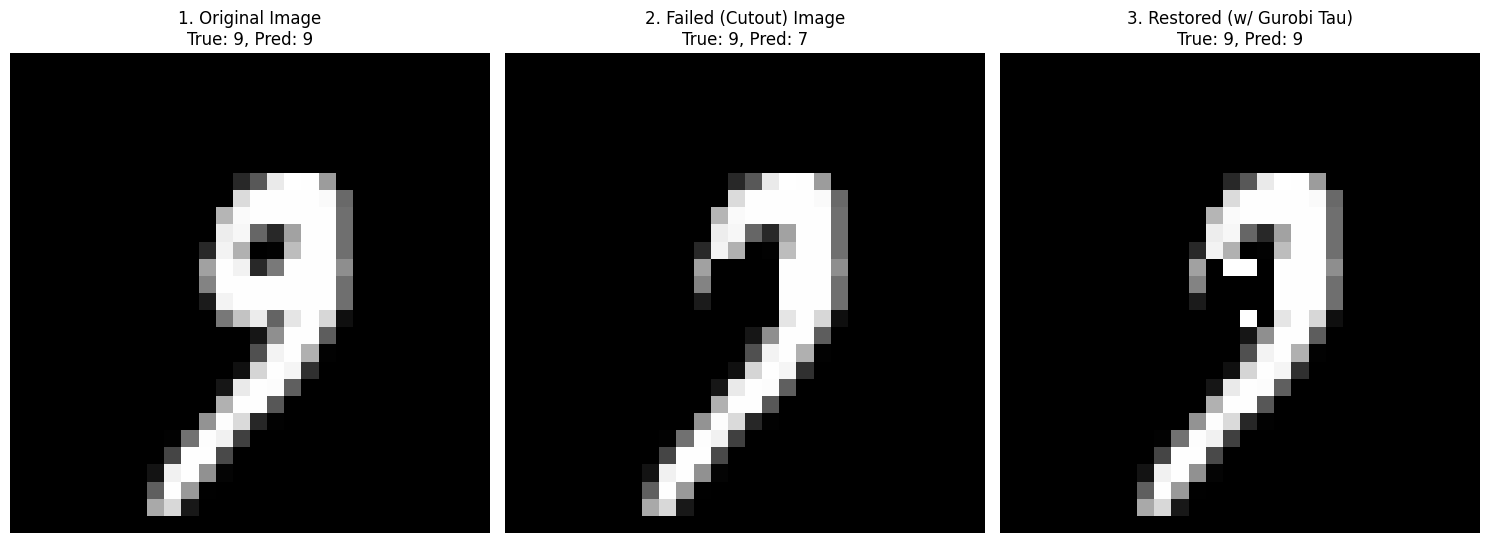


--- TEST 2/100: Image Index 1004 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1004 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   8 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


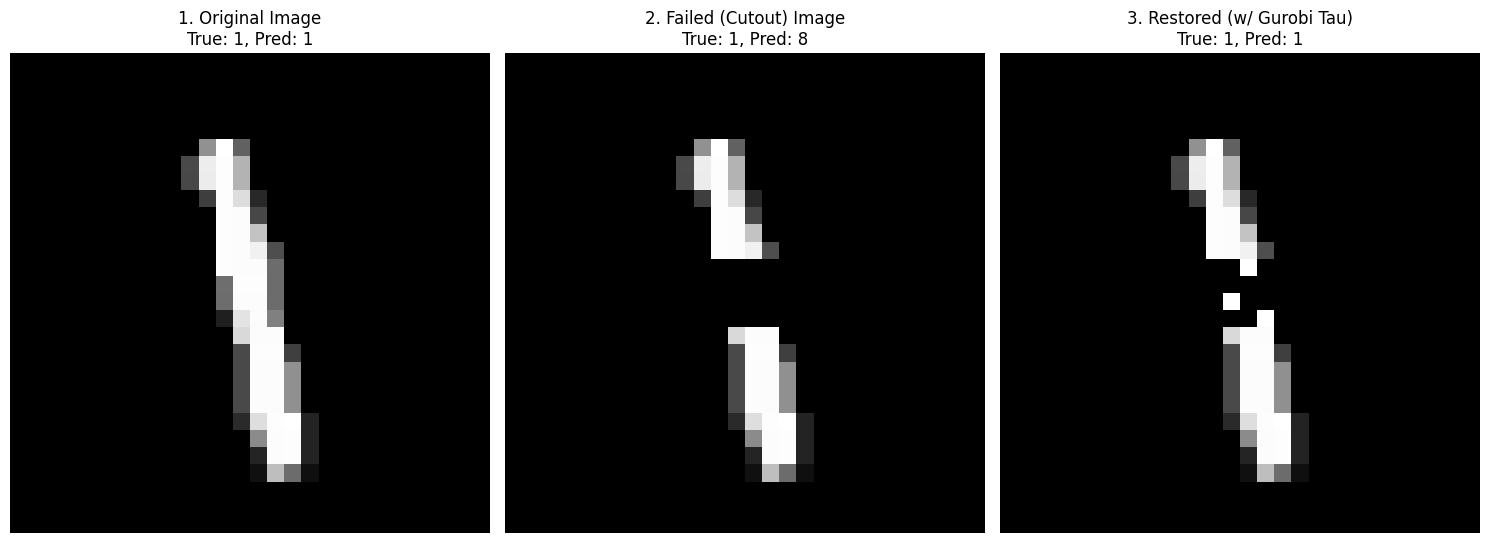


--- TEST 3/100: Image Index 1045 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1045.

--- TEST 4/100: Image Index 1054 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 2875

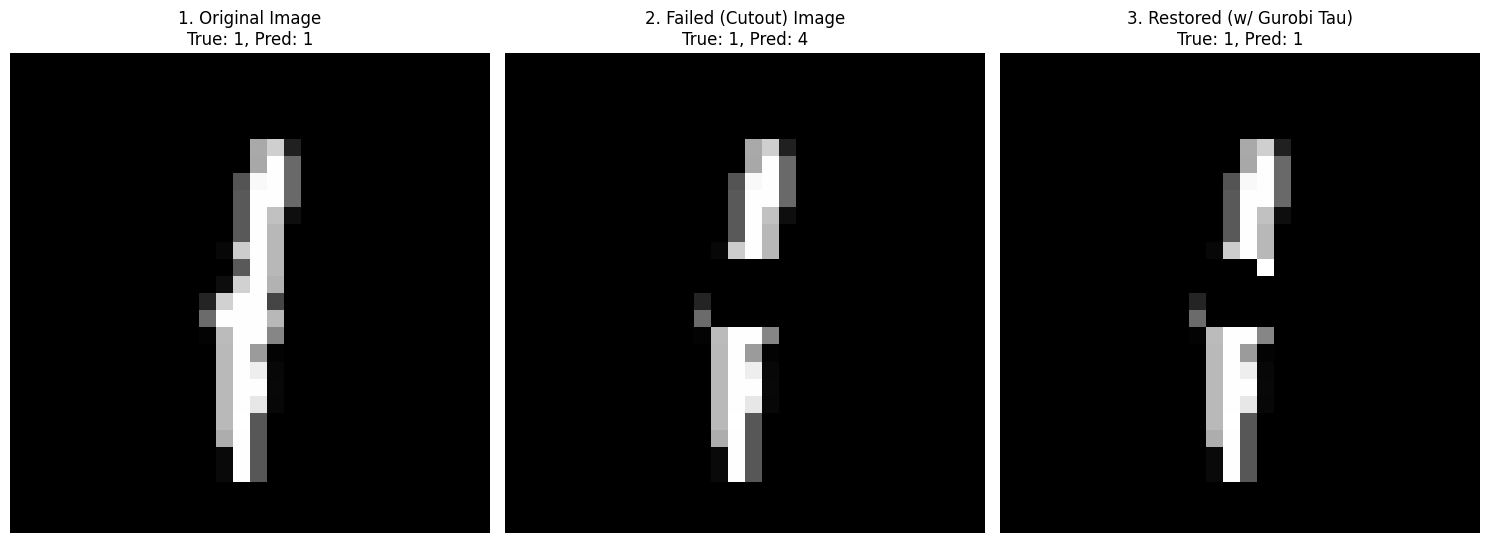


--- TEST 5/100: Image Index 1062 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1062.

--- TEST 6/100: Image Index 107 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750

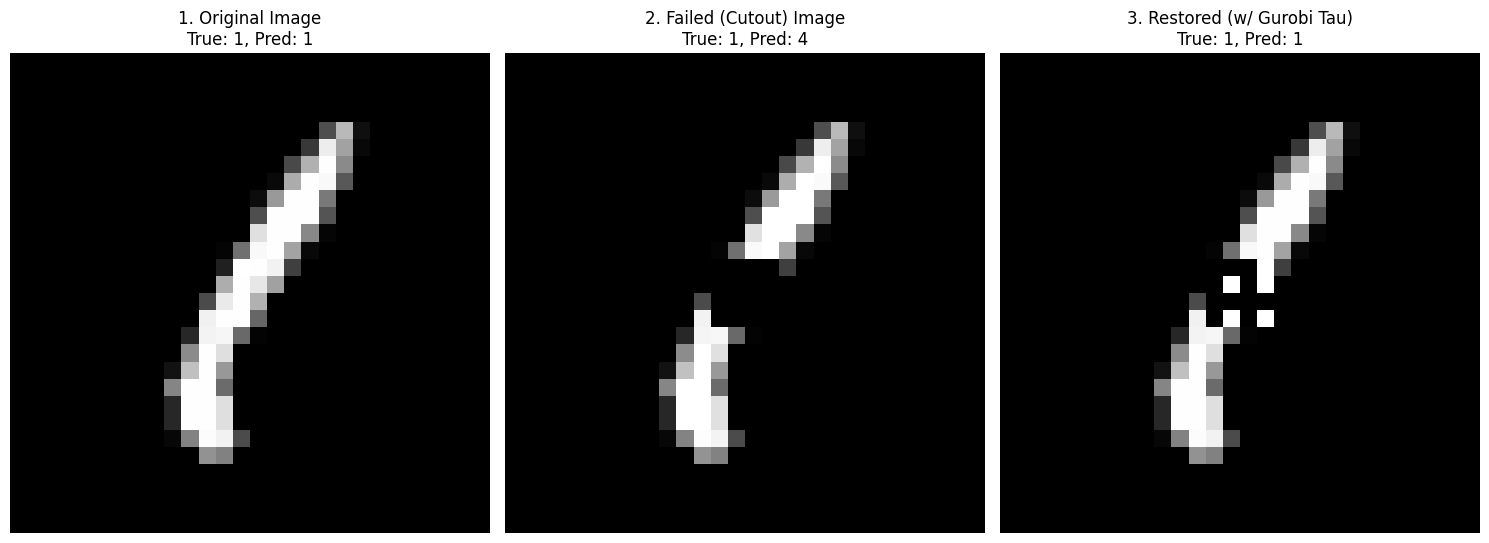


--- TEST 7/100: Image Index 1093 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1093.

--- TEST 8/100: Image Index 1114 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 2875

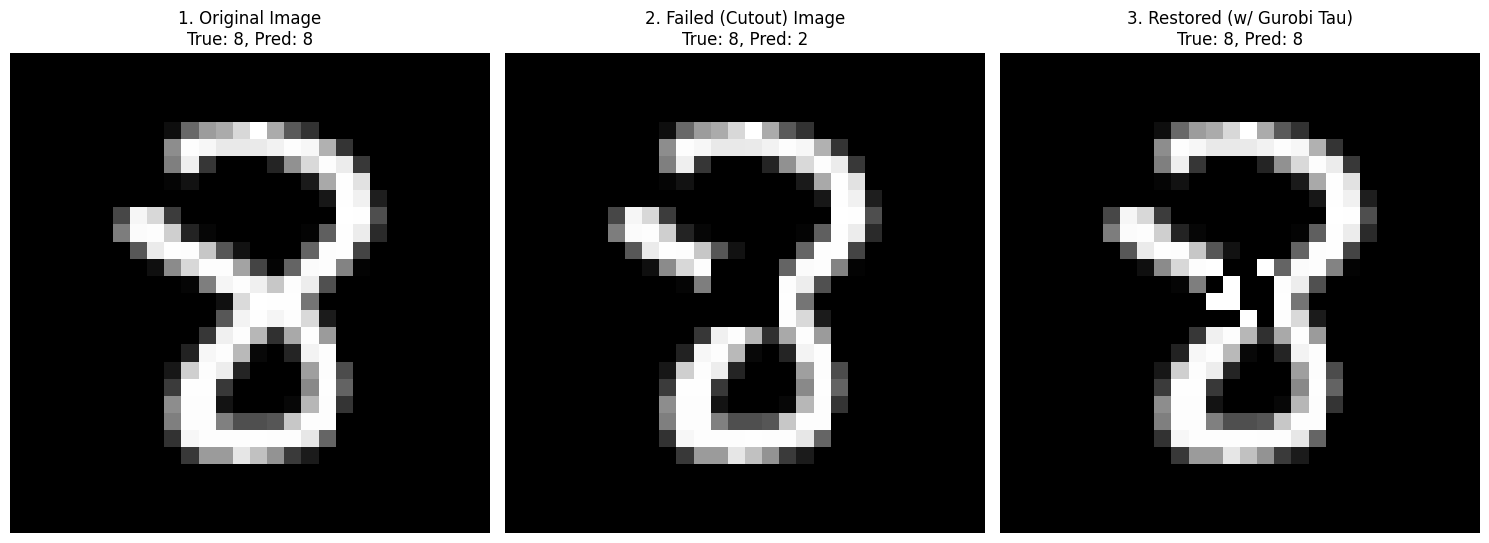


--- TEST 10/100: Image Index 1128 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1128 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


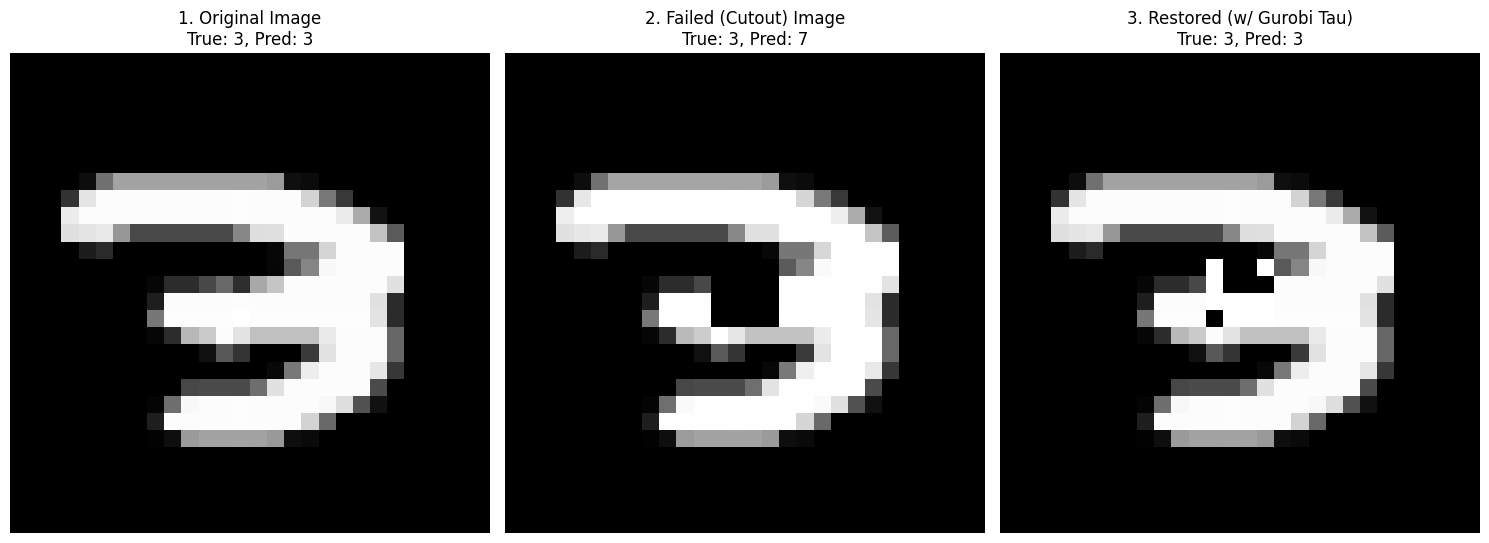


--- TEST 11/100: Image Index 1152 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1152 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


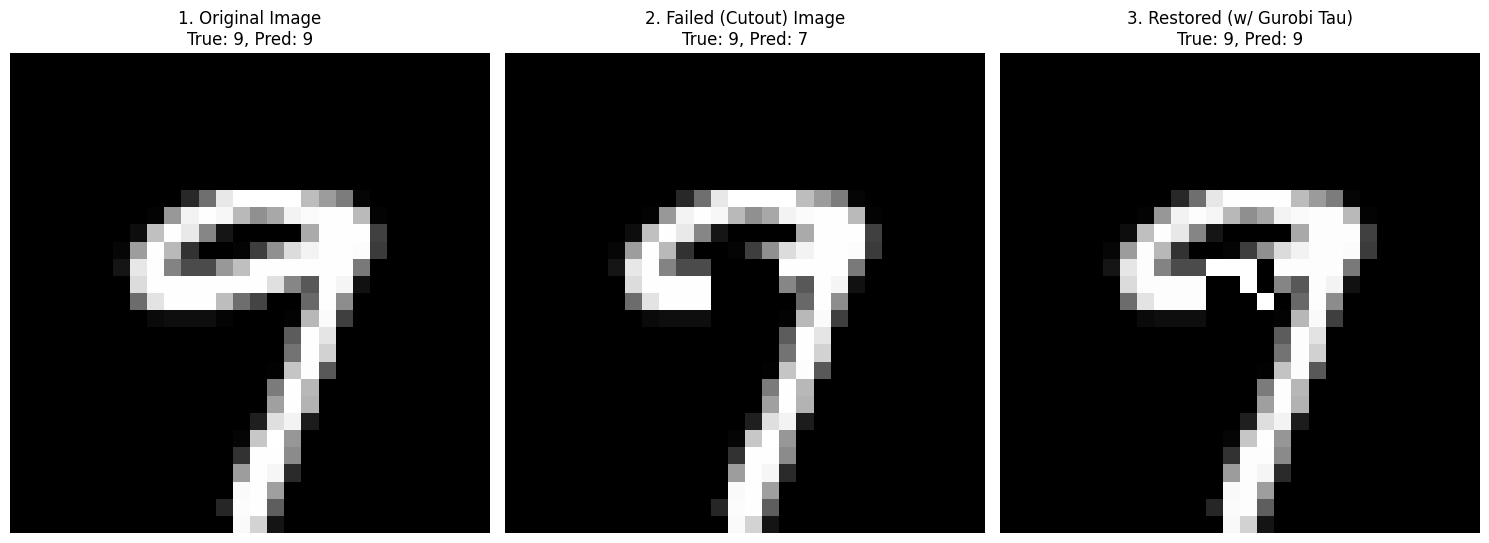


--- TEST 12/100: Image Index 1166 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1166 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


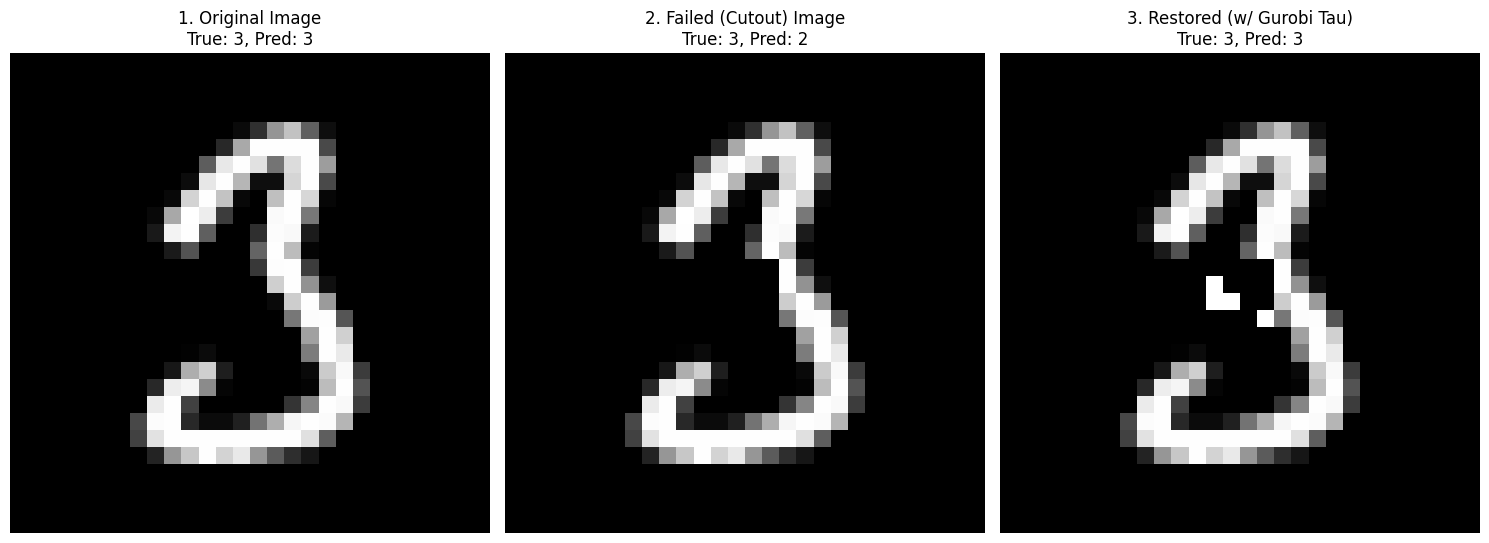


--- TEST 13/100: Image Index 1181 ---
Running Gurobi to find corrective 'tau' patch for target 6...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1181 - True Label: 6
  Prediction (Original): 6 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 6 (Correct)
----------------------------------------


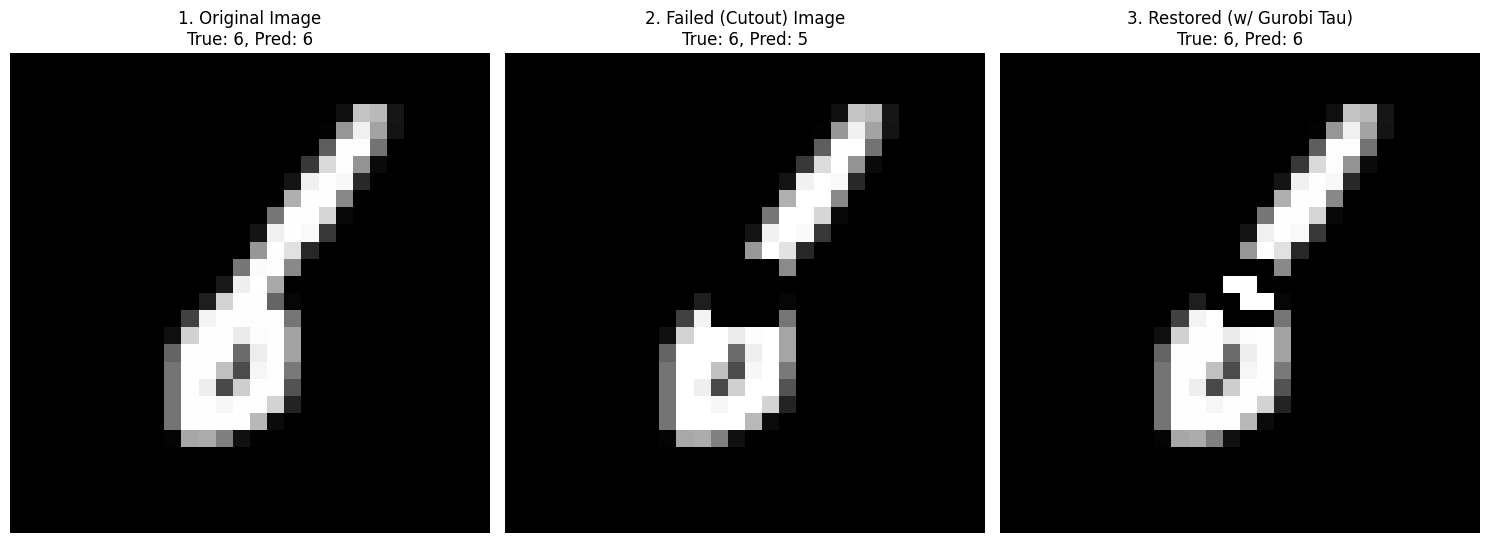


--- TEST 14/100: Image Index 1192 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1192 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


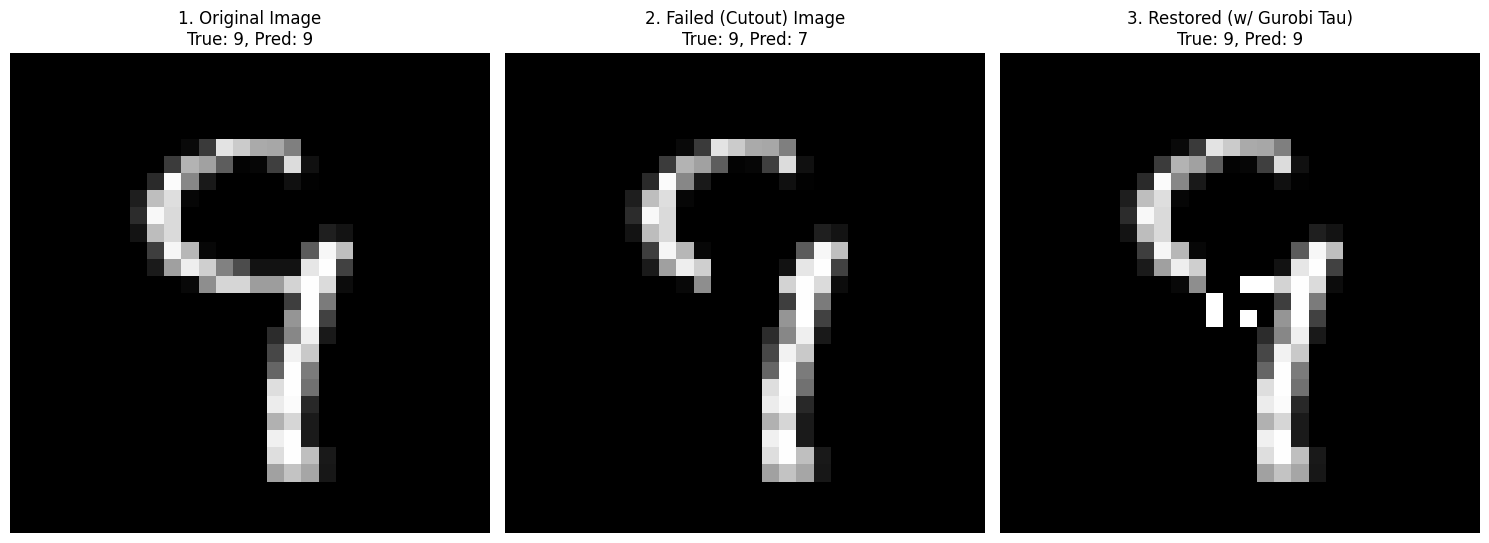


--- TEST 15/100: Image Index 1209 ---
Running Gurobi to find corrective 'tau' patch for target 6...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1209 - True Label: 6
  Prediction (Original): 6 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 6 (Correct)
----------------------------------------


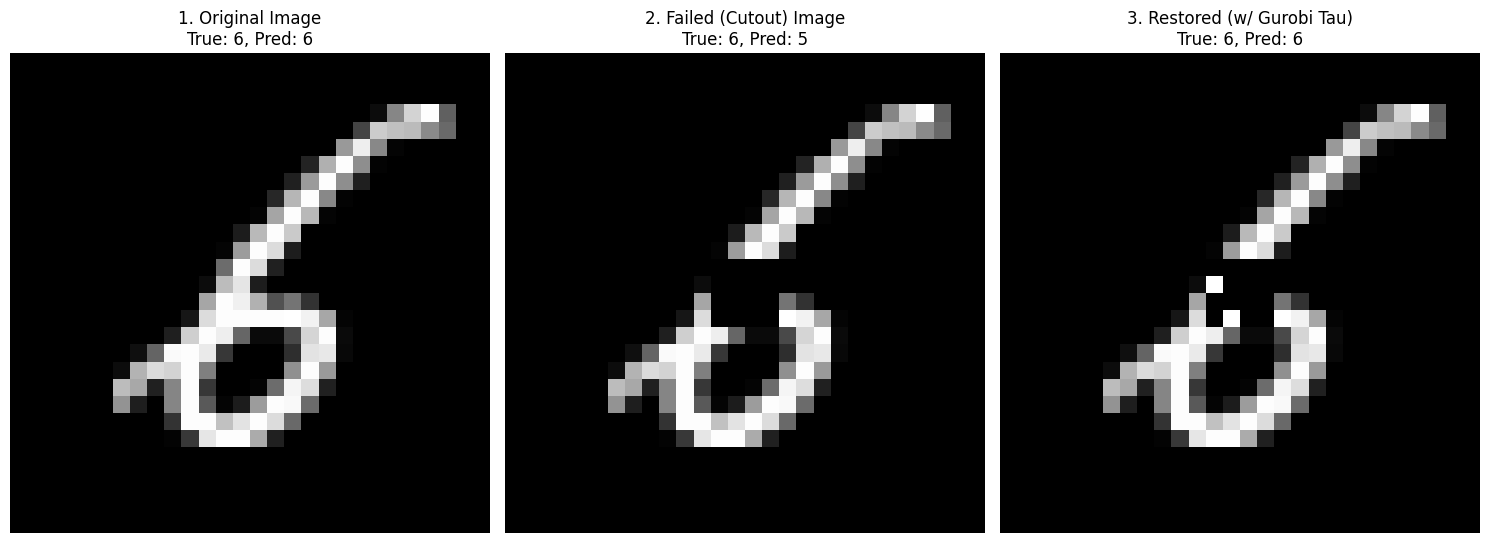


--- TEST 16/100: Image Index 1214 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1214 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   8 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


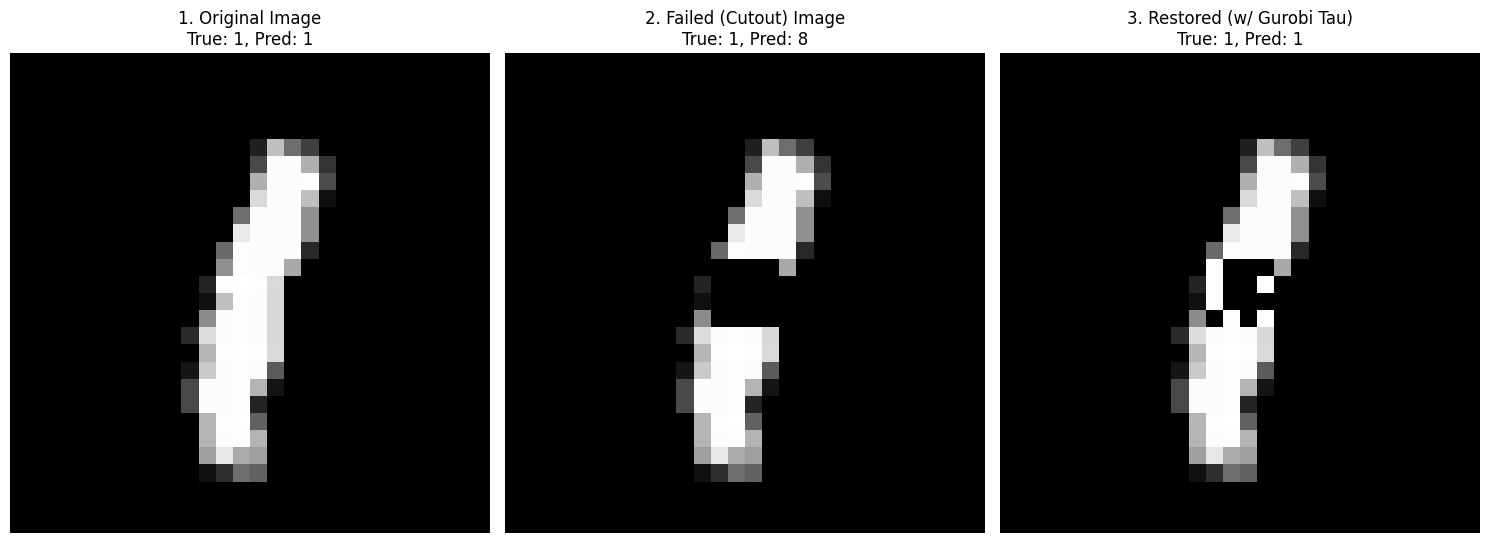


--- TEST 17/100: Image Index 1217 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1217 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


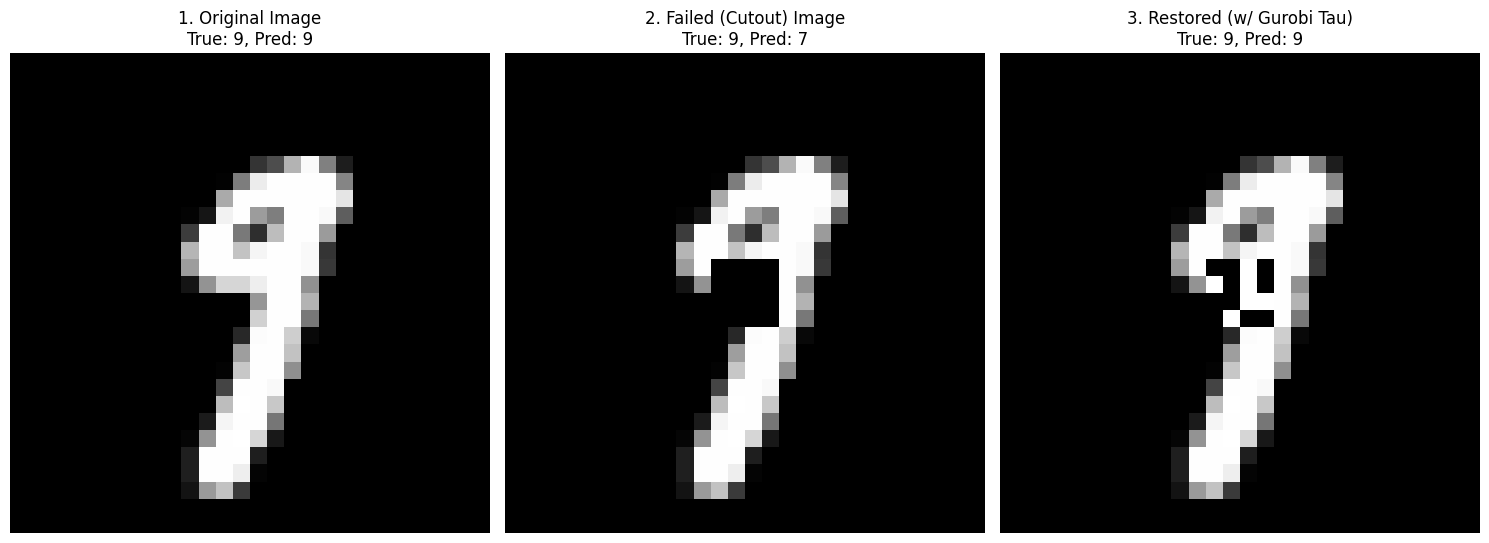


--- TEST 18/100: Image Index 1226 ---
Running Gurobi to find corrective 'tau' patch for target 7...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1226.

--- TEST 19/100: Image Index 1239 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28

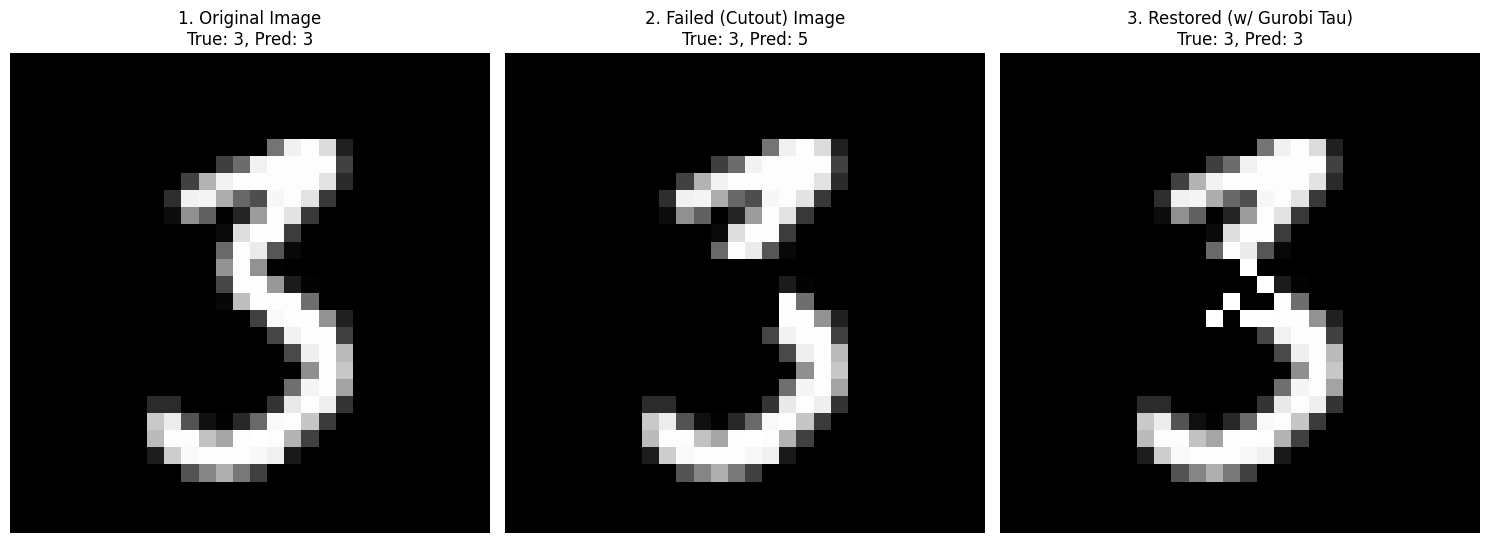


--- TEST 20/100: Image Index 1240 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1240 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   4 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


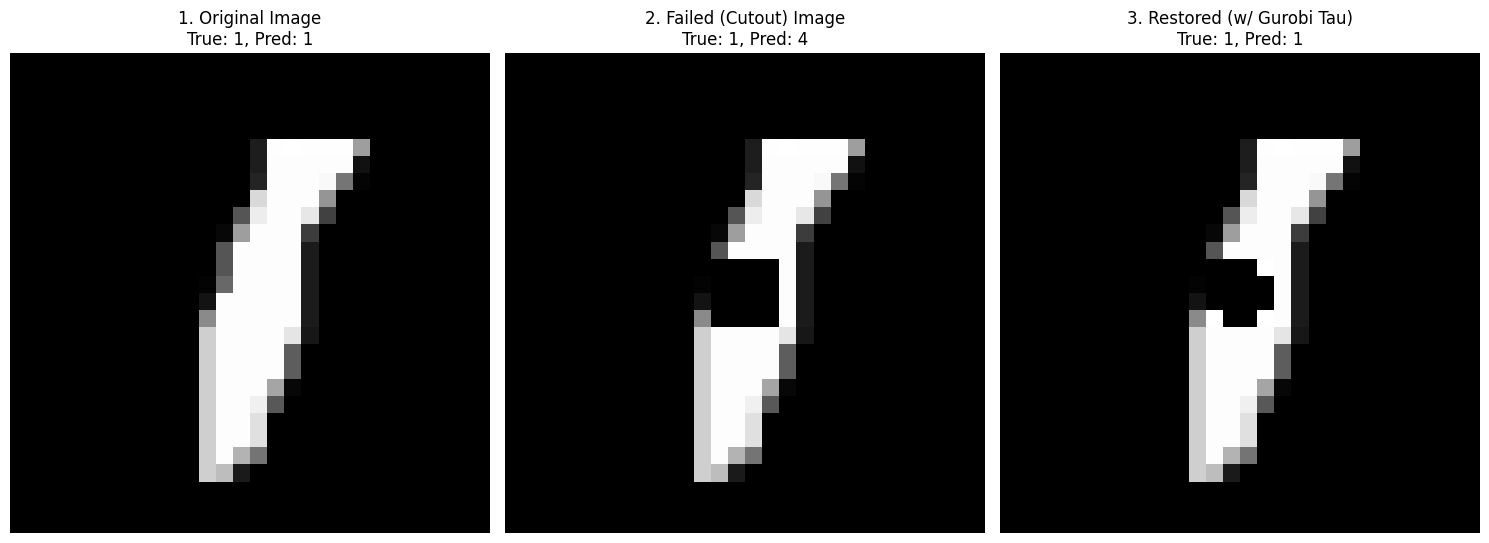


--- TEST 21/100: Image Index 1268 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1268 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


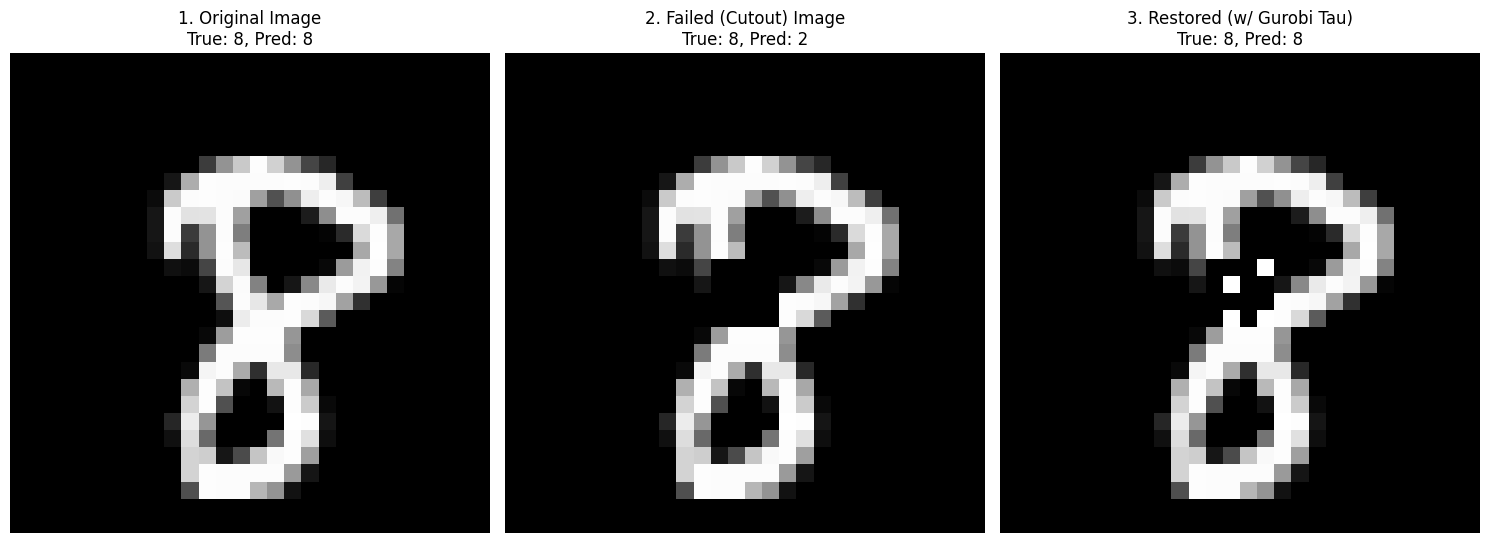


--- TEST 22/100: Image Index 1290 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1290 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


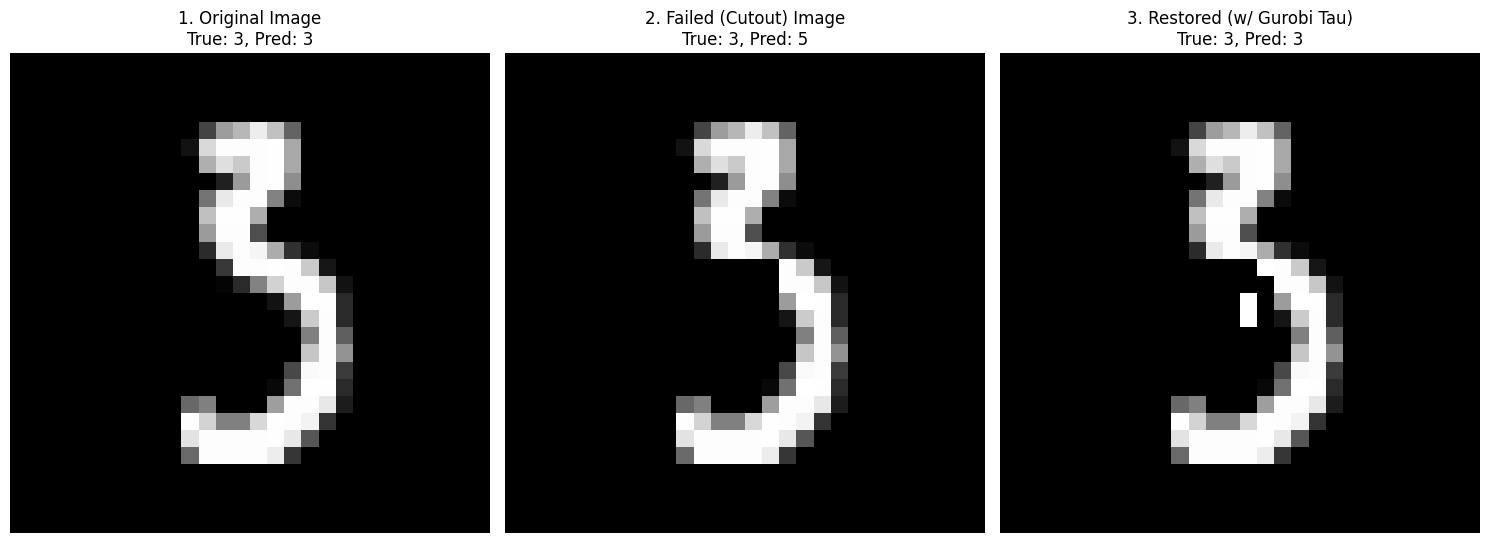


--- TEST 23/100: Image Index 1354 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1354 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


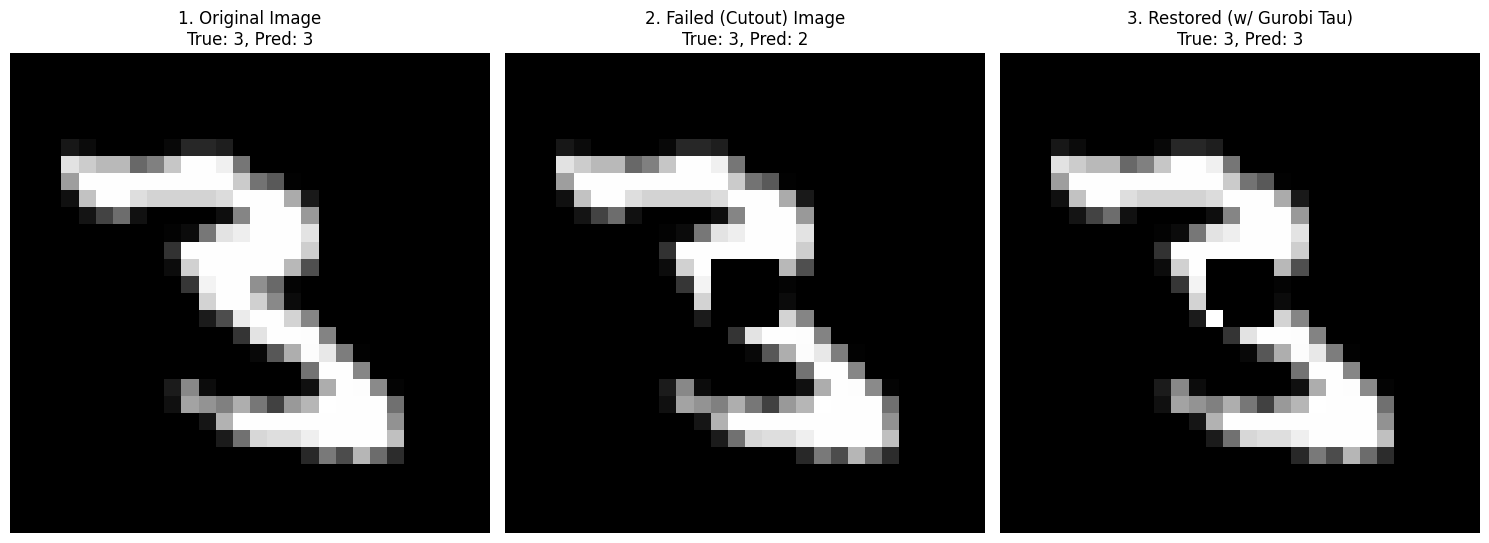


--- TEST 24/100: Image Index 1364 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1364 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


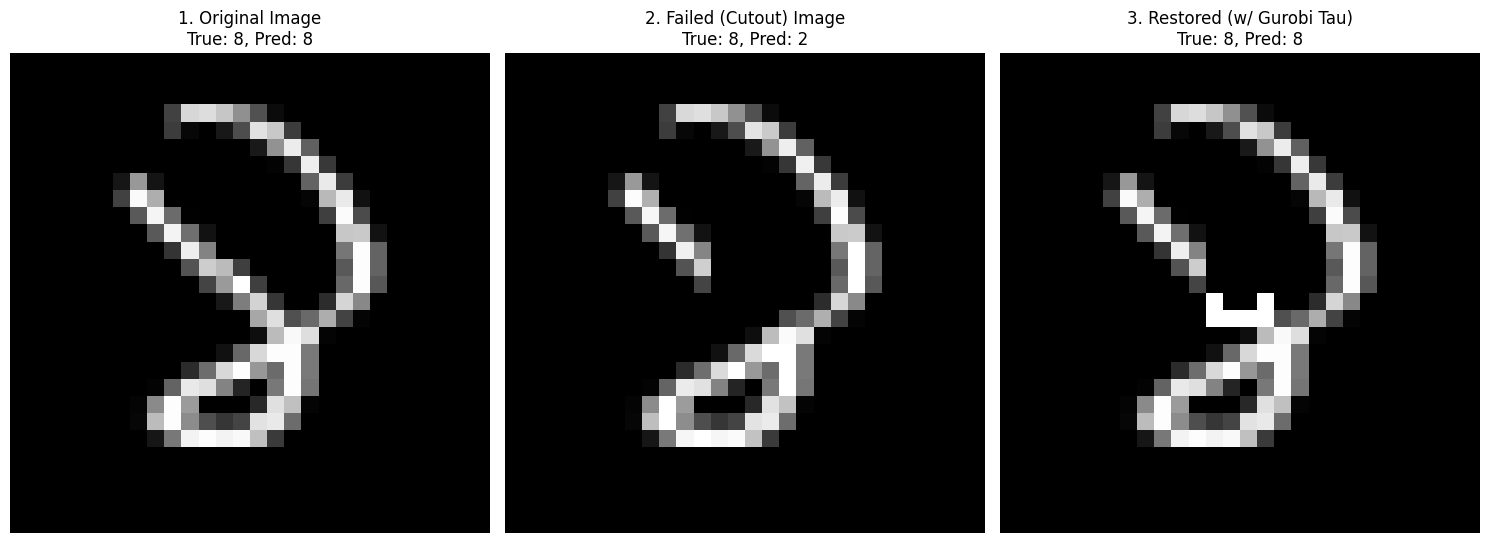


--- TEST 25/100: Image Index 1403 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1403 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   8 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


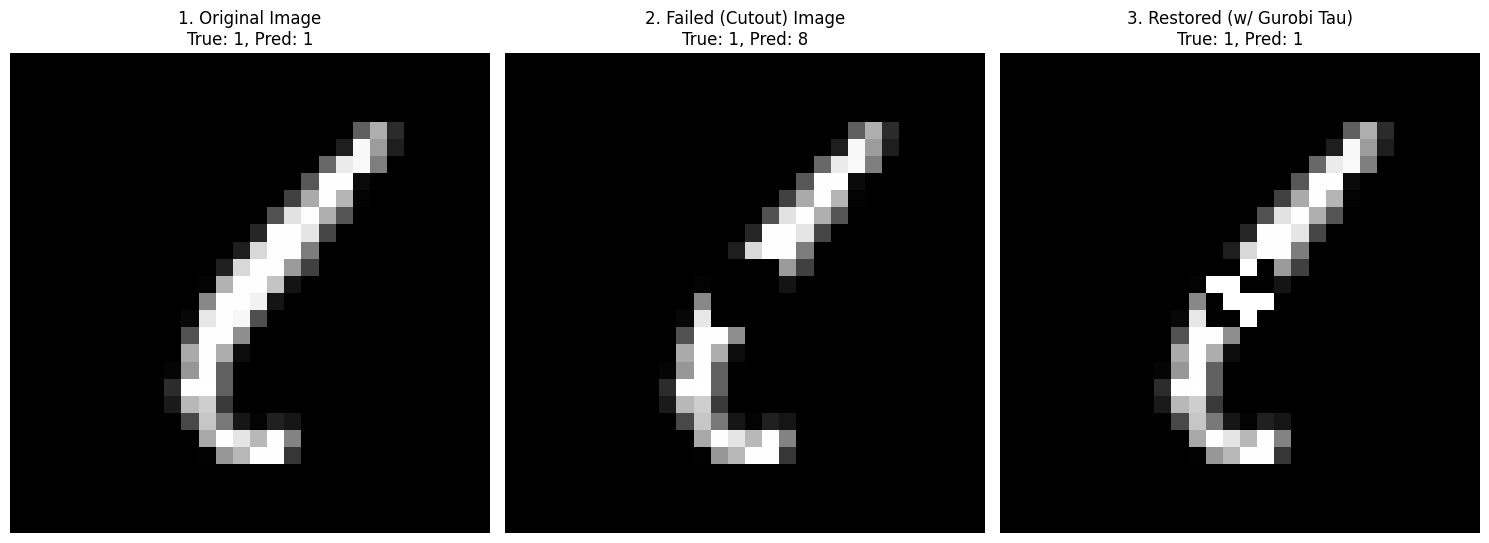


--- TEST 26/100: Image Index 1439 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1439 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


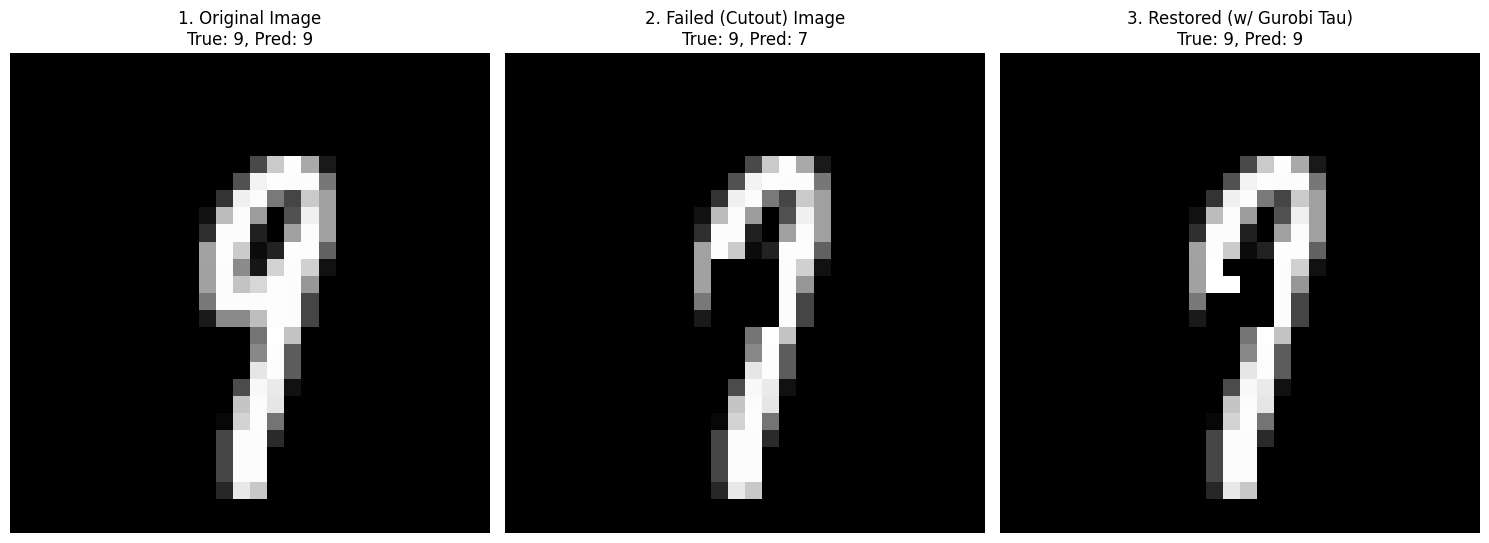


--- TEST 27/100: Image Index 1447 ---
Running Gurobi to find corrective 'tau' patch for target 5...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1447 - True Label: 5
  Prediction (Original): 5 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 5 (Correct)
----------------------------------------


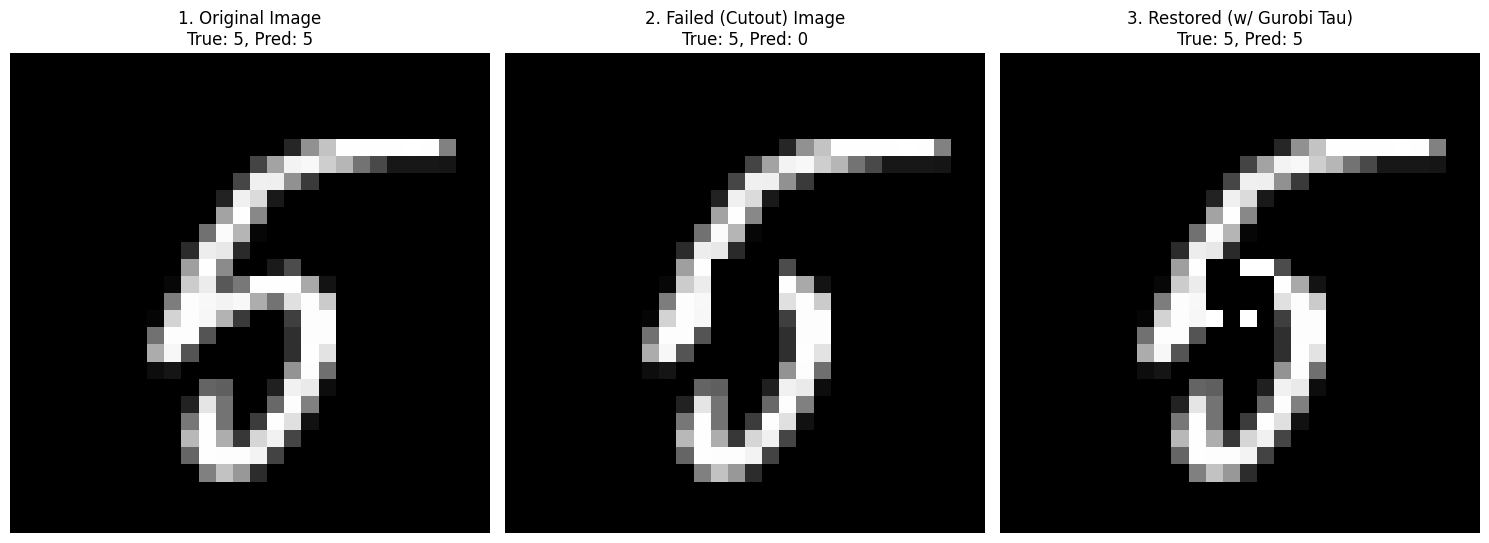


--- TEST 28/100: Image Index 1508 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1508 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


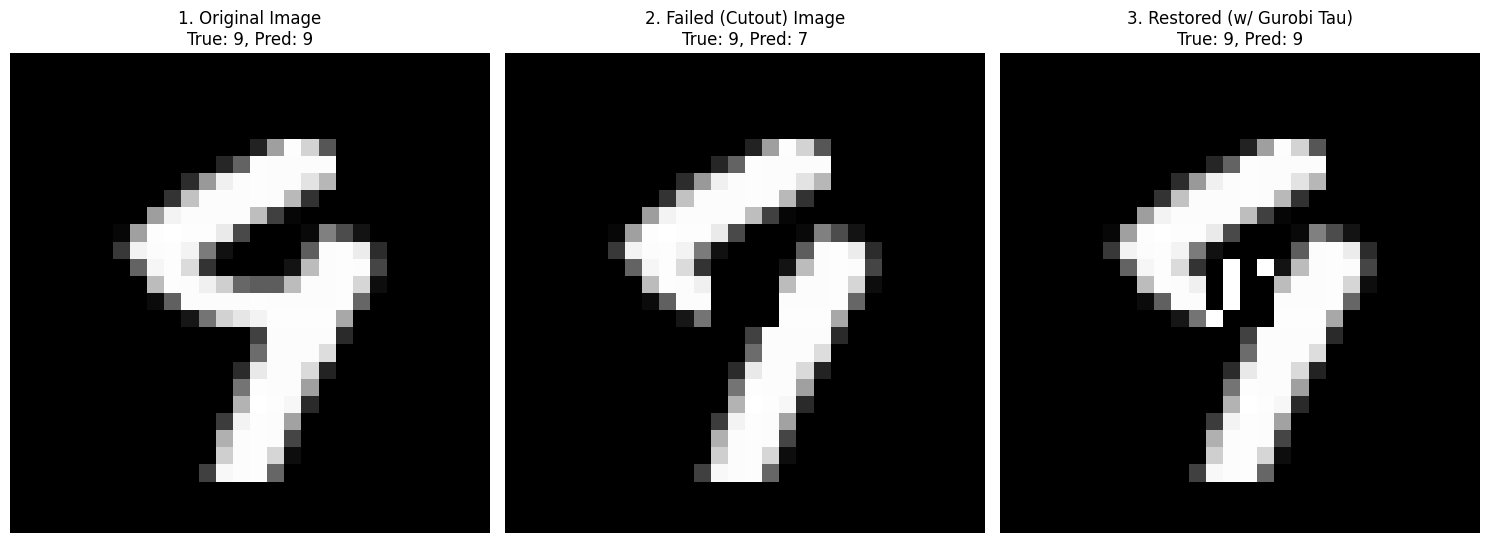


--- TEST 29/100: Image Index 151 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 151 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   8 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


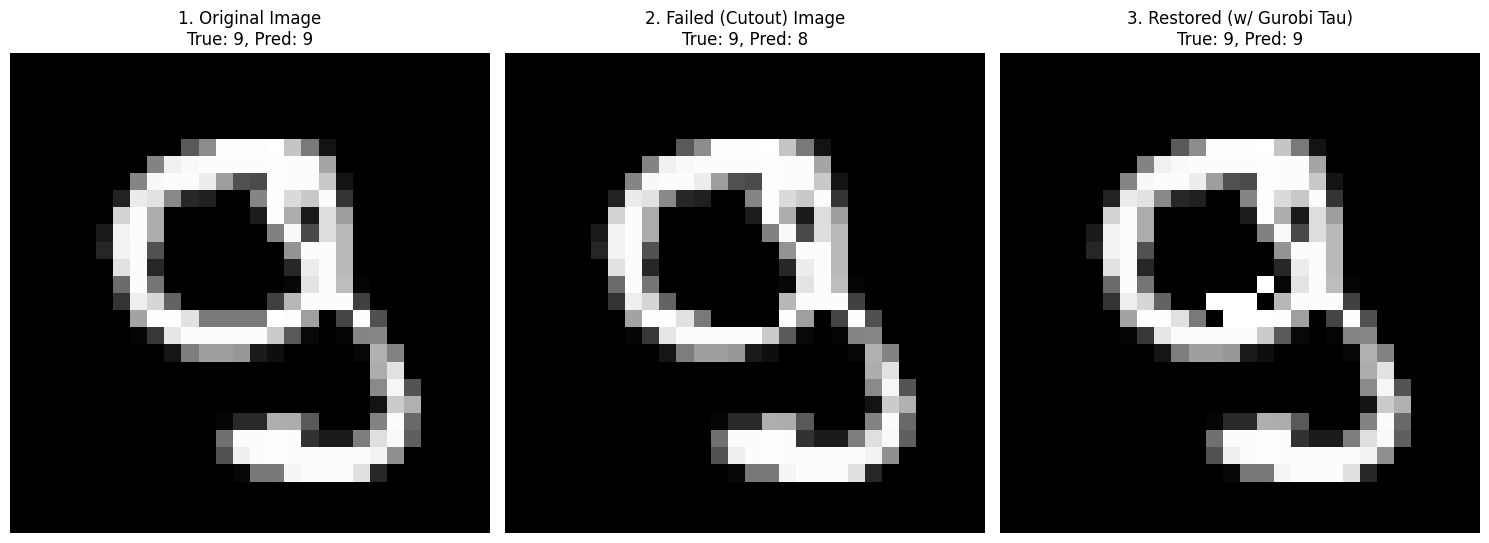


--- TEST 30/100: Image Index 1527 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1527 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


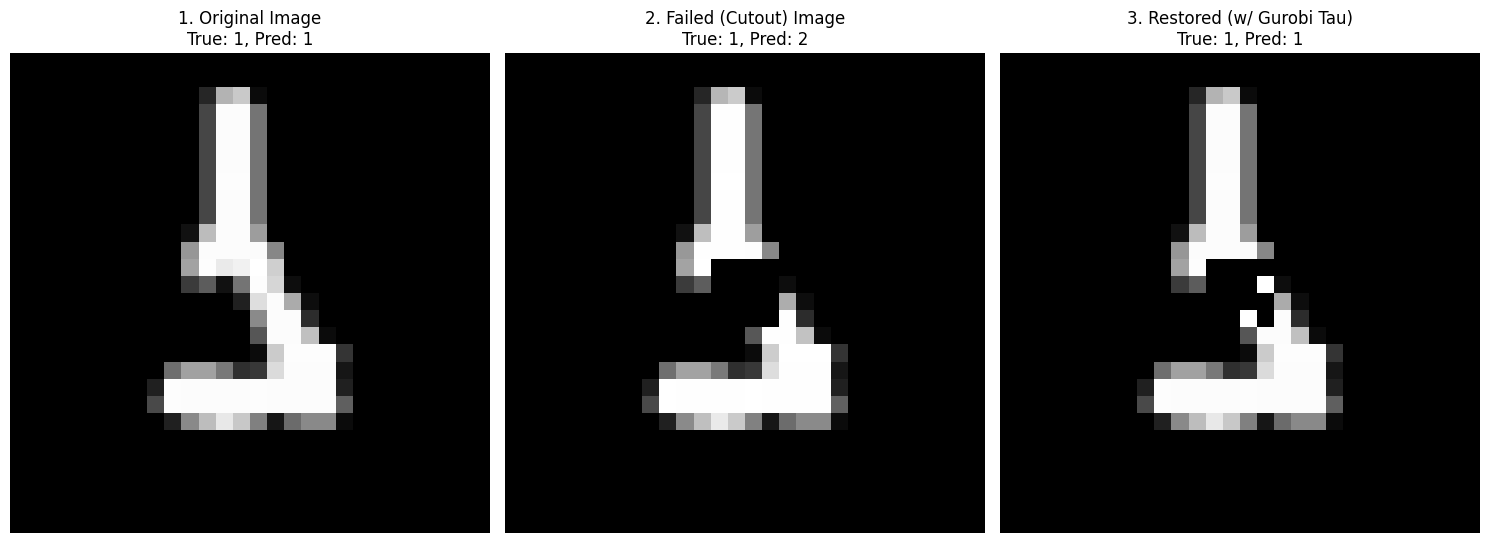


--- TEST 31/100: Image Index 1554 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1554 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


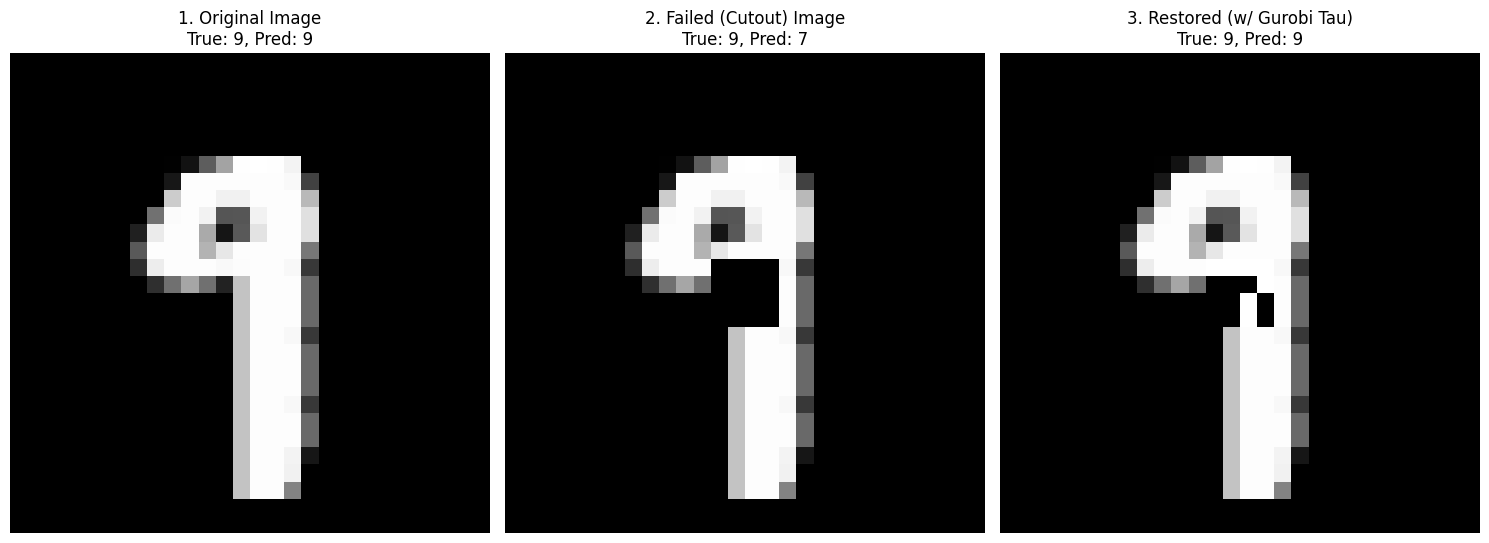


--- TEST 32/100: Image Index 1568 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1568 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


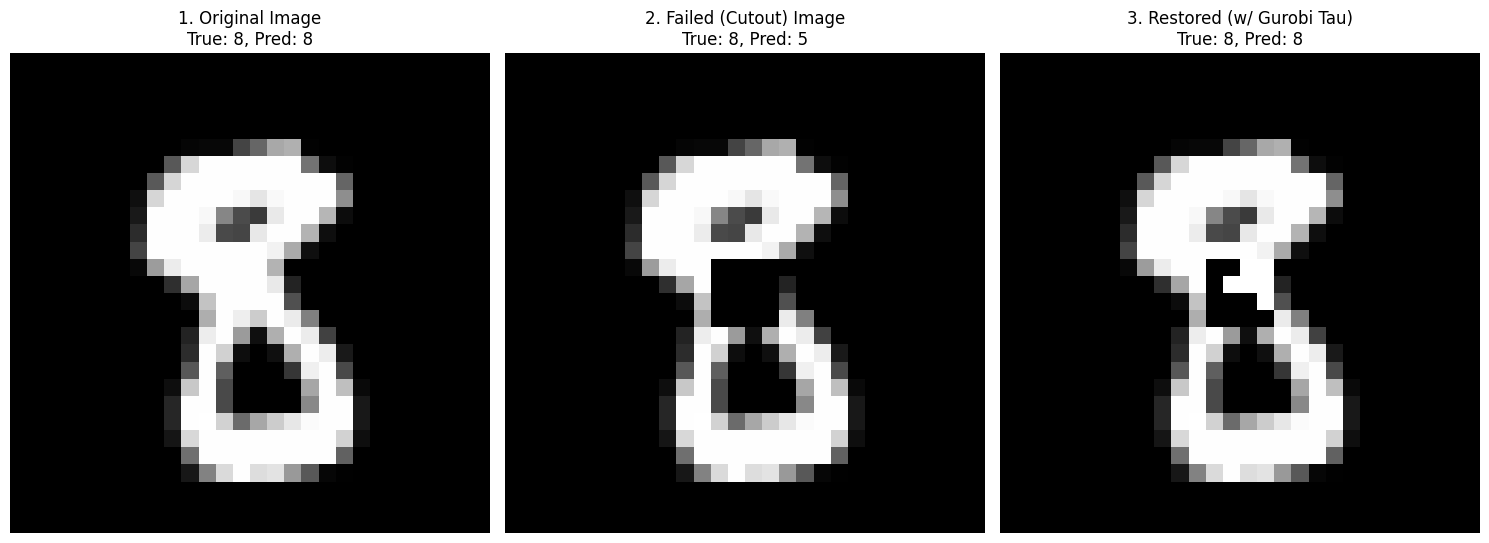


--- TEST 33/100: Image Index 1597 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1597 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


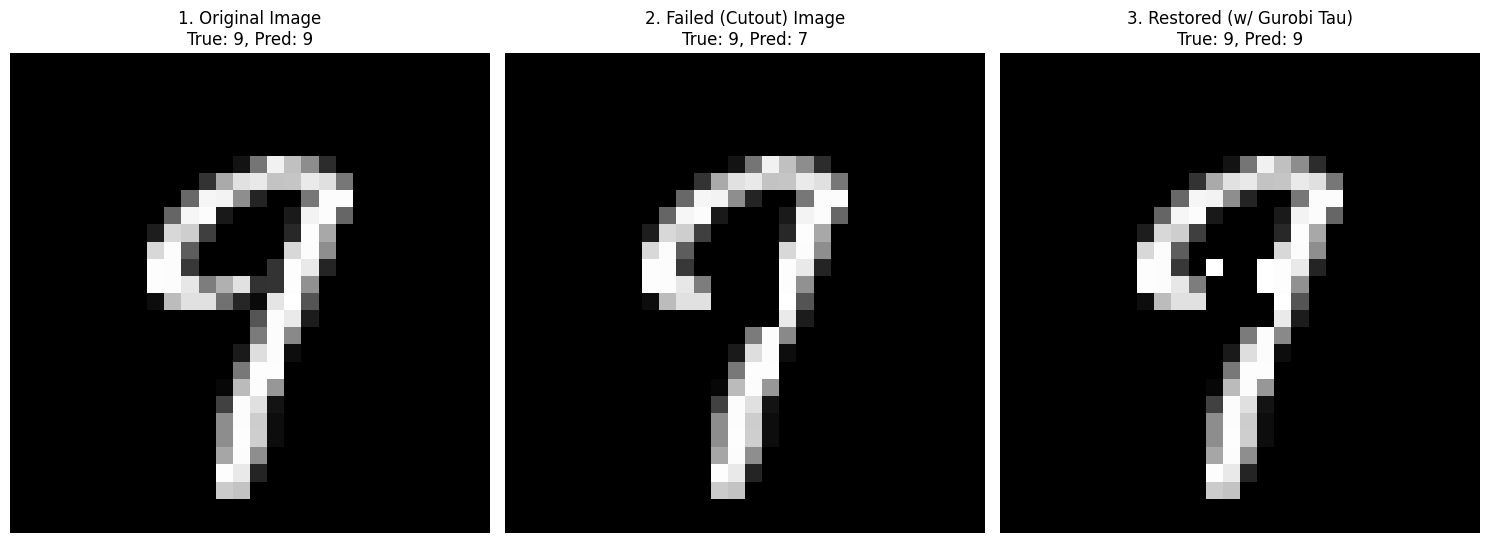


--- TEST 34/100: Image Index 1601 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1601 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


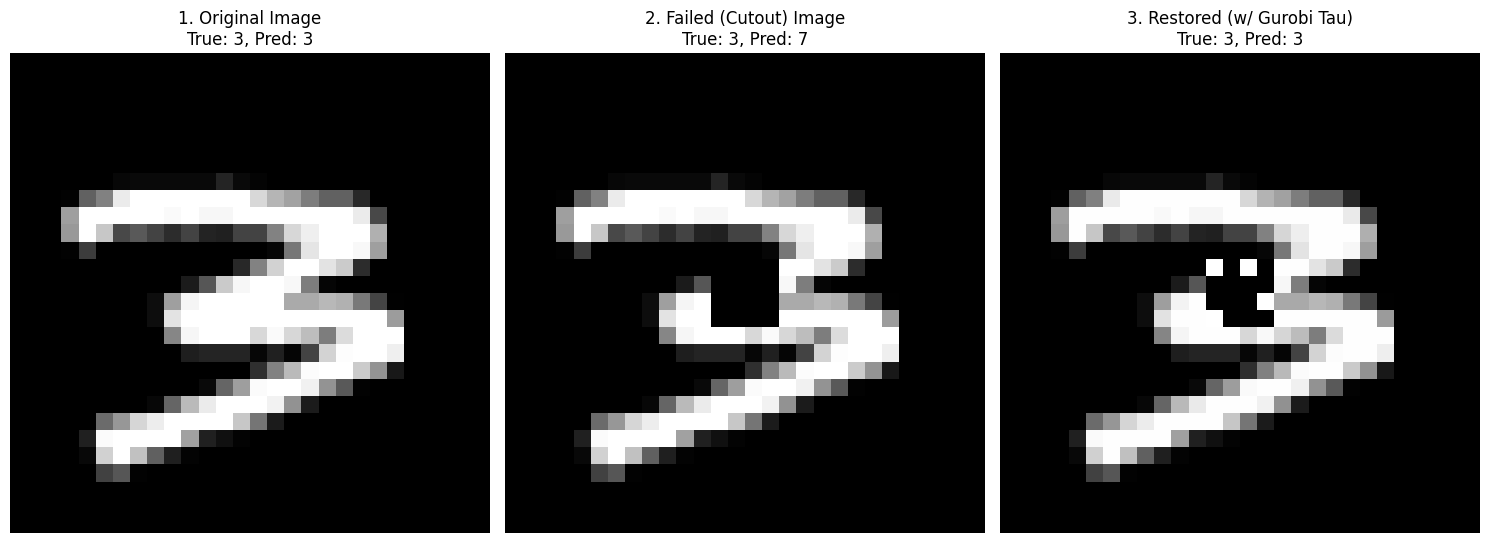


--- TEST 35/100: Image Index 1607 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1607 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


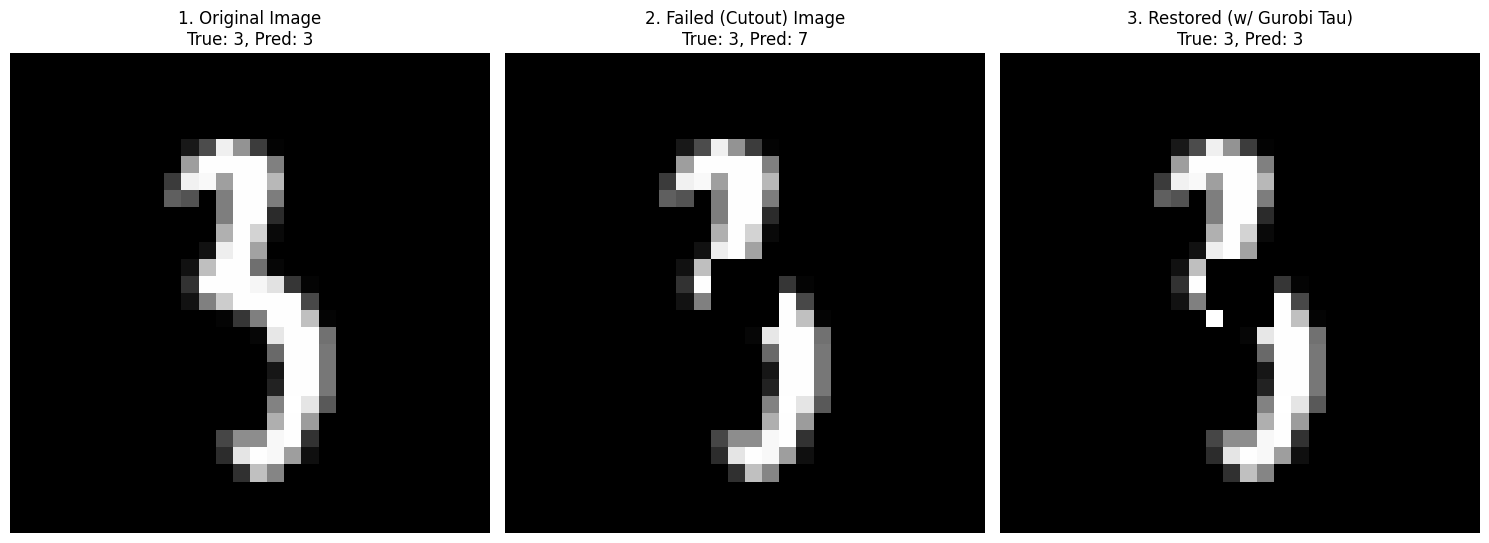


--- TEST 36/100: Image Index 1617 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1617 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


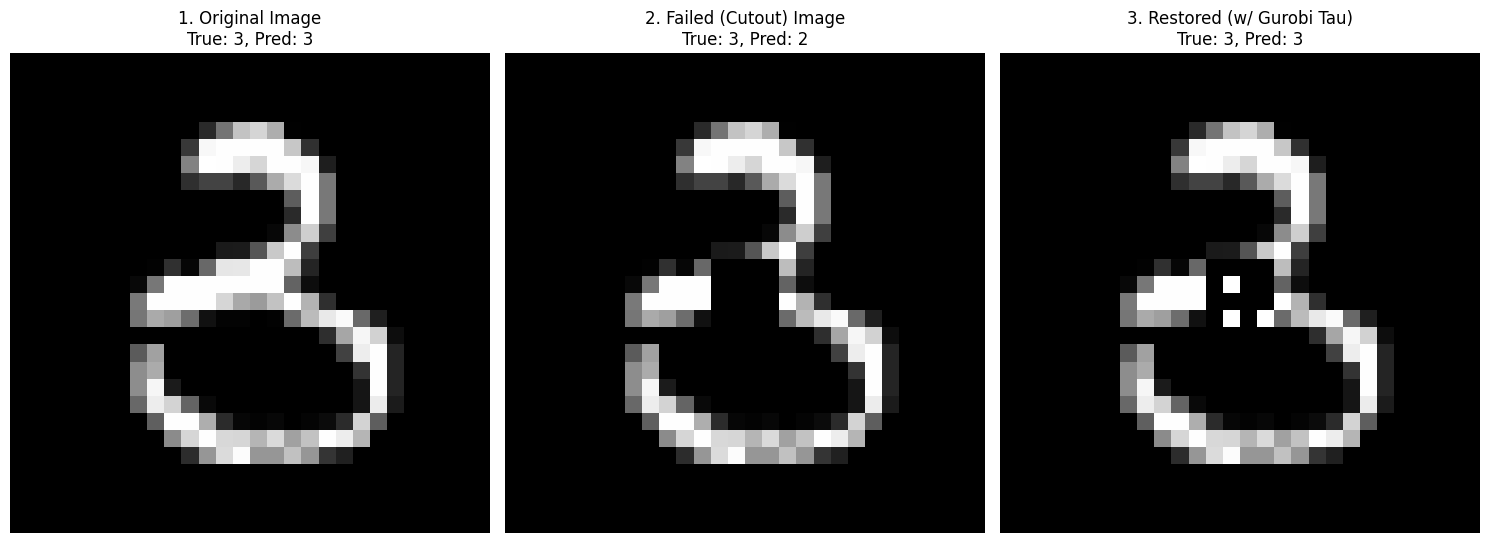


--- TEST 37/100: Image Index 1631 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1631 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


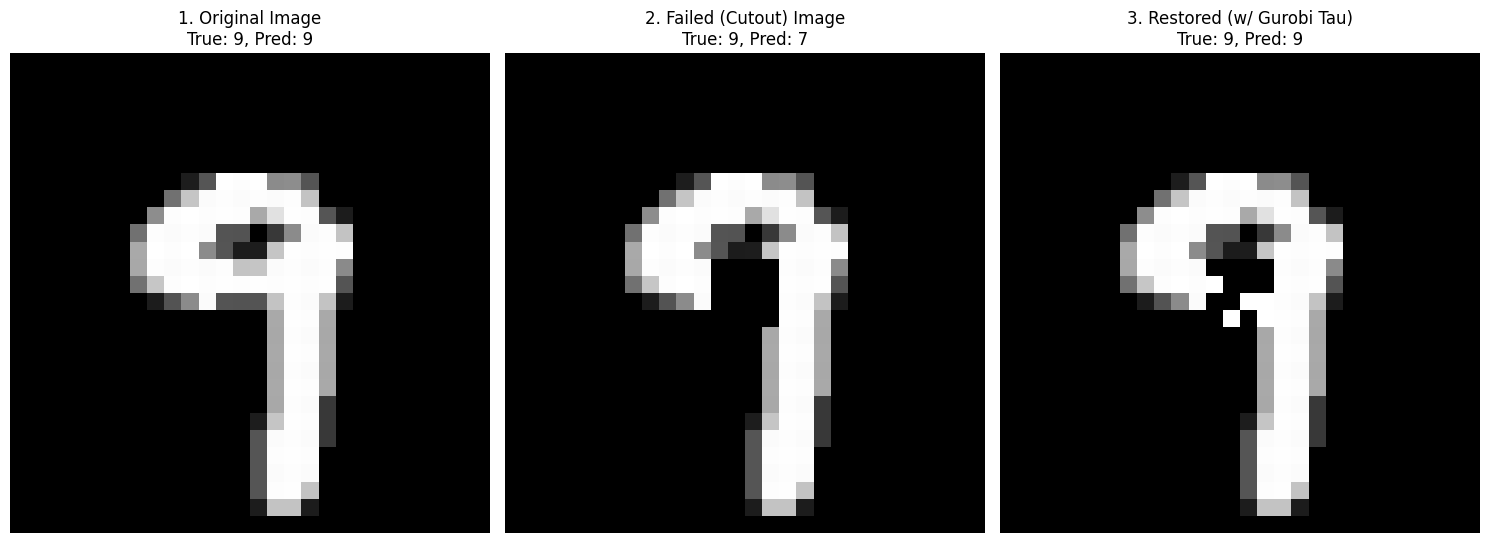


--- TEST 38/100: Image Index 1634 ---
Running Gurobi to find corrective 'tau' patch for target 4...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1634 - True Label: 4
  Prediction (Original): 4 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 4 (Correct)
----------------------------------------


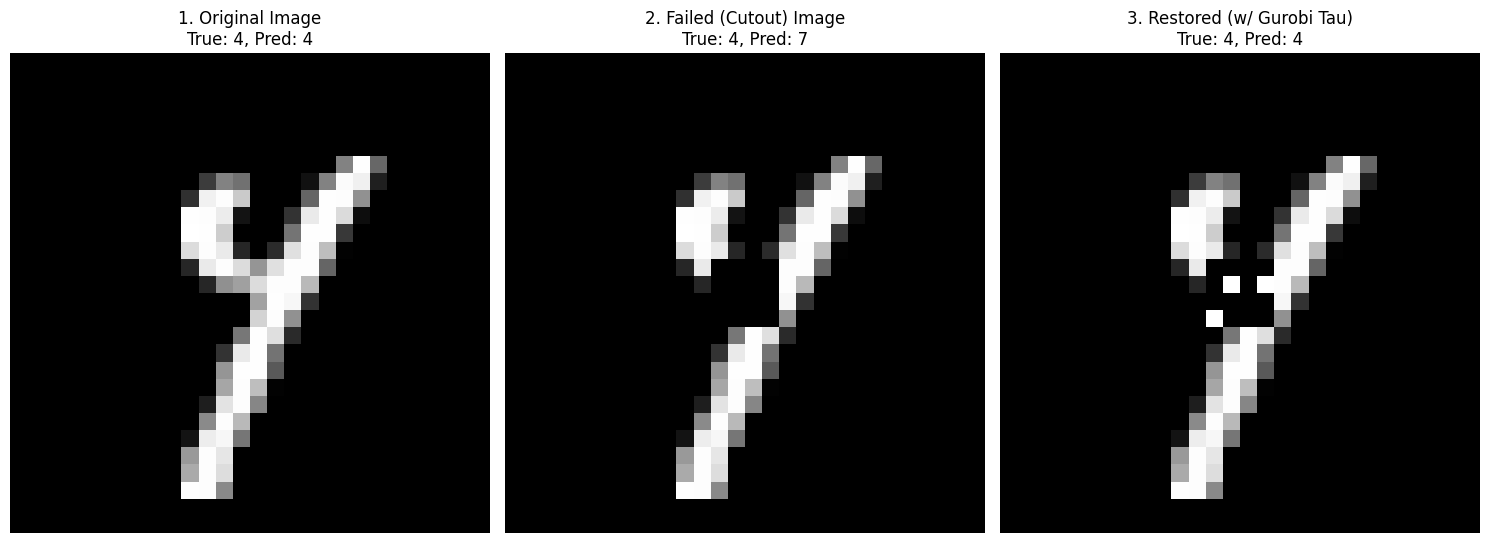


--- TEST 39/100: Image Index 1648 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1648 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


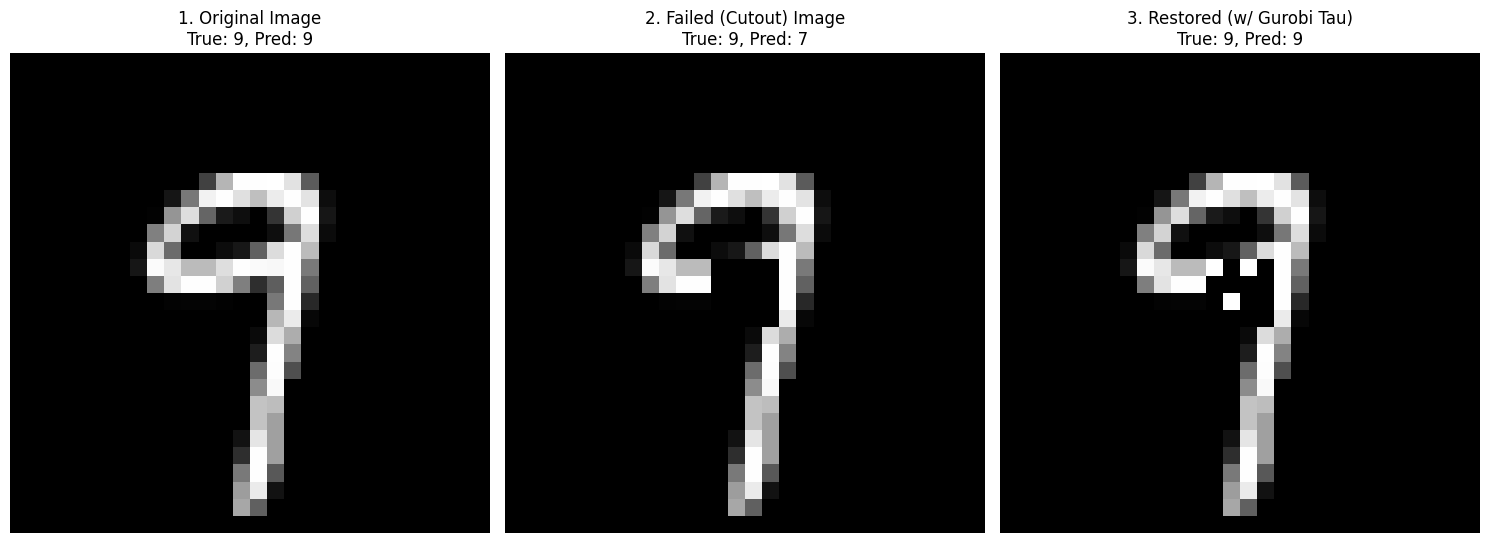


--- TEST 40/100: Image Index 1661 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1661 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


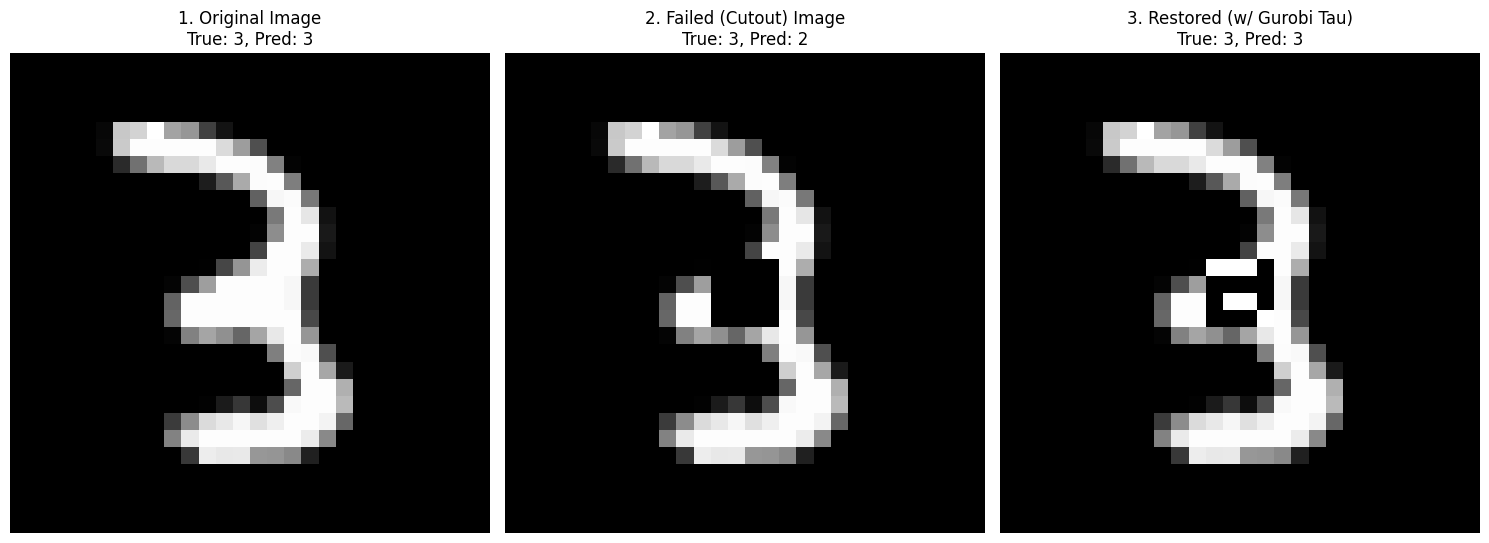


--- TEST 41/100: Image Index 1663 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1663 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


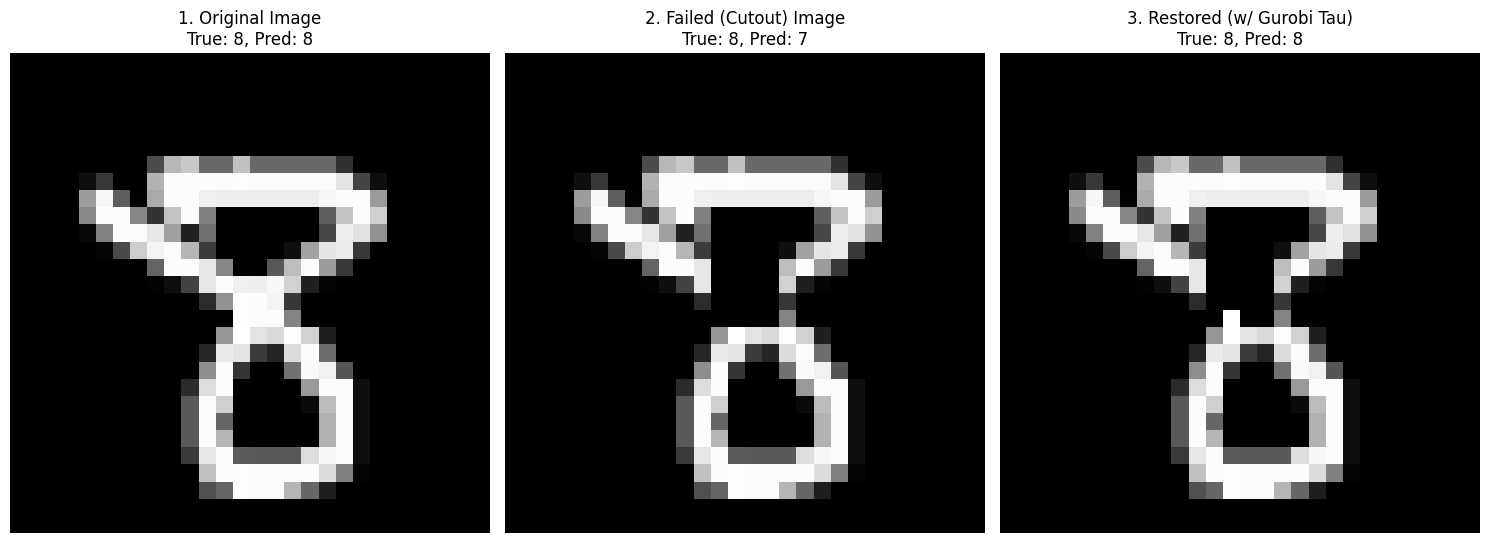


--- TEST 42/100: Image Index 1664 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1664 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


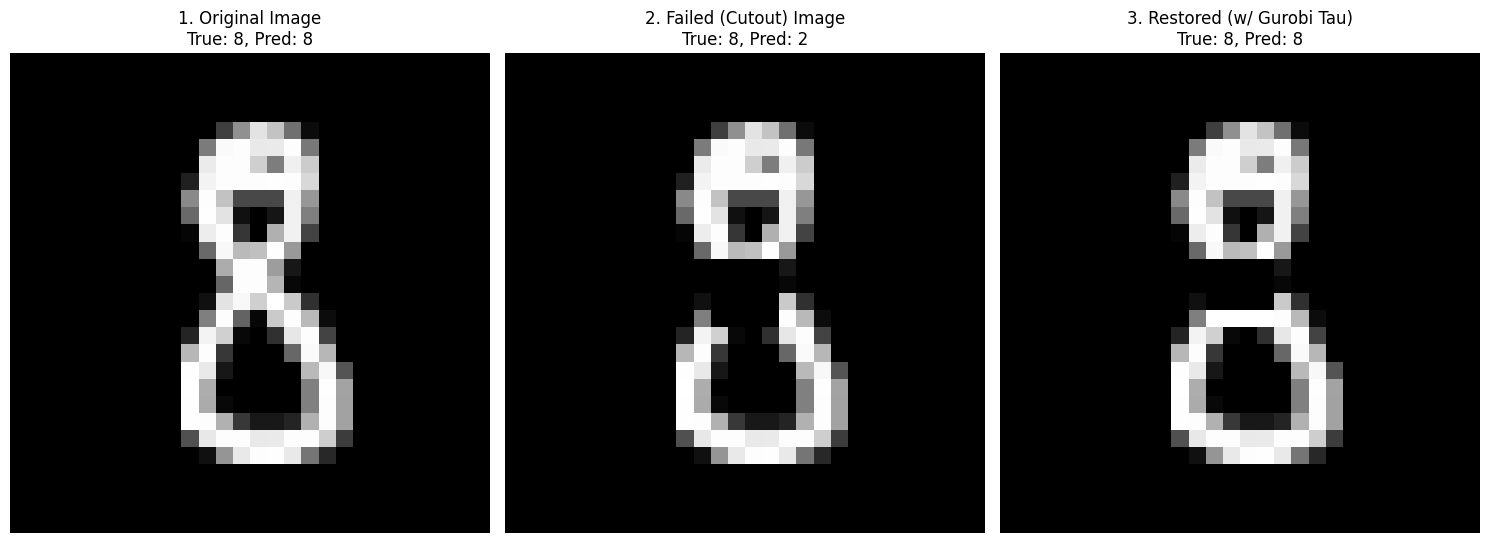


--- TEST 43/100: Image Index 1673 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1673 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


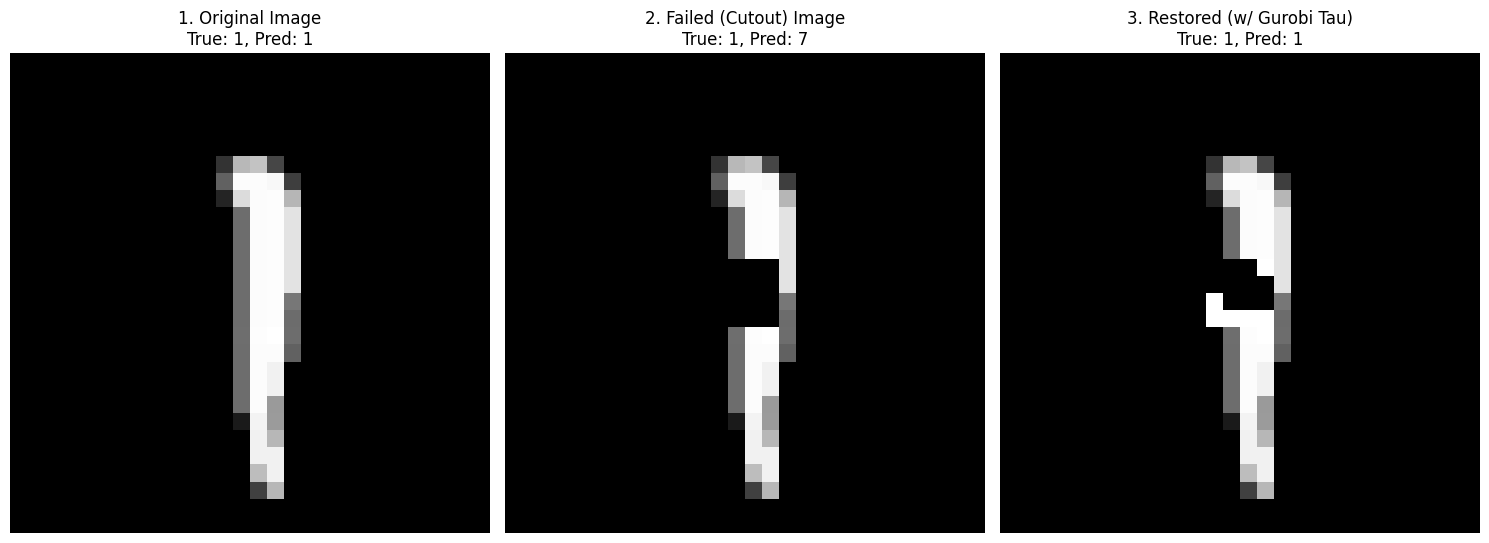


--- TEST 44/100: Image Index 1691 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1691.

--- TEST 45/100: Image Index 1694 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28

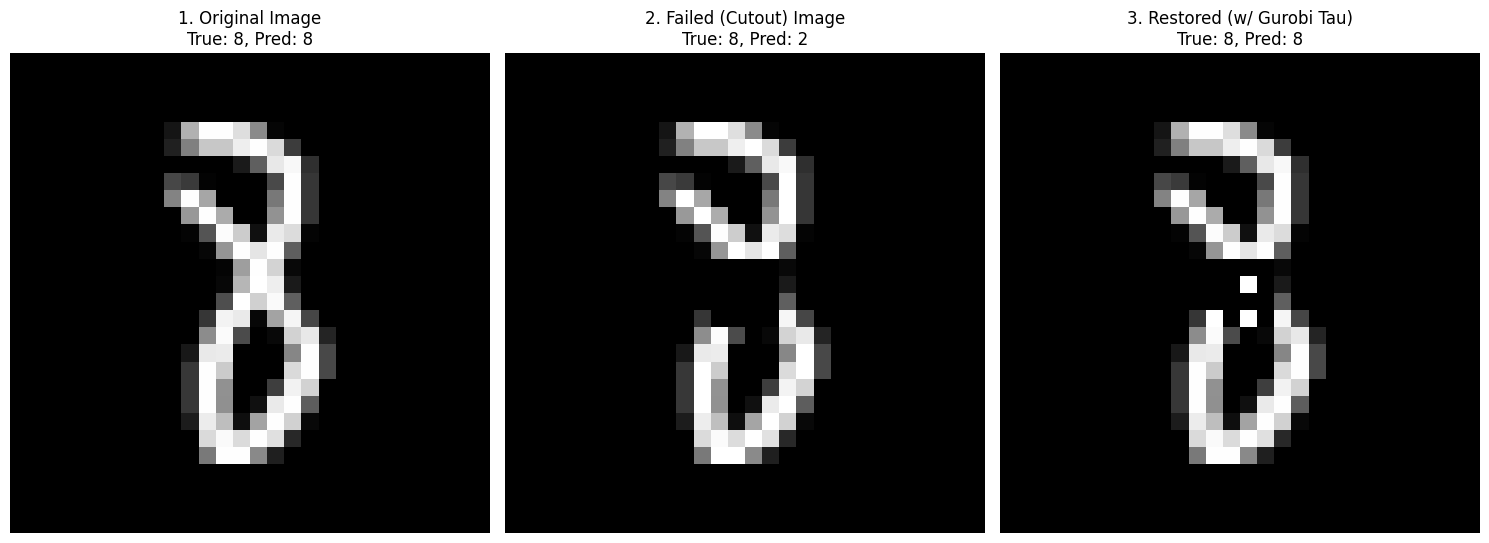


--- TEST 46/100: Image Index 1695 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1695.

--- TEST 47/100: Image Index 1729 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28

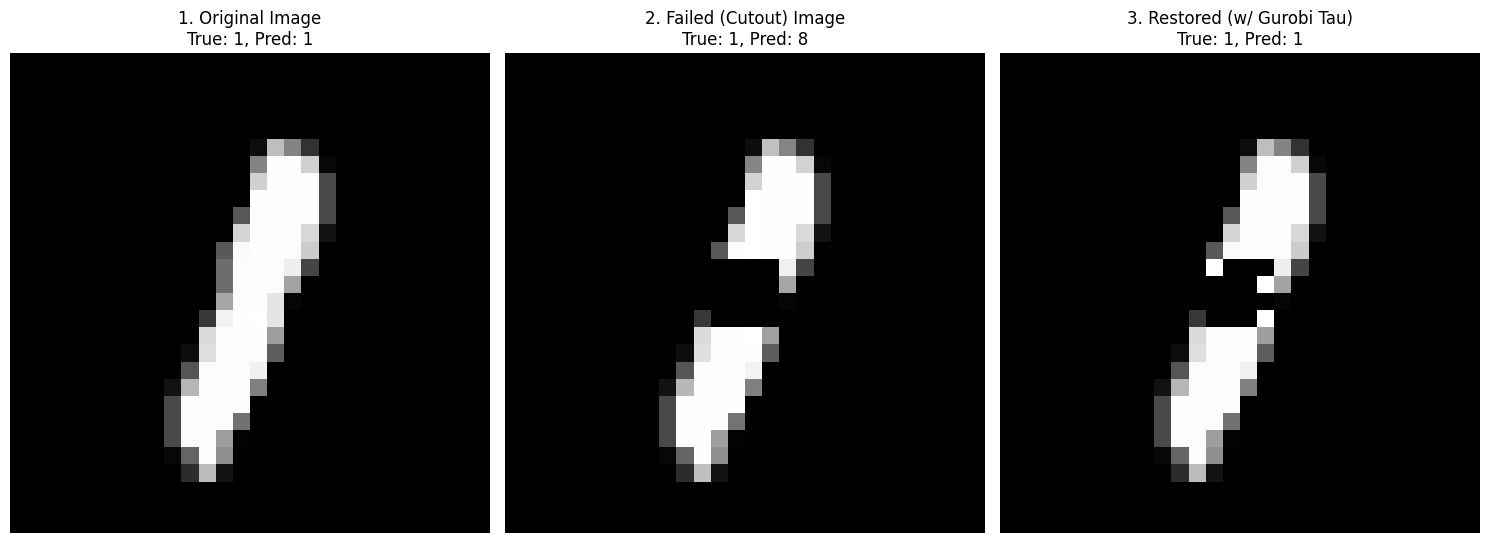


--- TEST 48/100: Image Index 1760 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1760 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   8 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


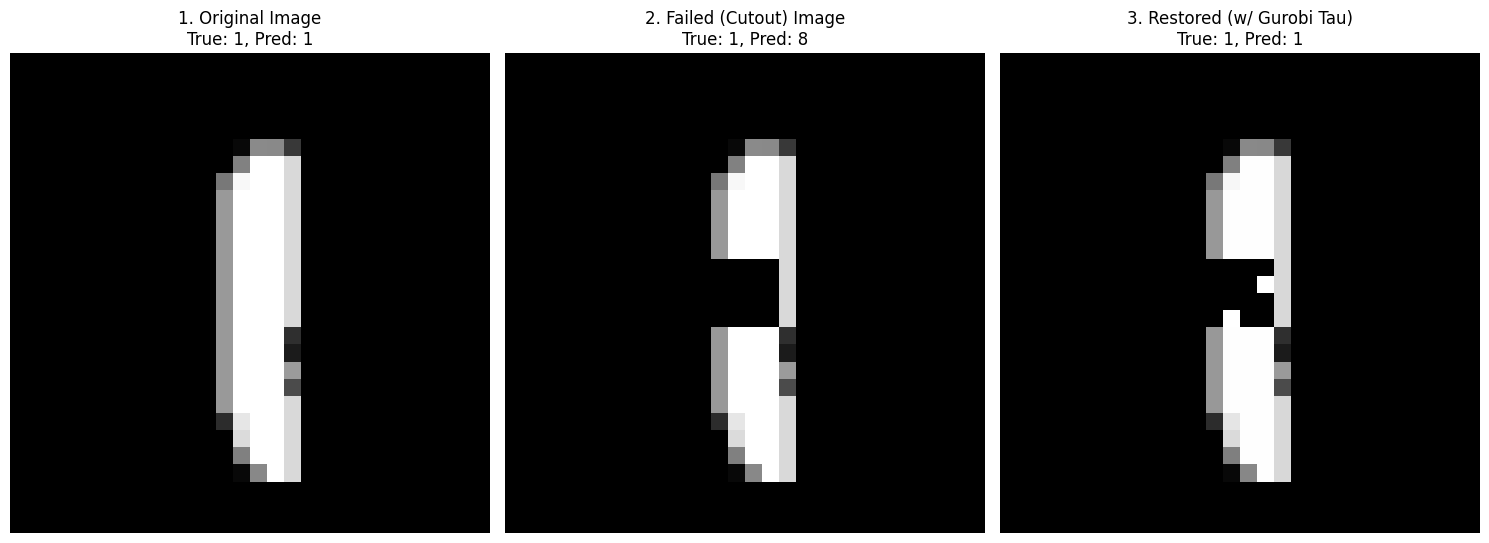


--- TEST 49/100: Image Index 1769 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1769 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


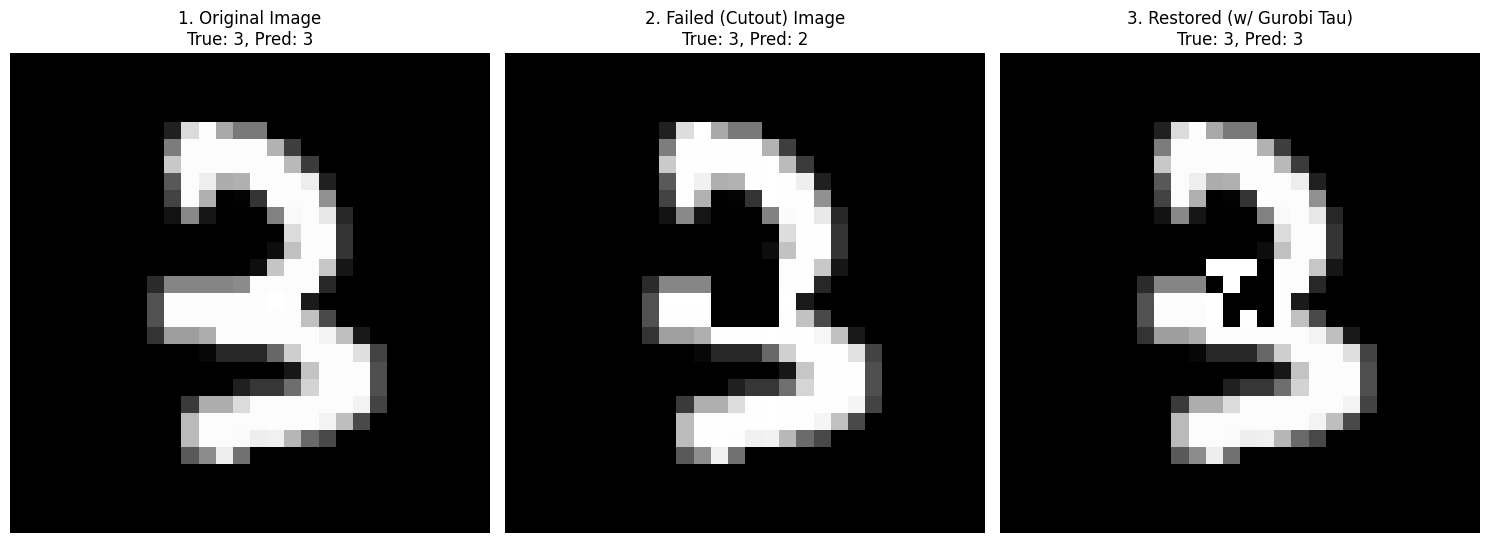


--- TEST 50/100: Image Index 1774 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 1774 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


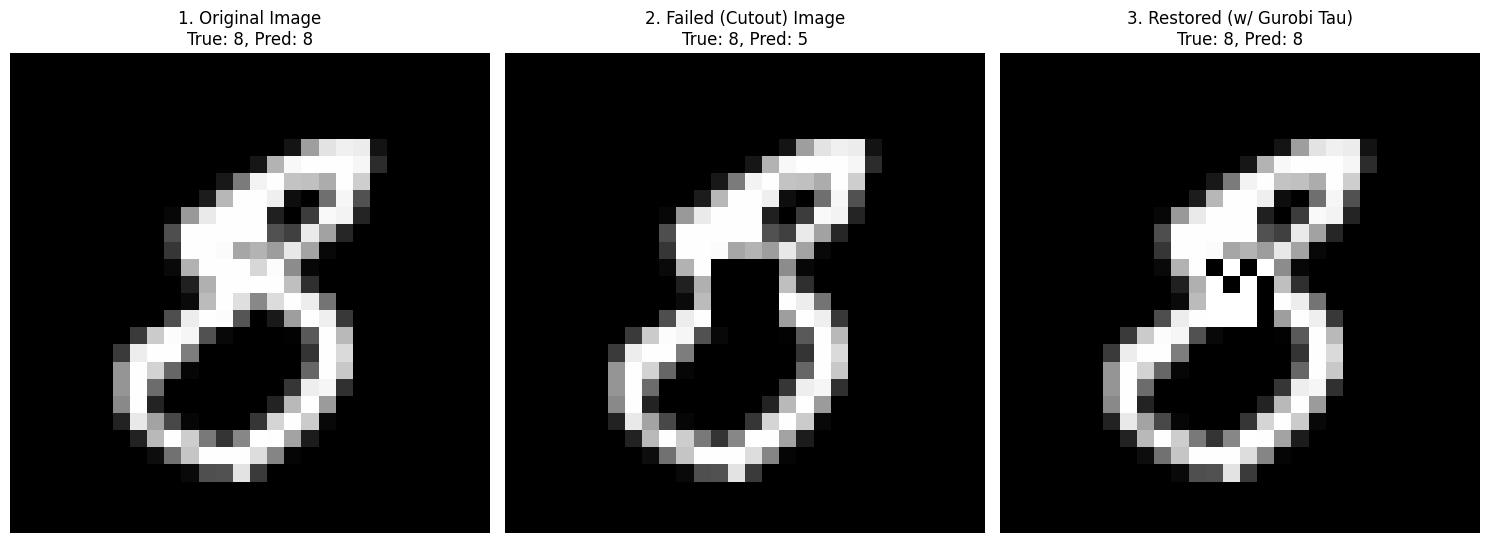


--- TEST 51/100: Image Index 18 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 18.

--- TEST 52/100: Image Index 184 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 c

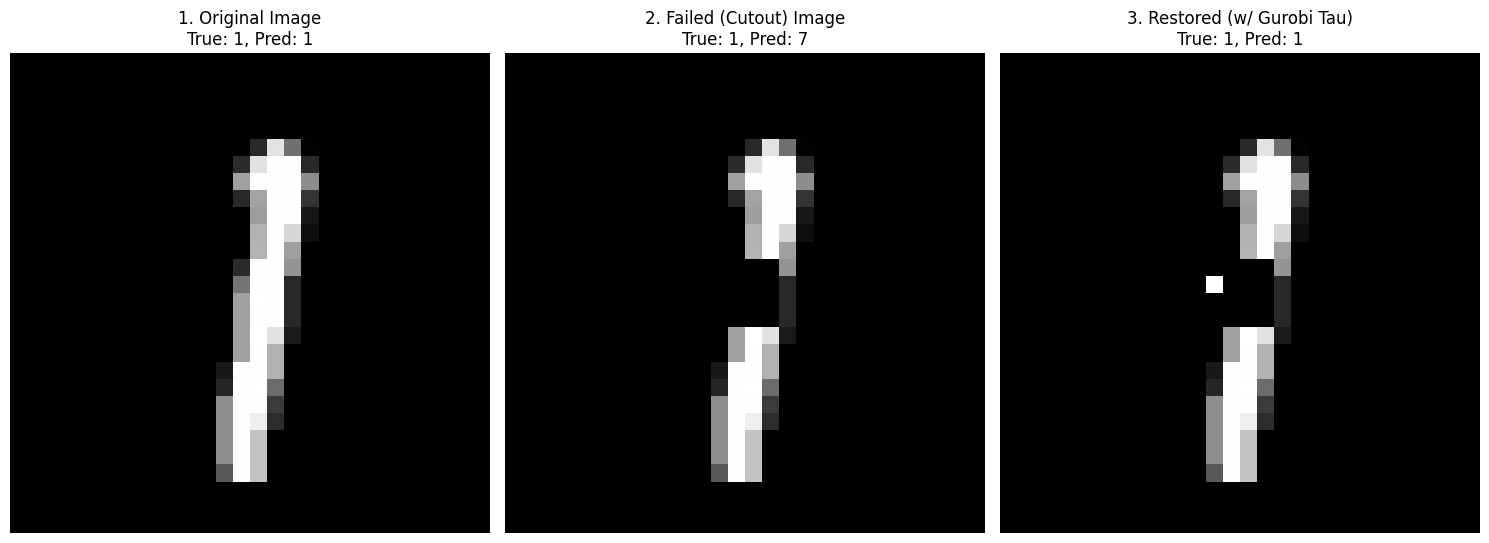


--- TEST 54/100: Image Index 20 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 20 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


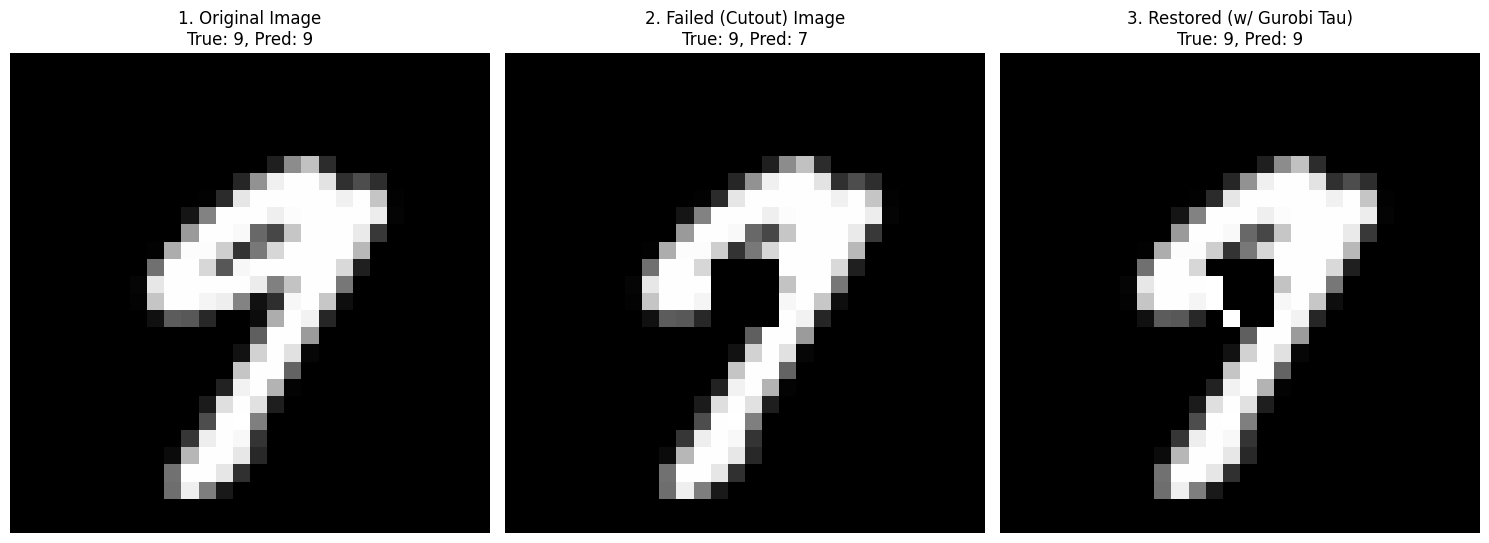


--- TEST 55/100: Image Index 200 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 200 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   8 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


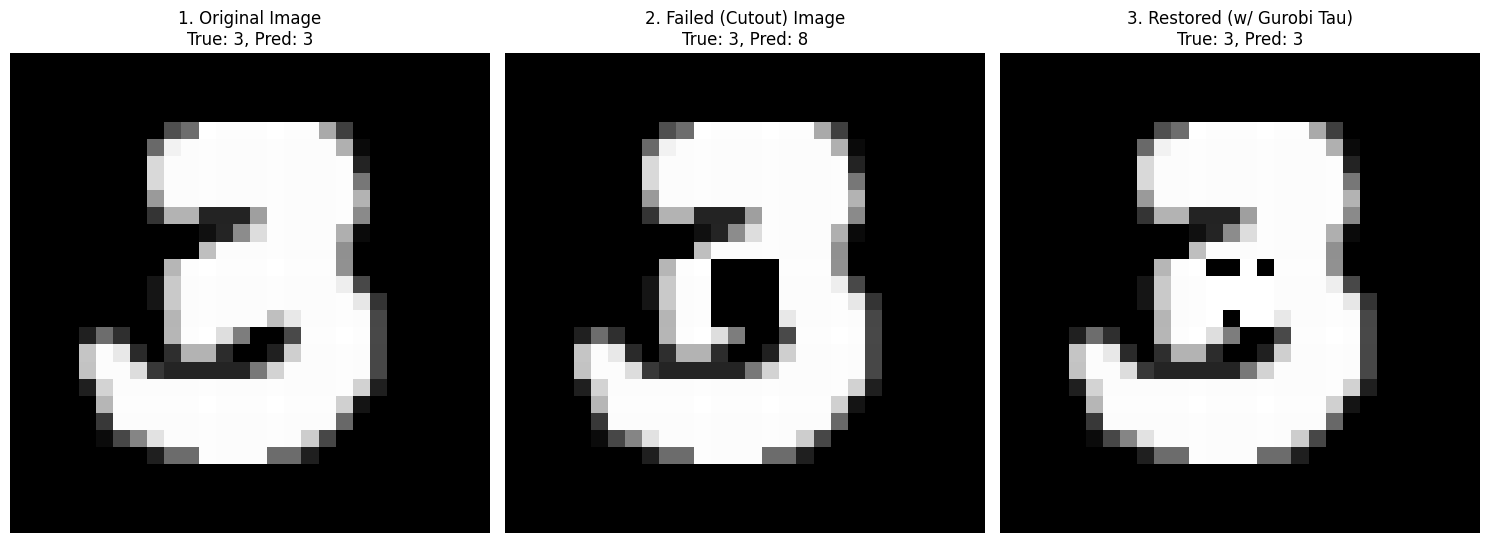


--- TEST 56/100: Image Index 213 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 213 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


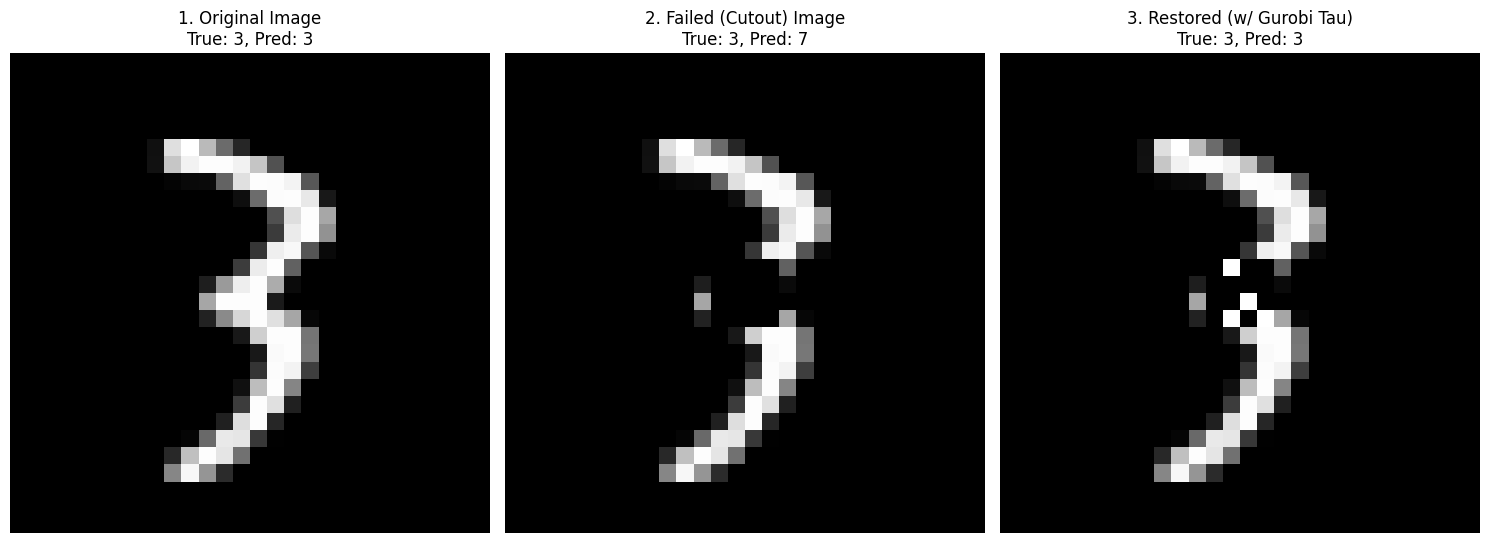


--- TEST 57/100: Image Index 233 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 233 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


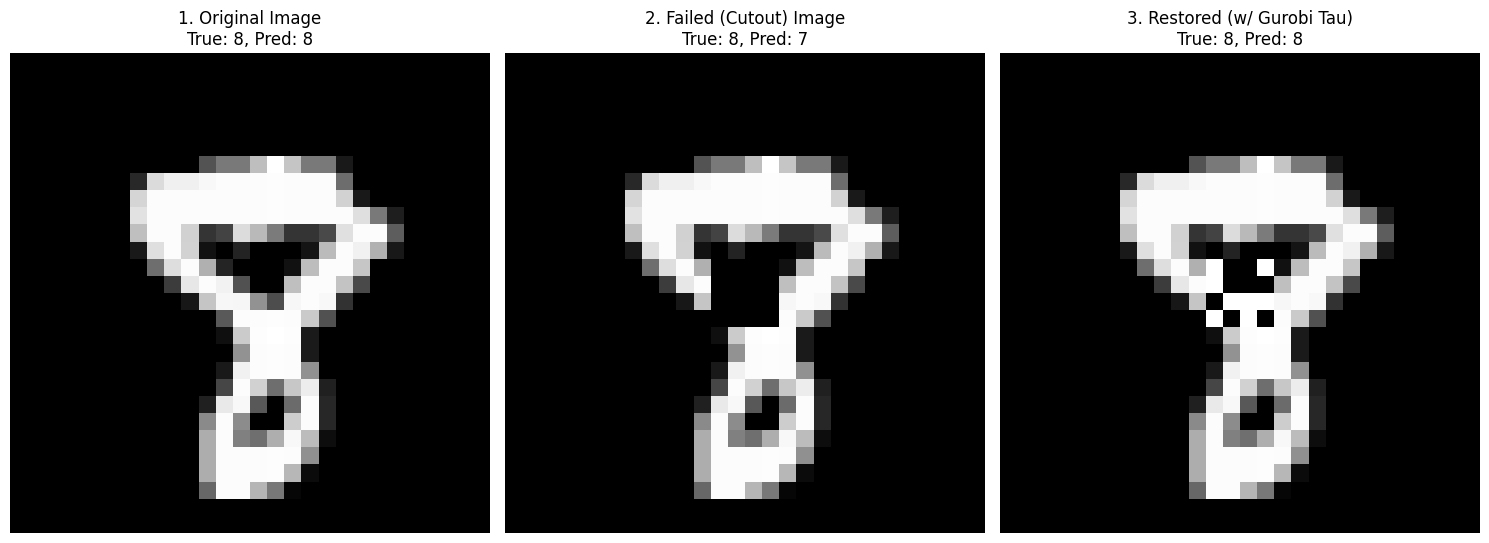


--- TEST 58/100: Image Index 266 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 266.

--- TEST 59/100: Image Index 320 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750

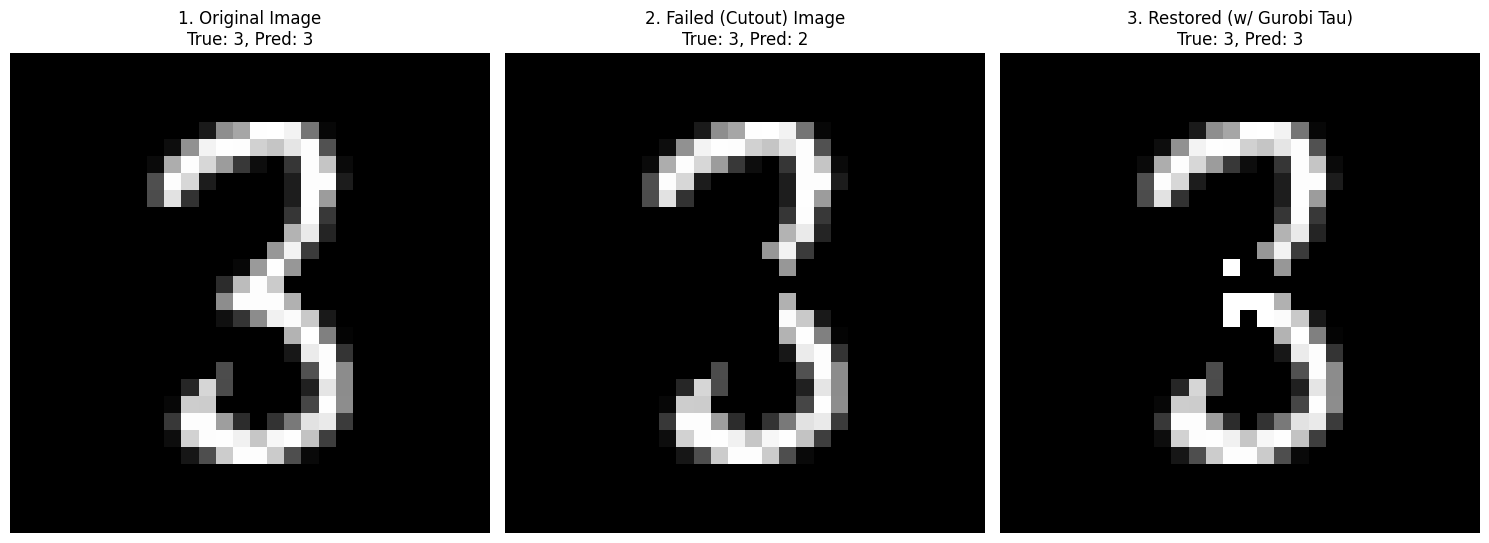


--- TEST 62/100: Image Index 344 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 344 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


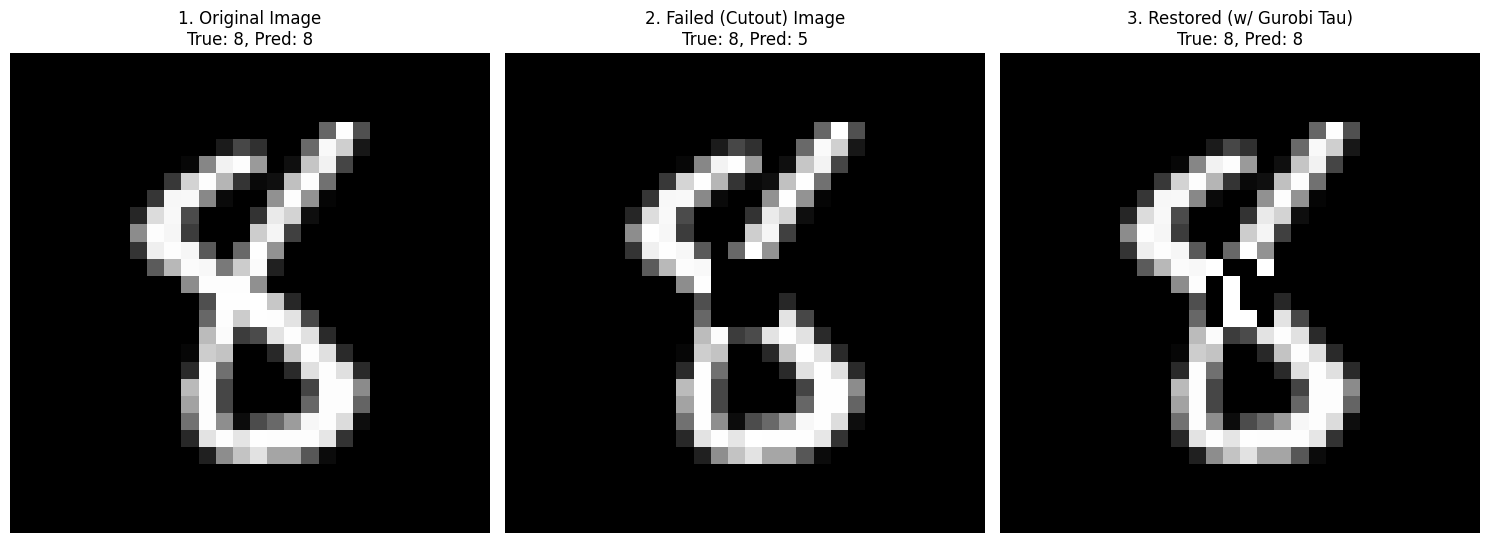


--- TEST 63/100: Image Index 389 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 389 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


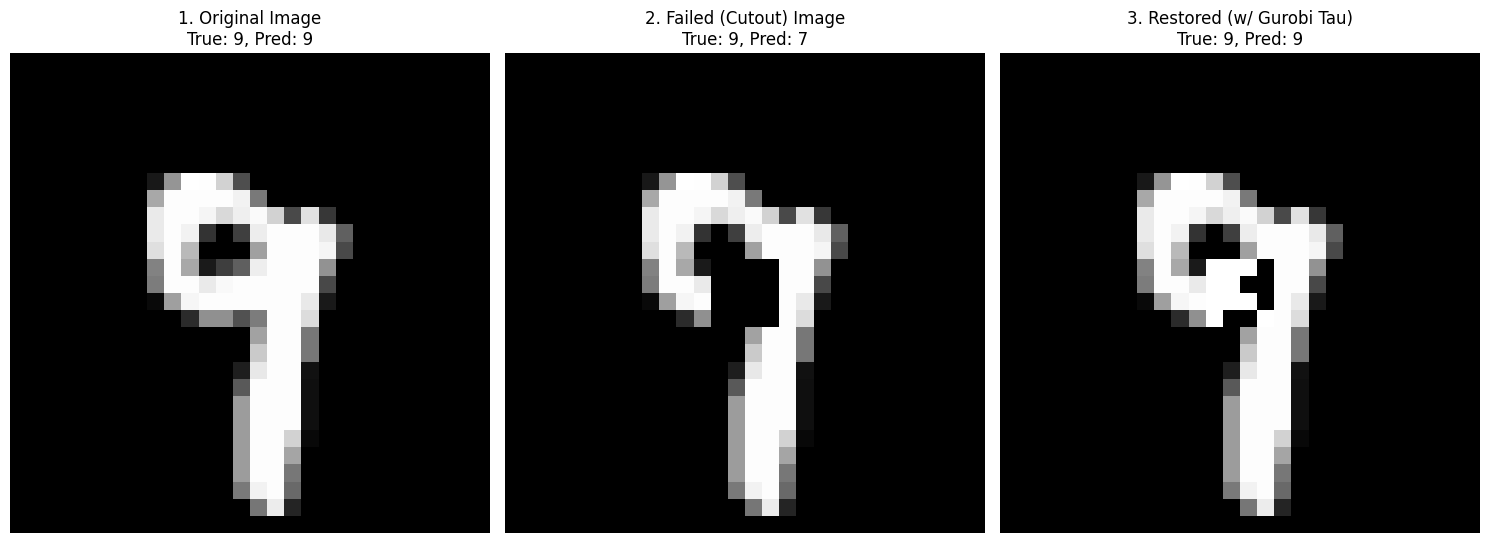


--- TEST 64/100: Image Index 401 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 401 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


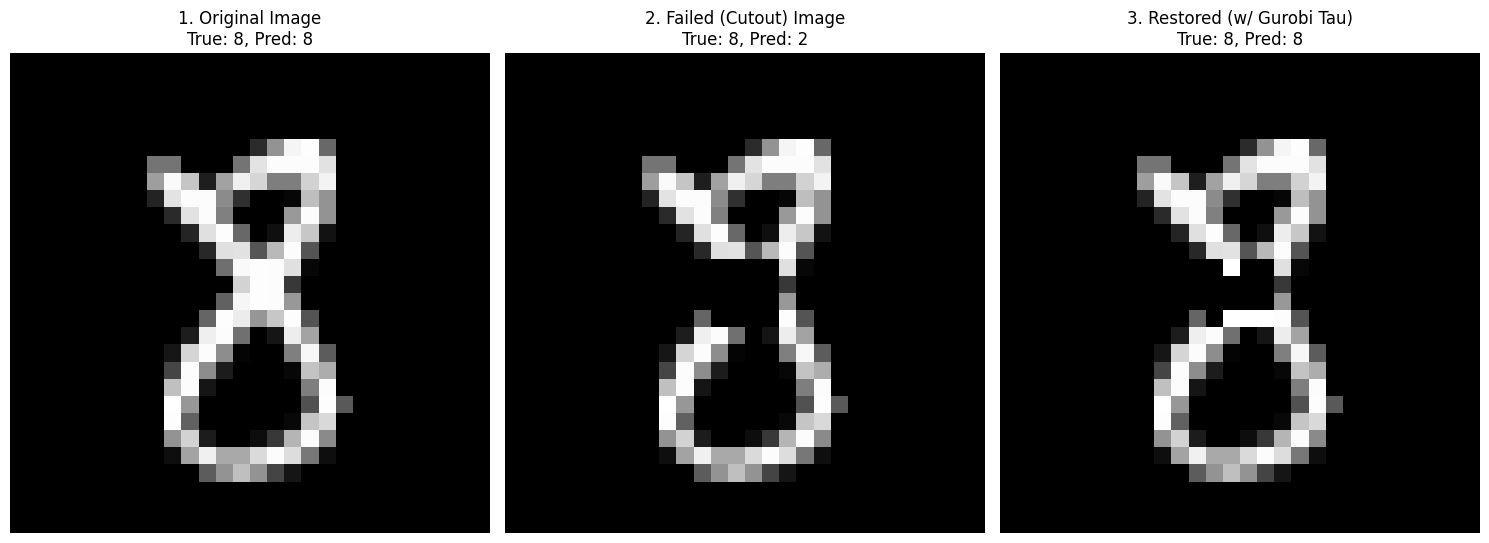


--- TEST 65/100: Image Index 409 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 409 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   4 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


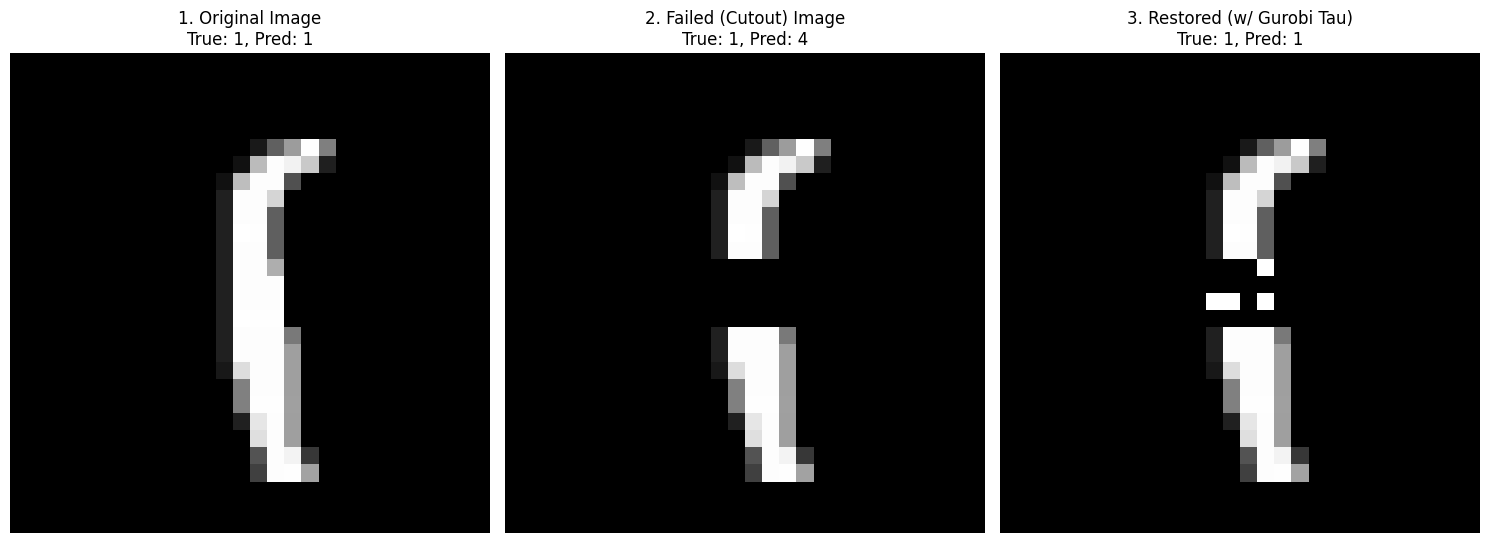


--- TEST 66/100: Image Index 44 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 44 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


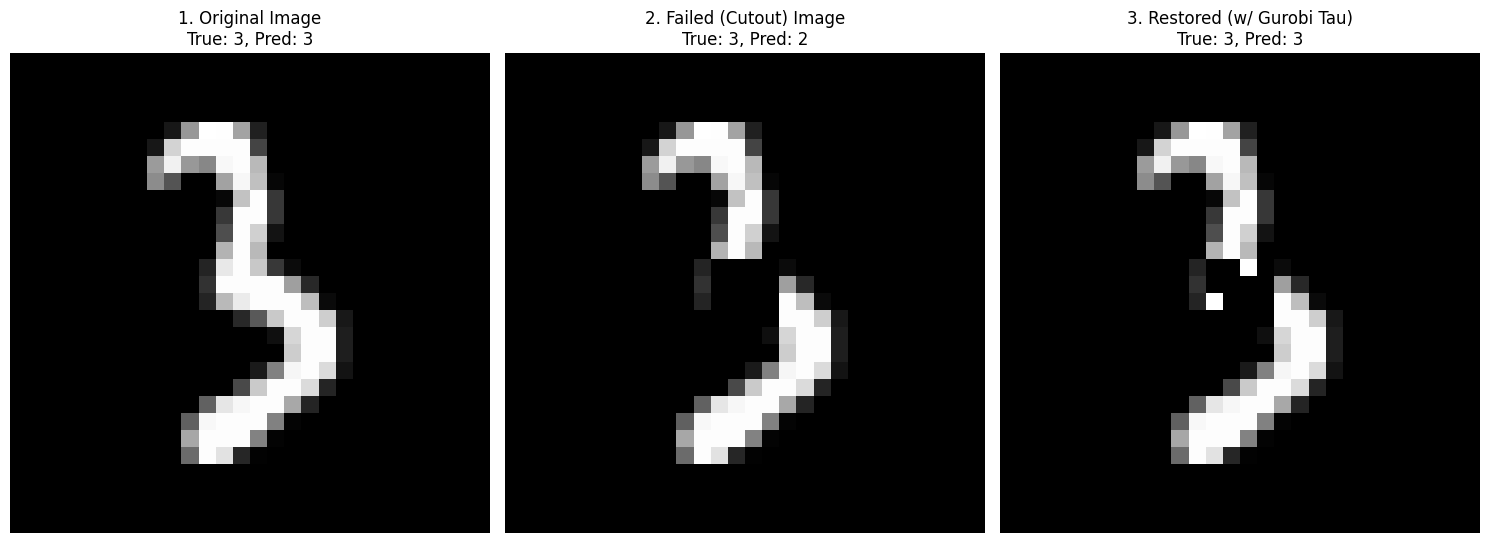


--- TEST 67/100: Image Index 464 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 464 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


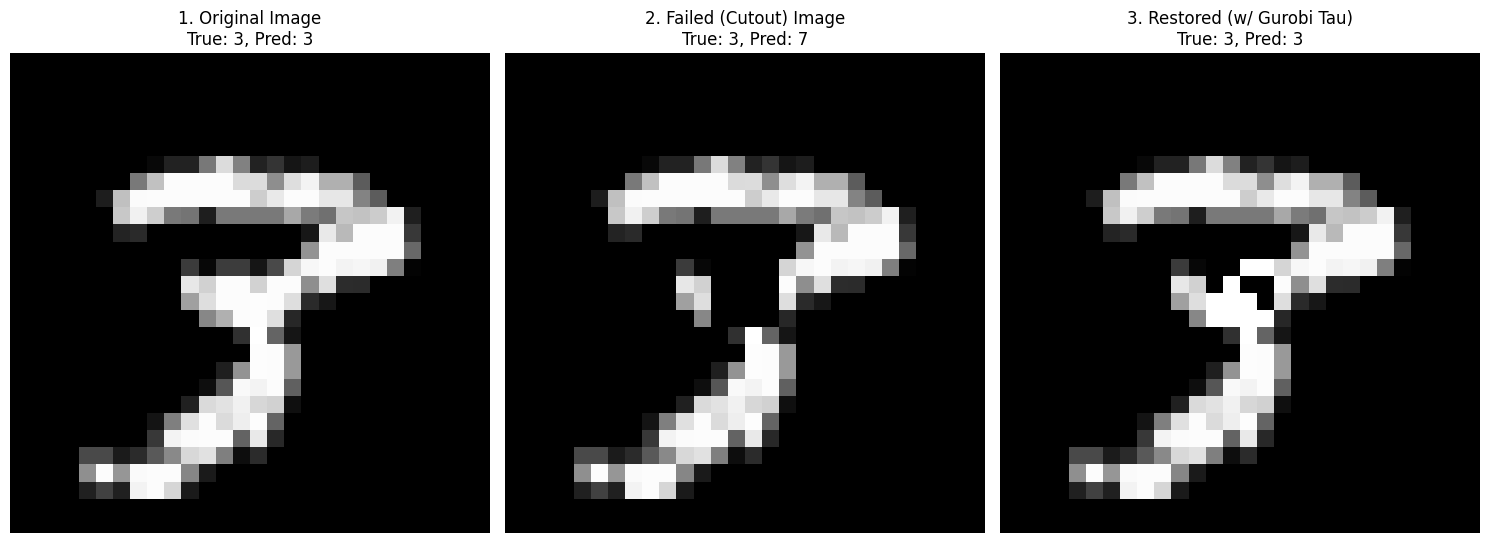


--- TEST 68/100: Image Index 495 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 495 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


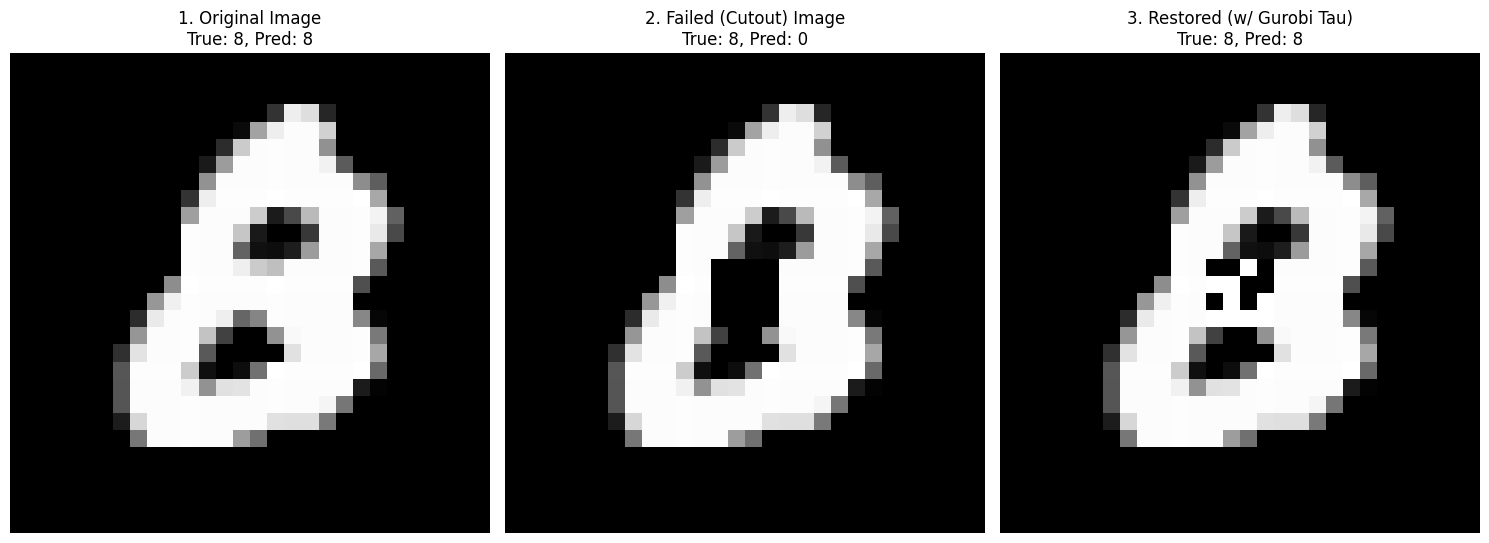


--- TEST 69/100: Image Index 504 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 504 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   4 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


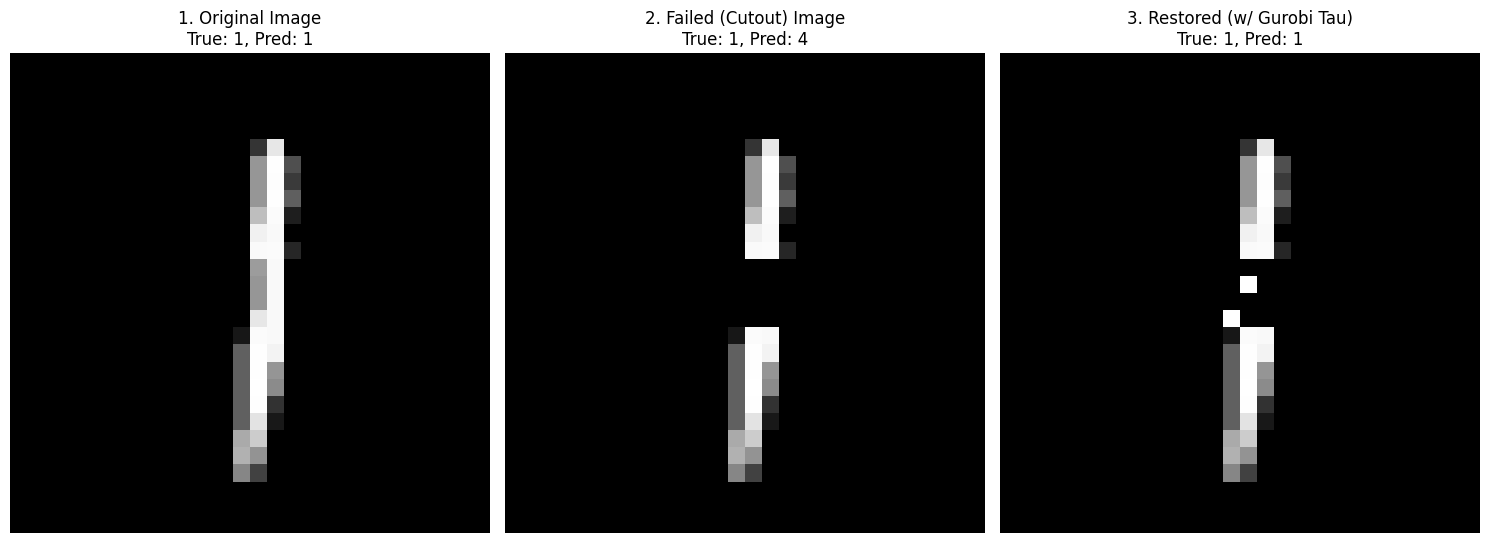


--- TEST 70/100: Image Index 531 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 531 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


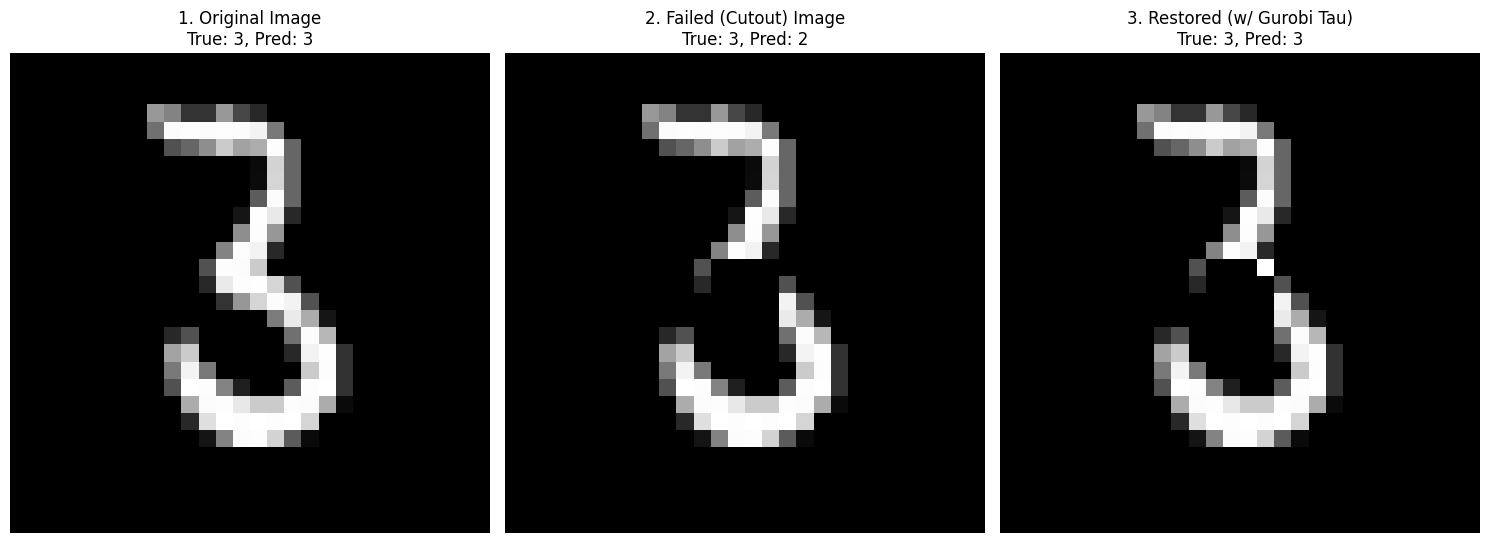


--- TEST 71/100: Image Index 543 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 543 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


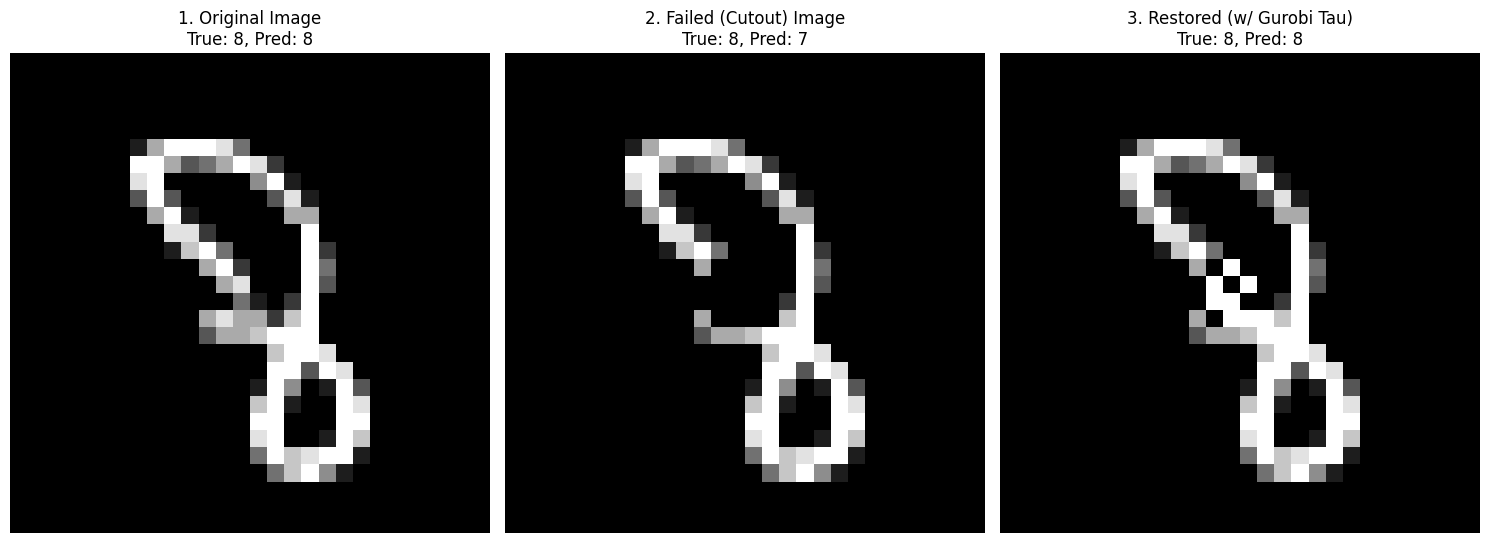


--- TEST 72/100: Image Index 548 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 548 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


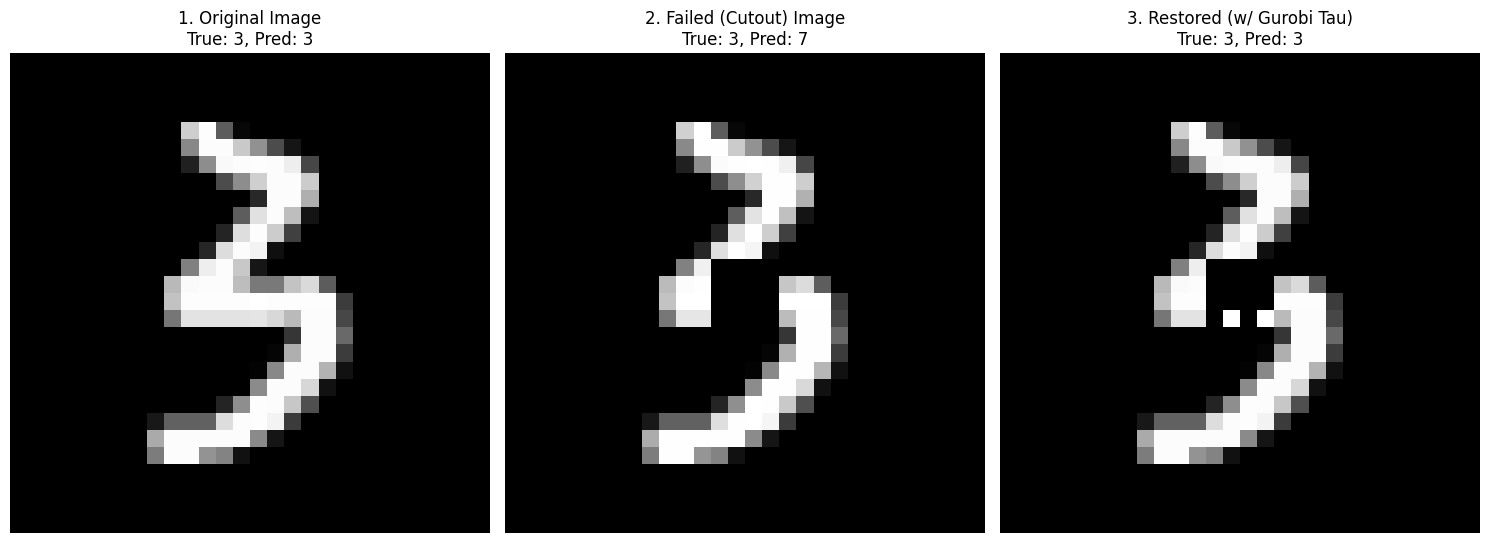


--- TEST 73/100: Image Index 583 ---
Running Gurobi to find corrective 'tau' patch for target 2...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 583.

--- TEST 74/100: Image Index 593 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750

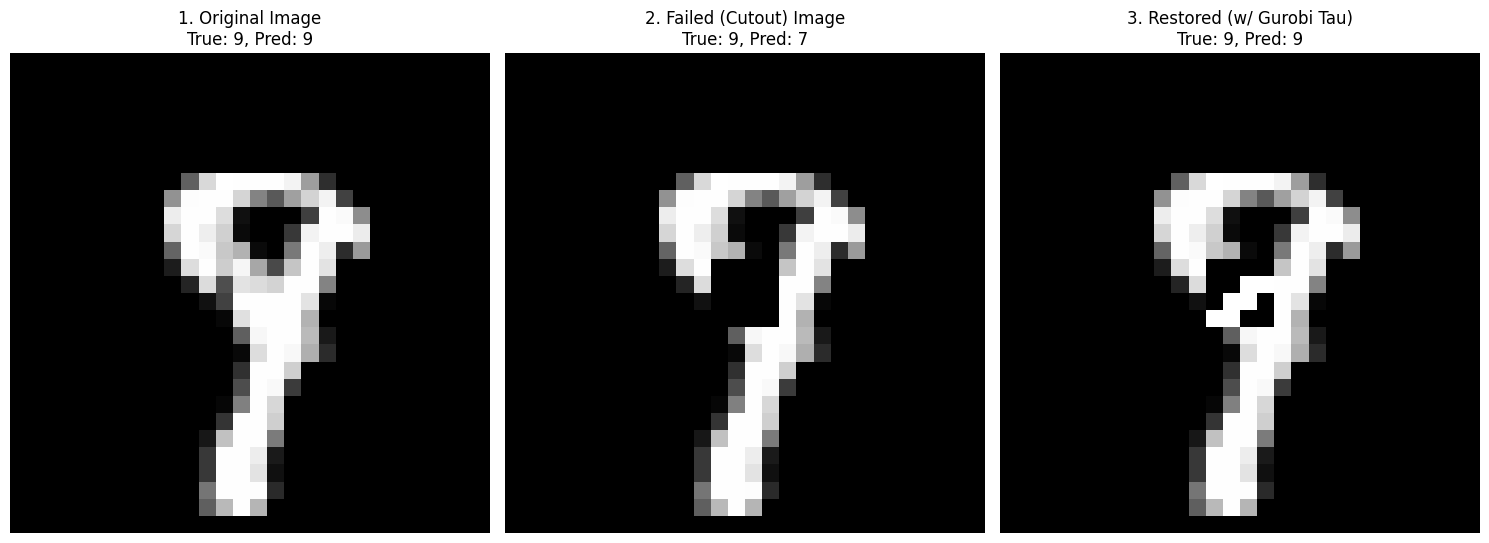


--- TEST 75/100: Image Index 616 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 616 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


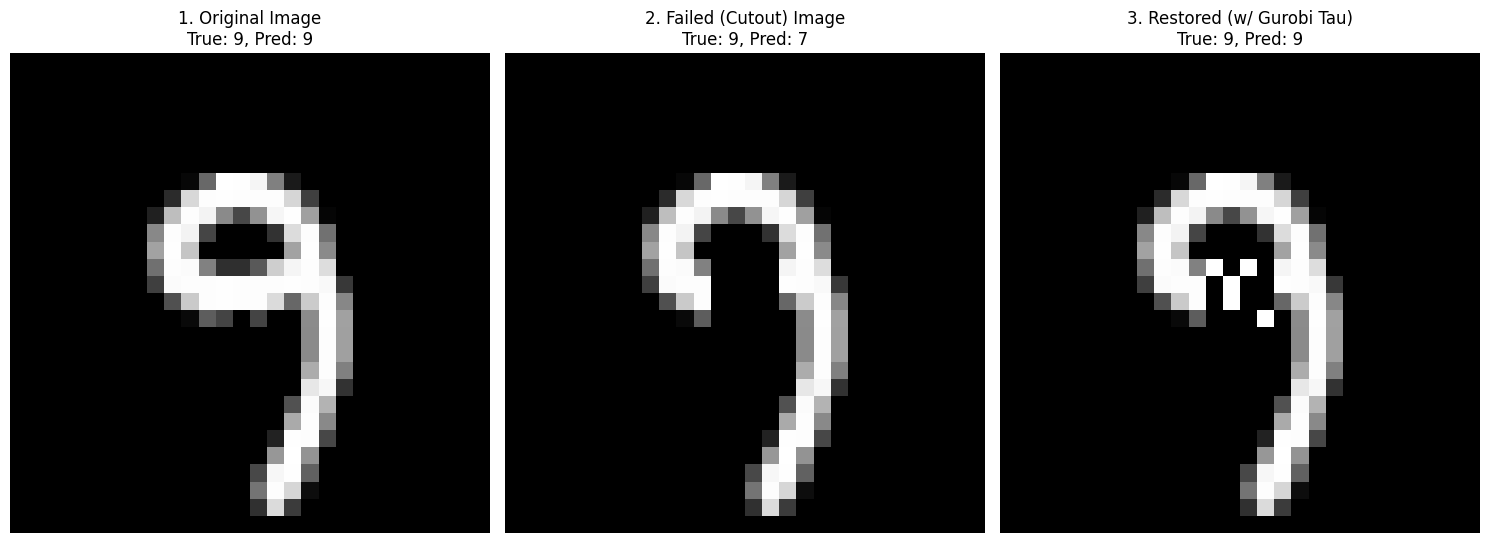


--- TEST 76/100: Image Index 628 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 628 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


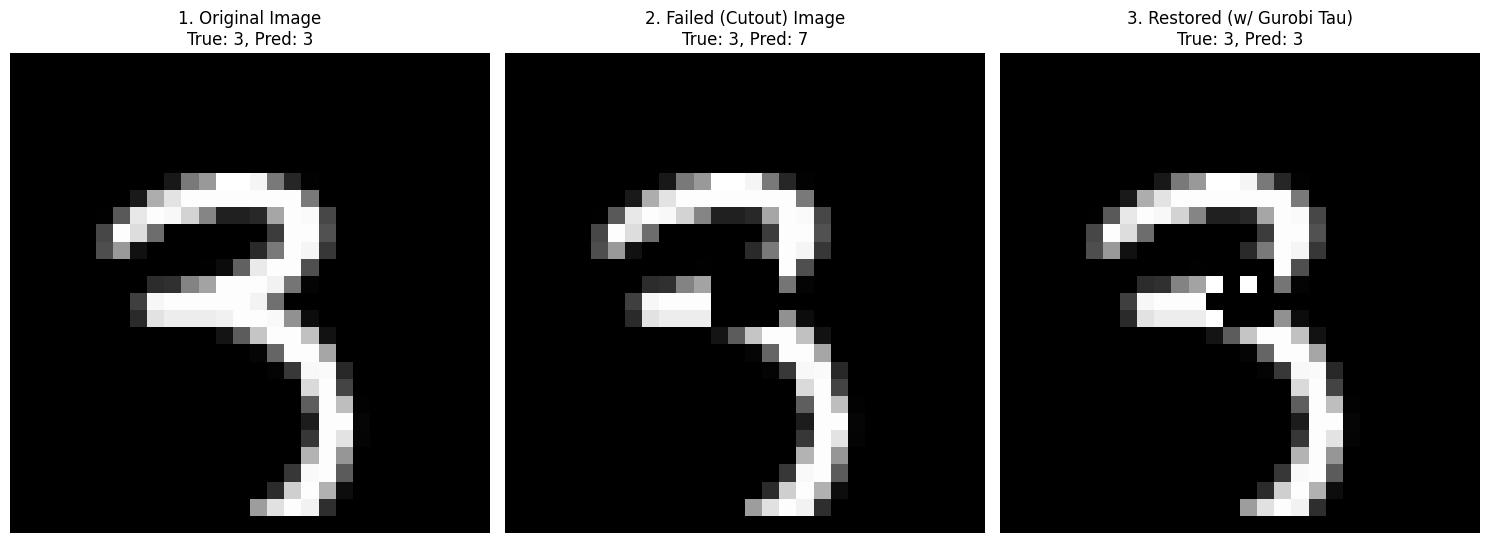


--- TEST 77/100: Image Index 63 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 63 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


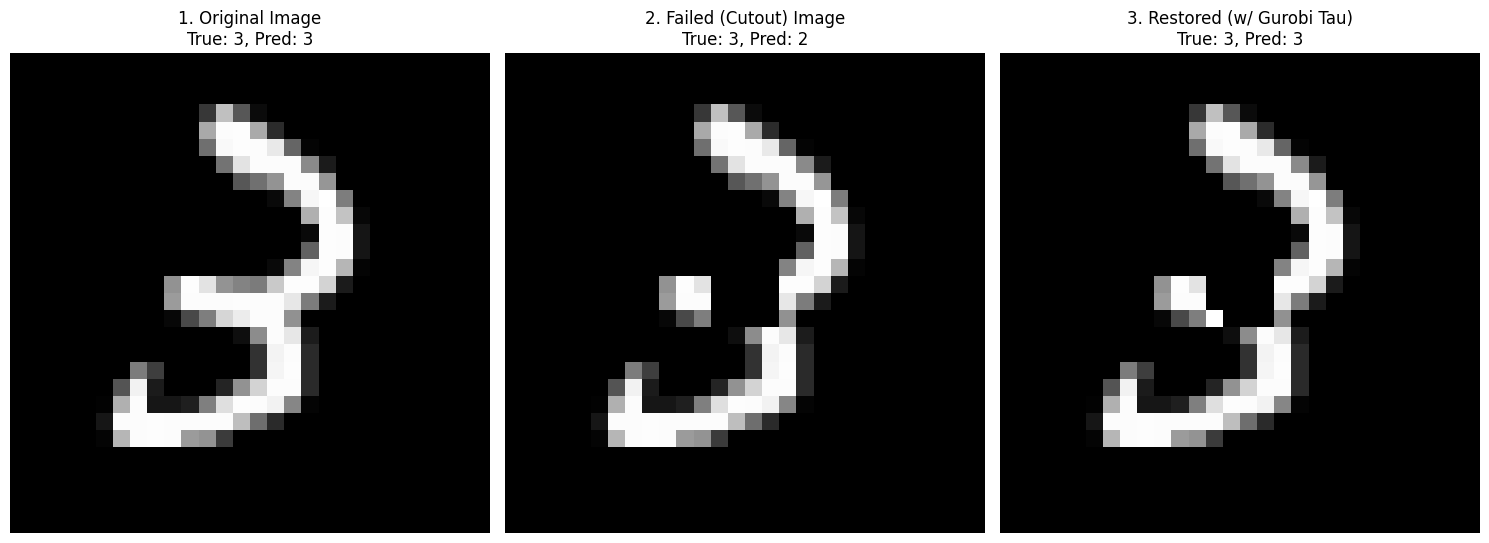


--- TEST 78/100: Image Index 684 ---
Running Gurobi to find corrective 'tau' patch for target 7...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 684.

--- TEST 79/100: Image Index 685 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750

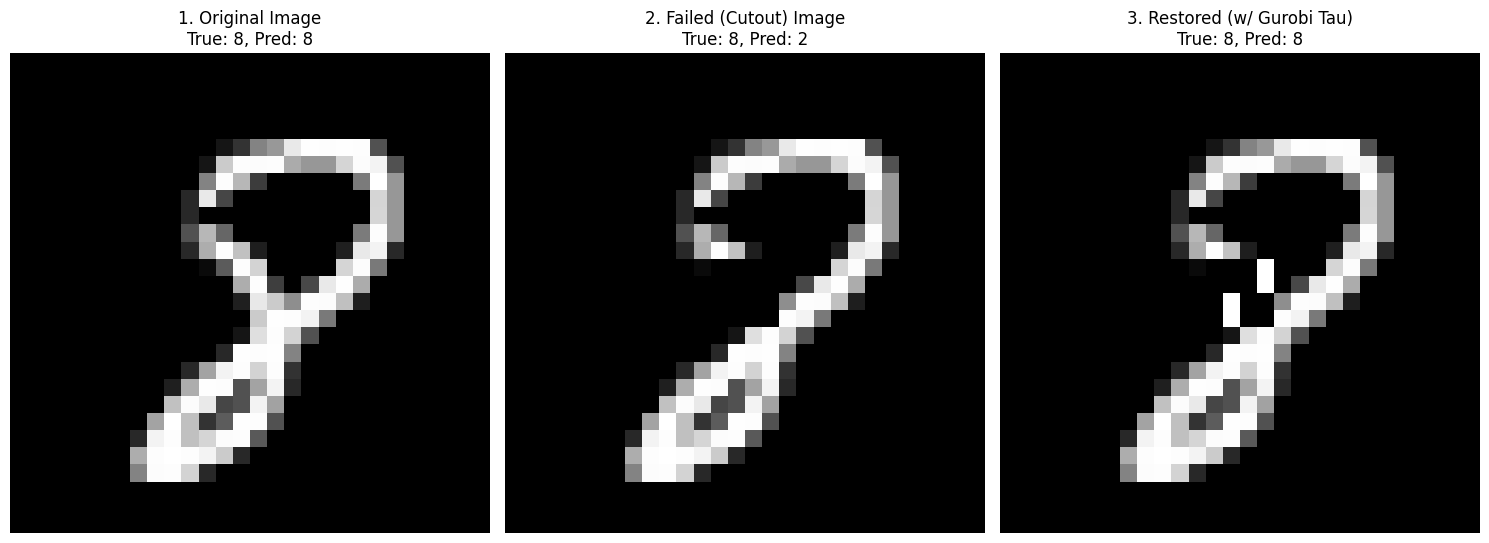


--- TEST 80/100: Image Index 686 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 686 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


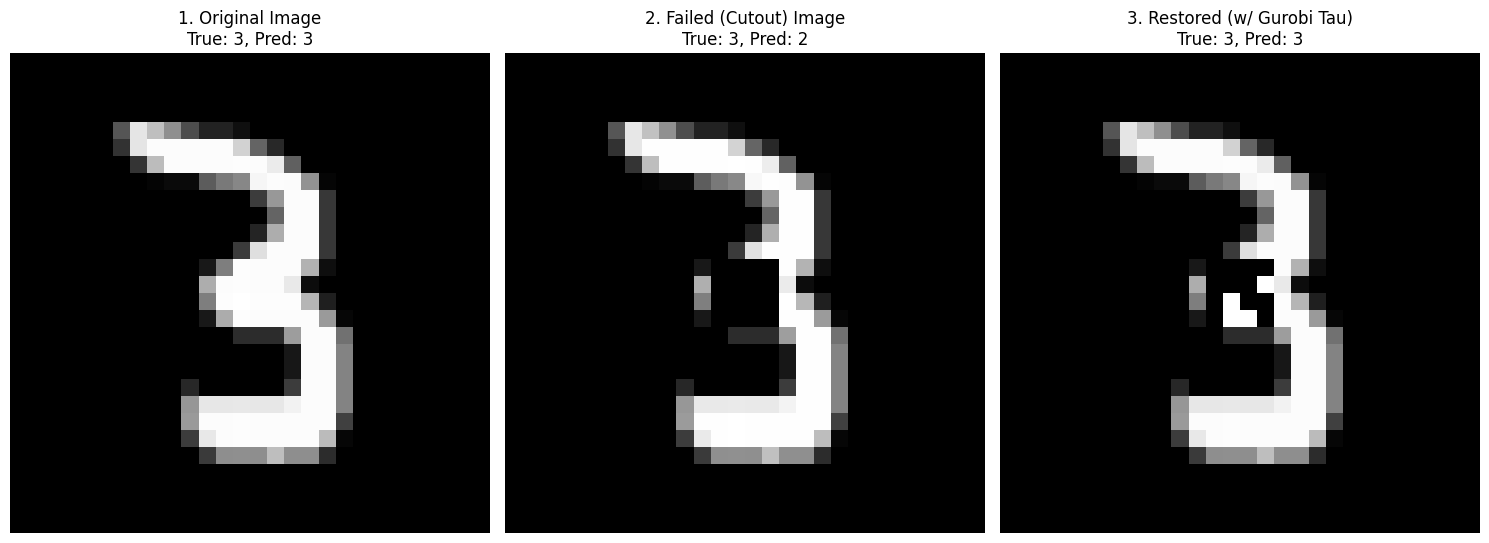


--- TEST 81/100: Image Index 691 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 691 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


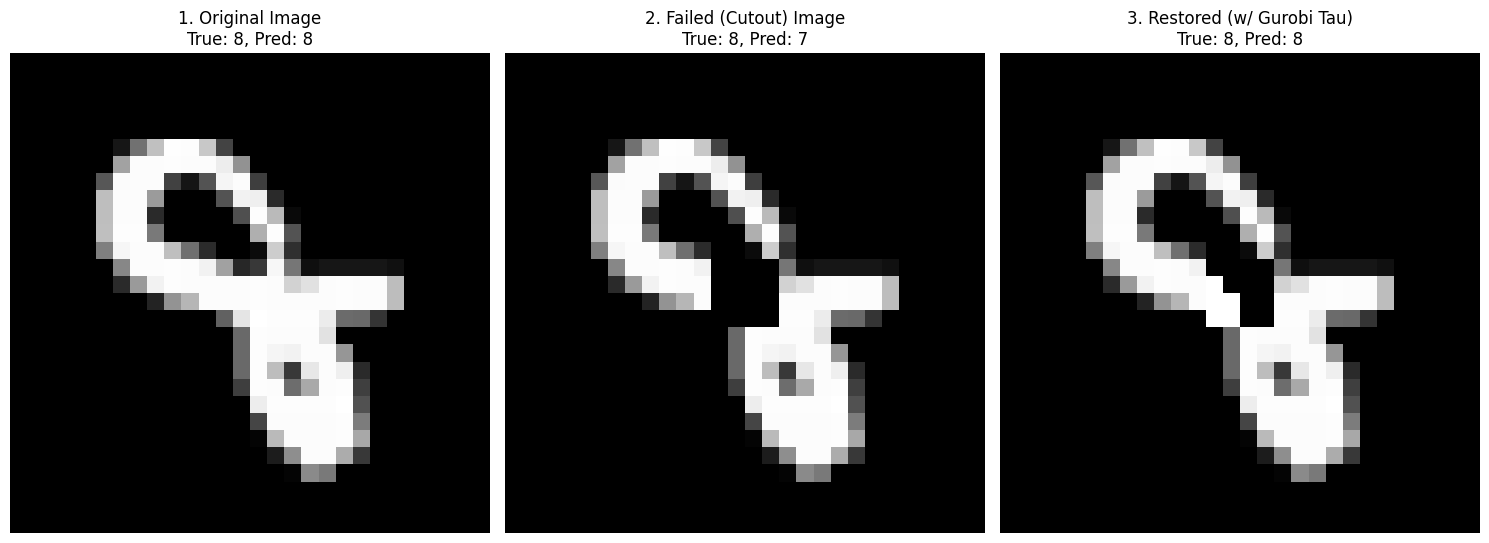


--- TEST 82/100: Image Index 699 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 699 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


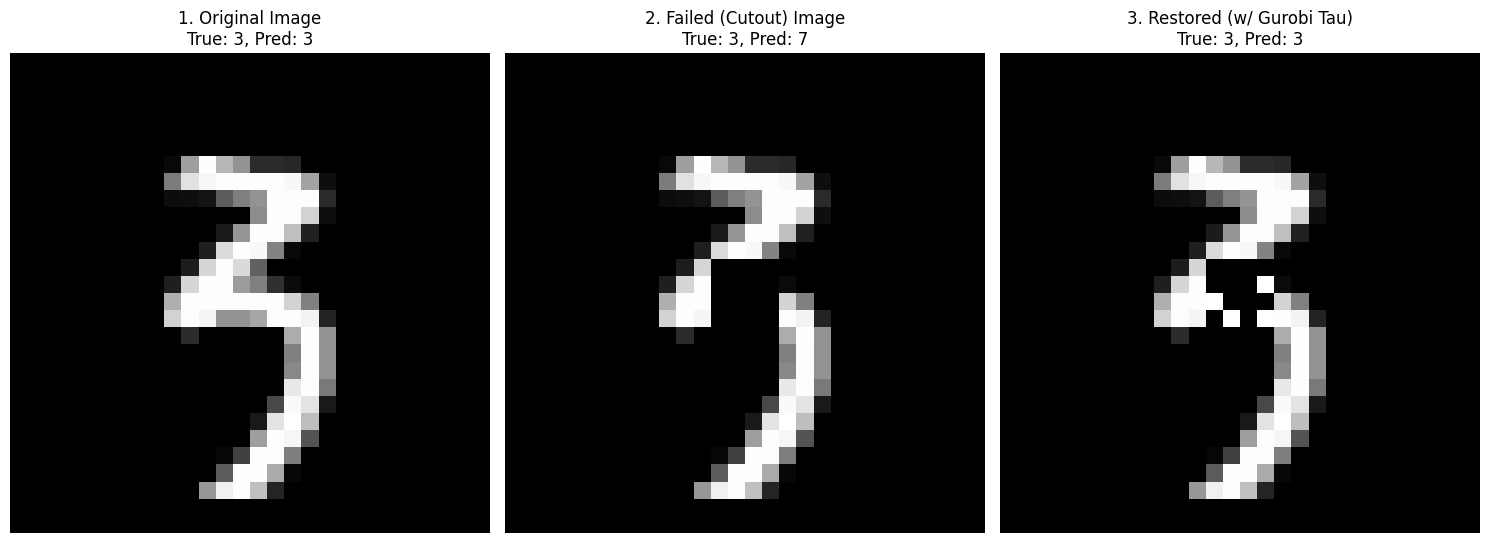


--- TEST 83/100: Image Index 716 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 716 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


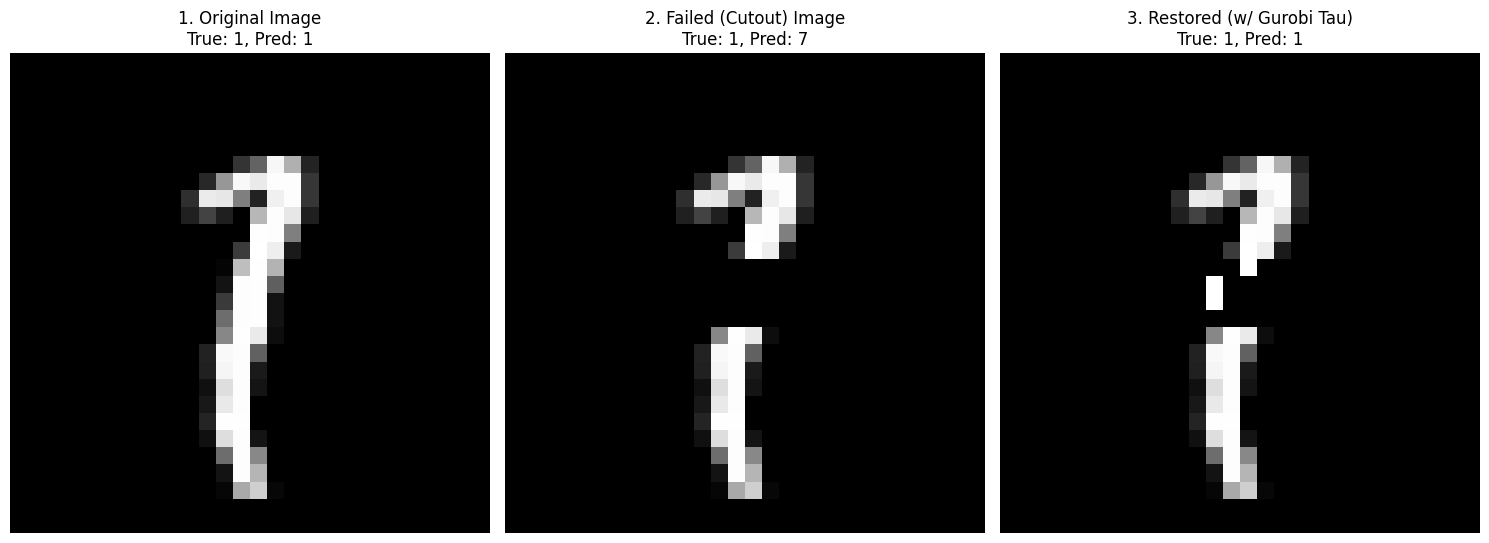


--- TEST 84/100: Image Index 718 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 718 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


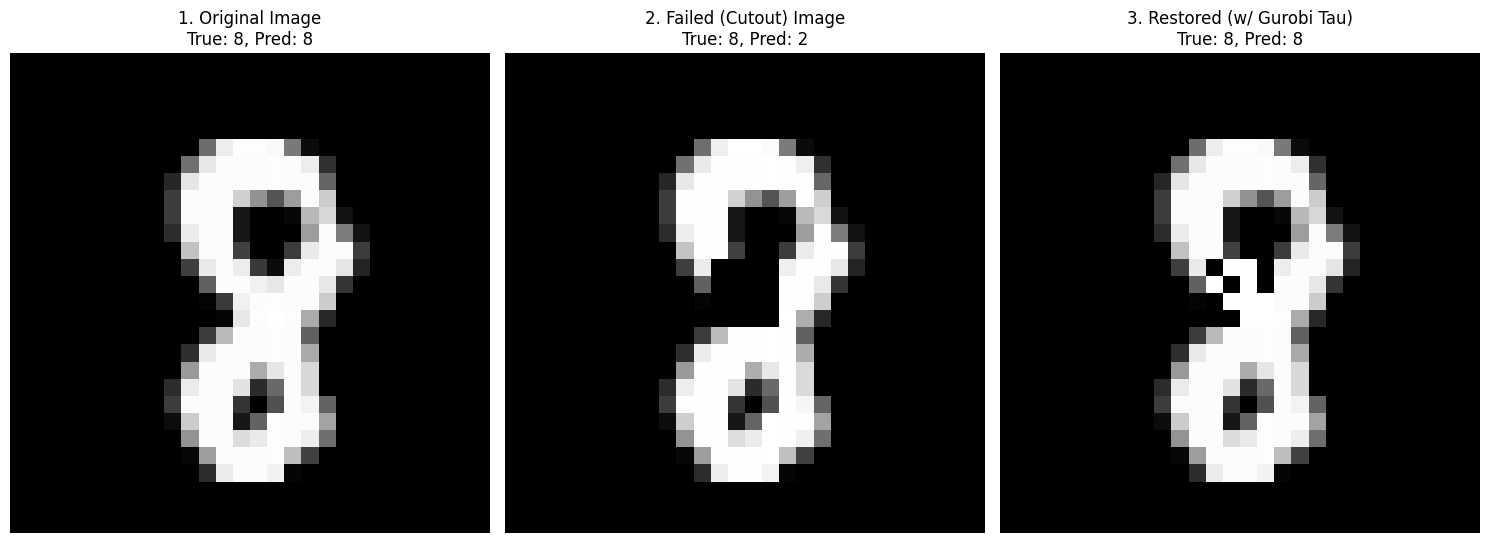


--- TEST 85/100: Image Index 73 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 73 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


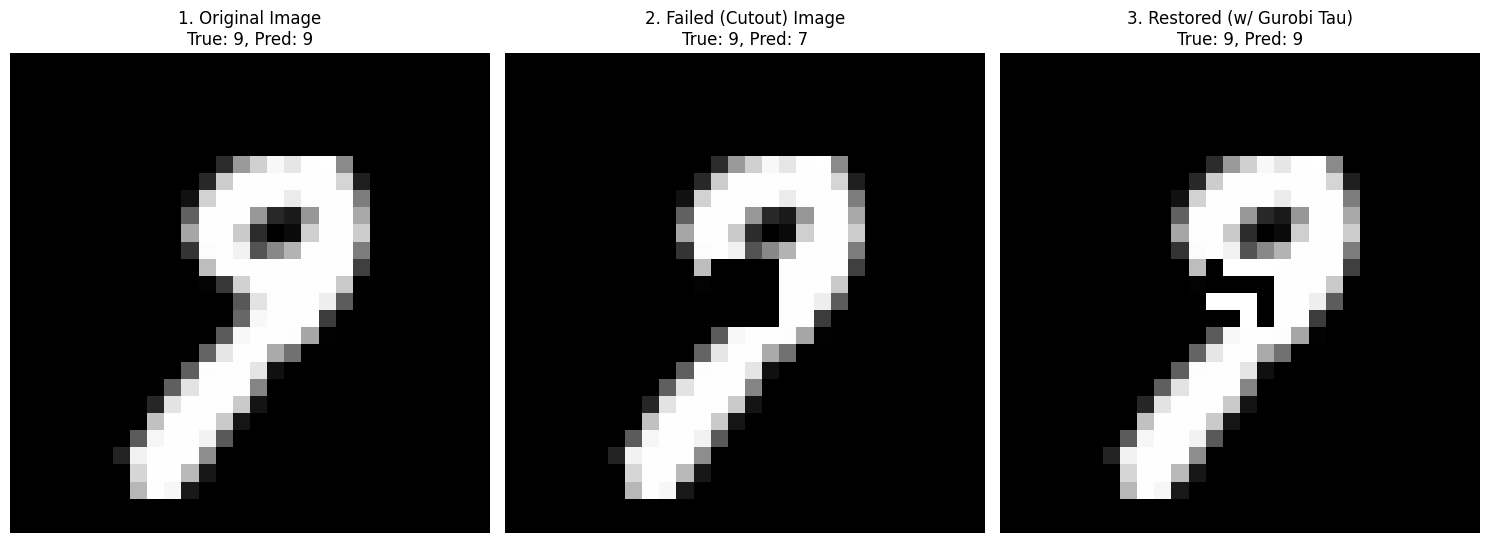


--- TEST 86/100: Image Index 753 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 753 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


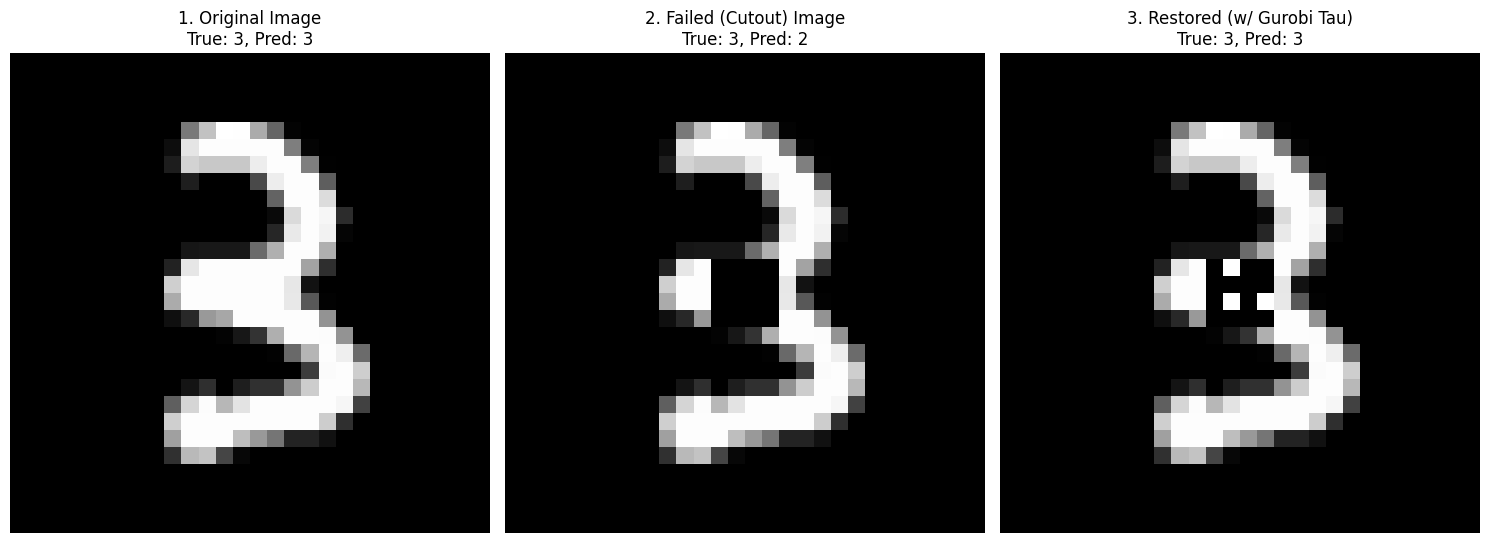


--- TEST 87/100: Image Index 759 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 759 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


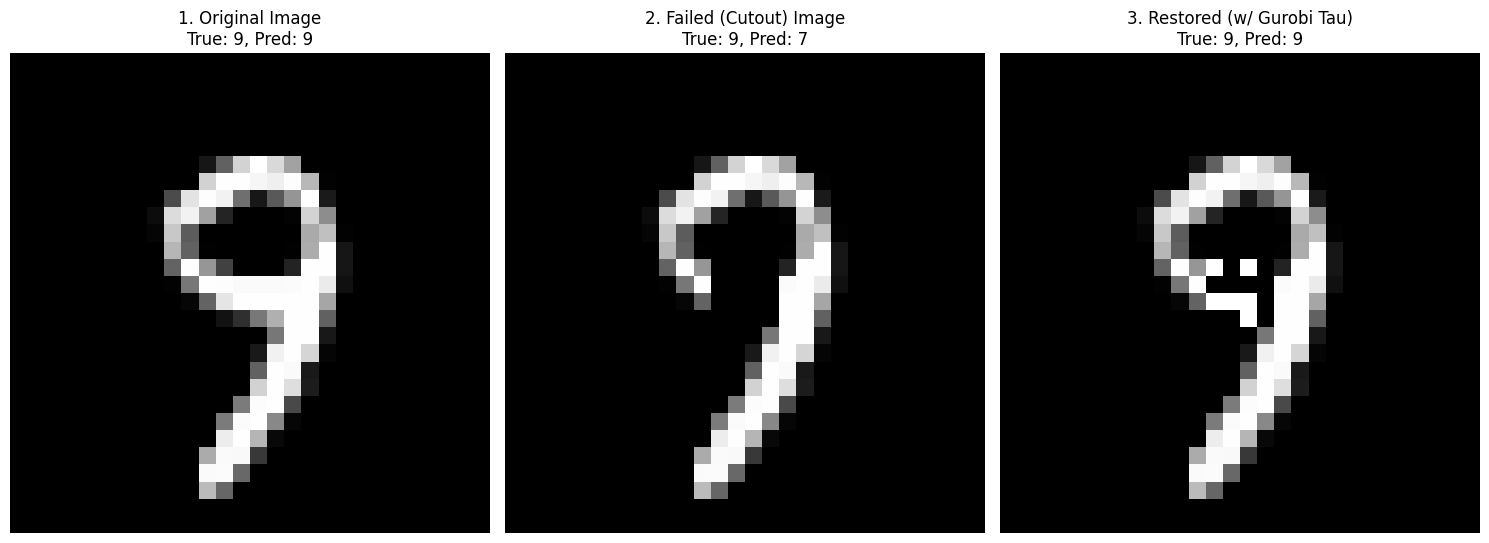


--- TEST 88/100: Image Index 78 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 78 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


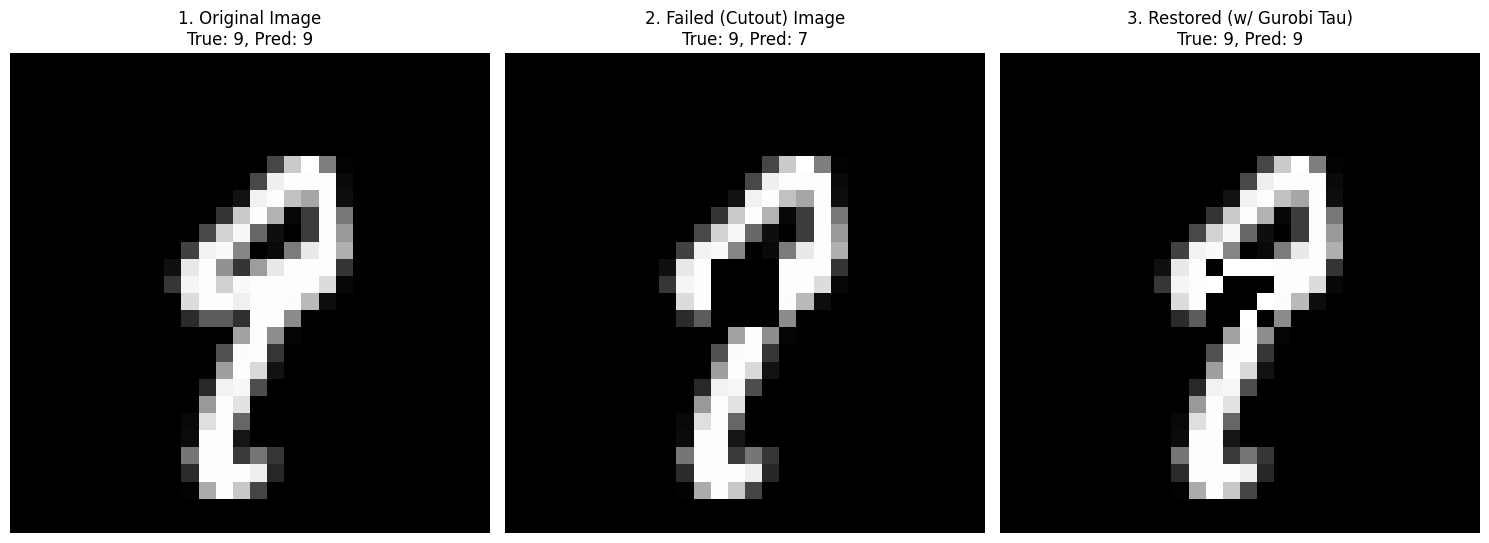


--- TEST 89/100: Image Index 780 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 780 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   5 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


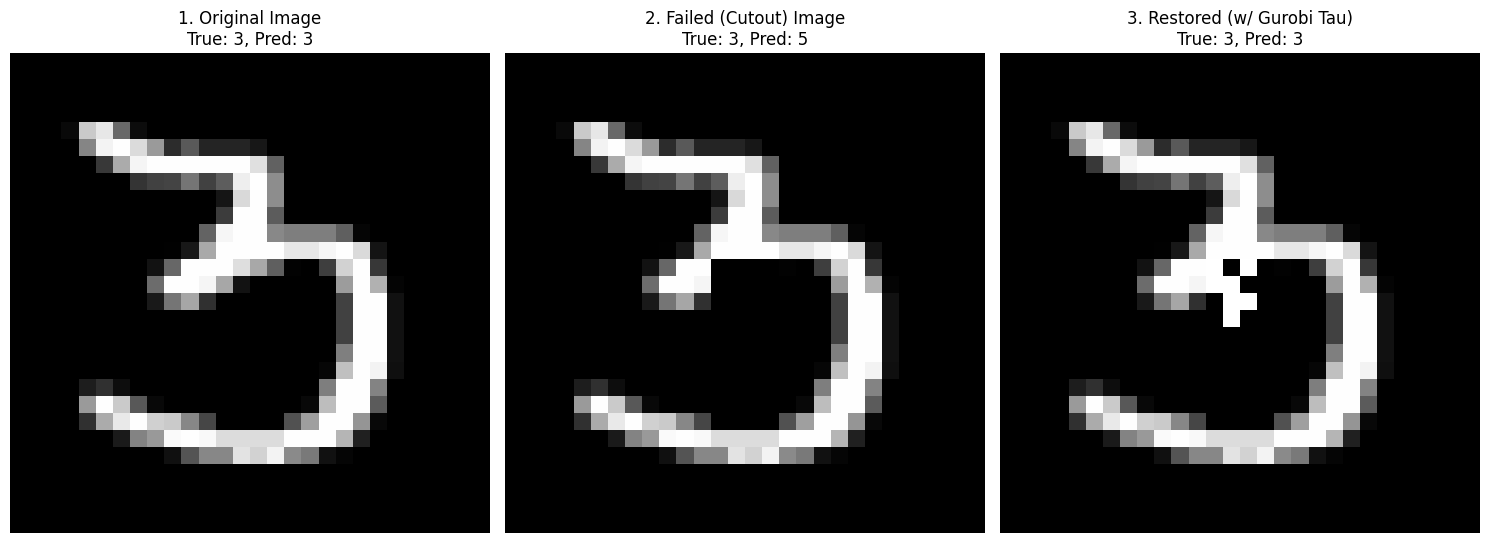


--- TEST 90/100: Image Index 800 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 800 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


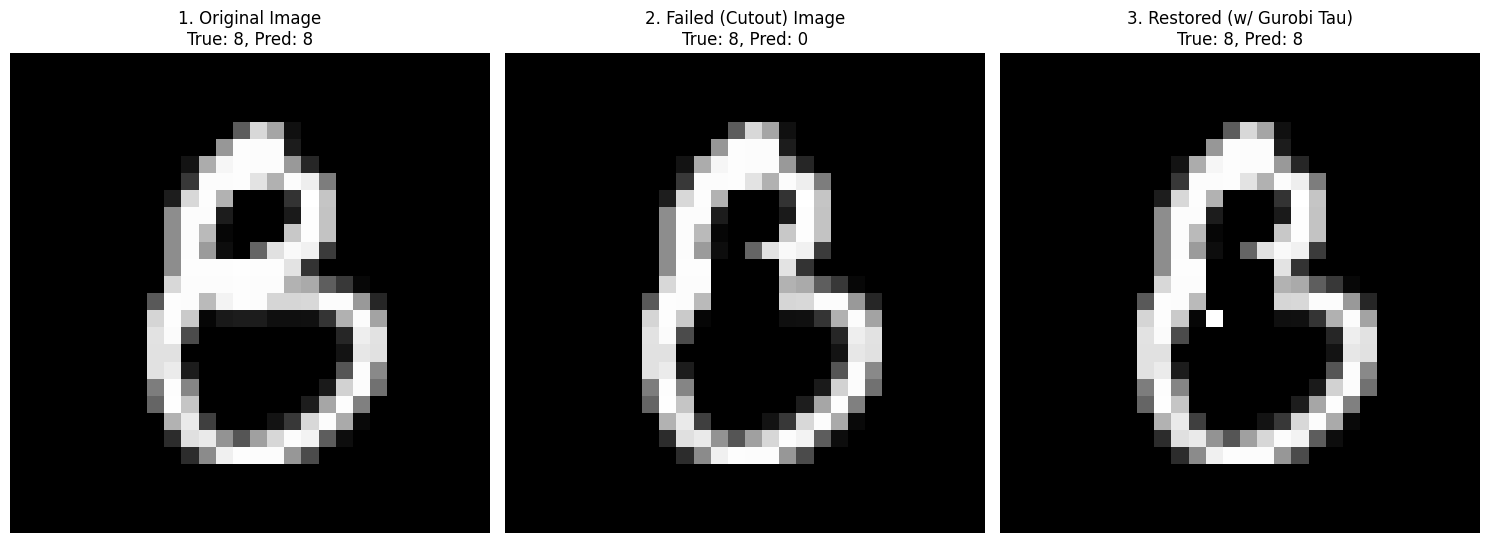


--- TEST 91/100: Image Index 833 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 833 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


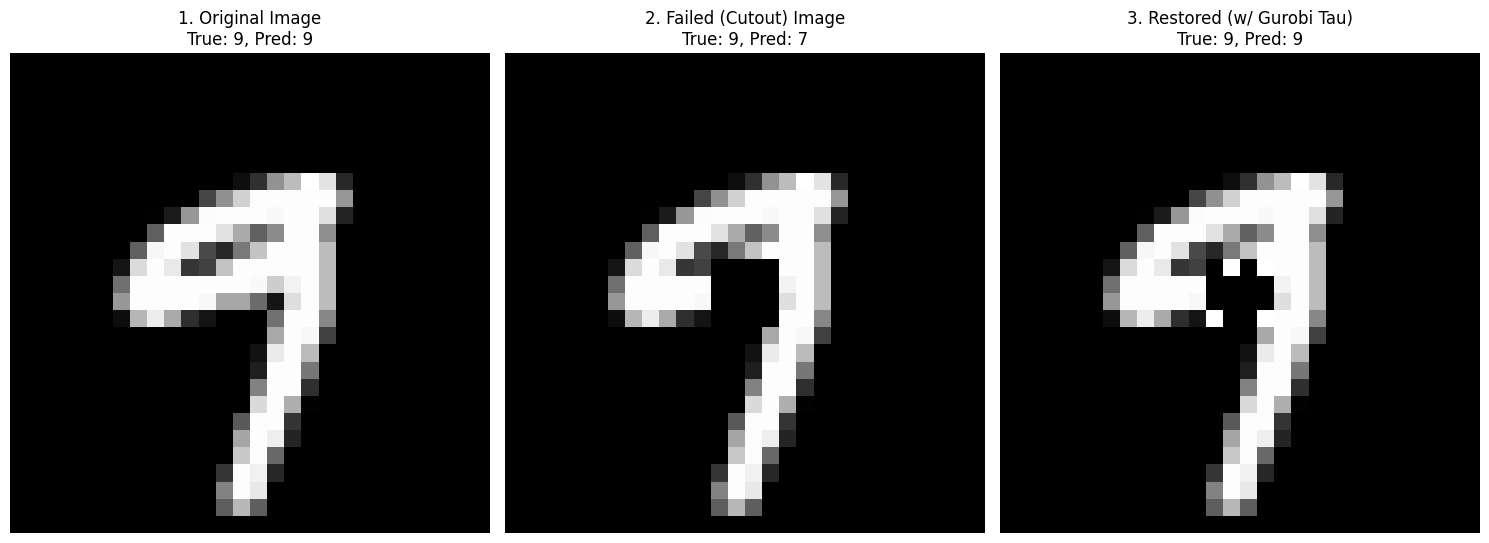


--- TEST 92/100: Image Index 839 ---
Running Gurobi to find corrective 'tau' patch for target 8...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 839 - True Label: 8
  Prediction (Original): 8 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 8 (Correct)
----------------------------------------


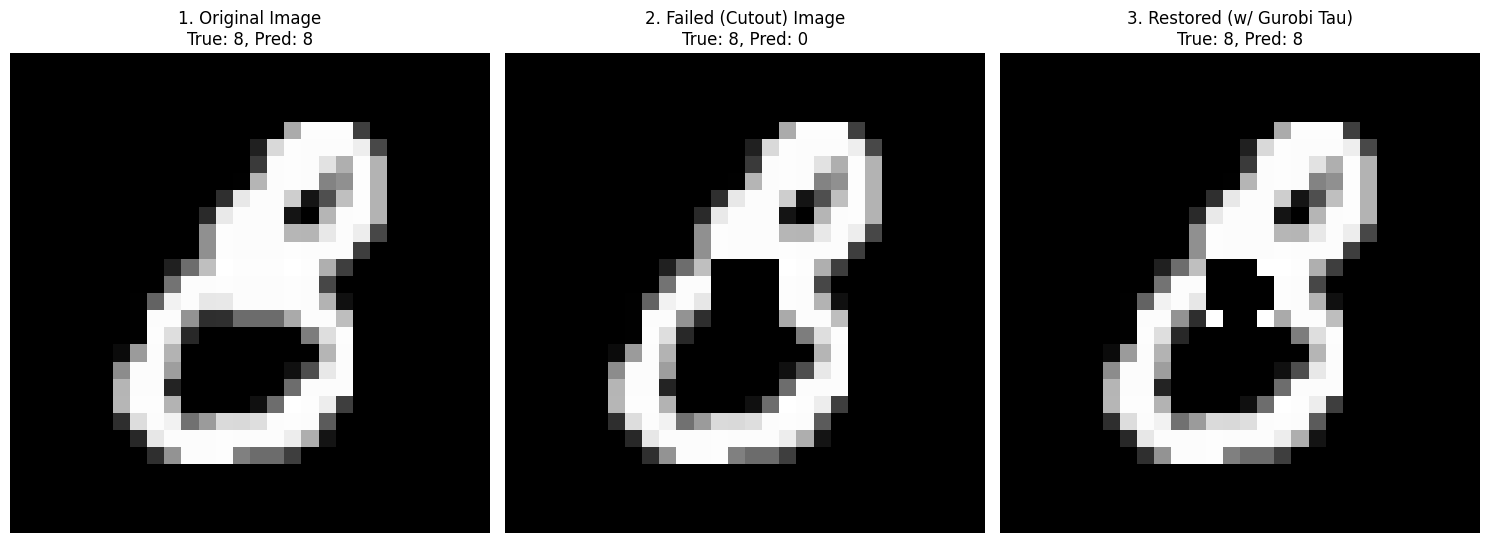


--- TEST 93/100: Image Index 87 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 87 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


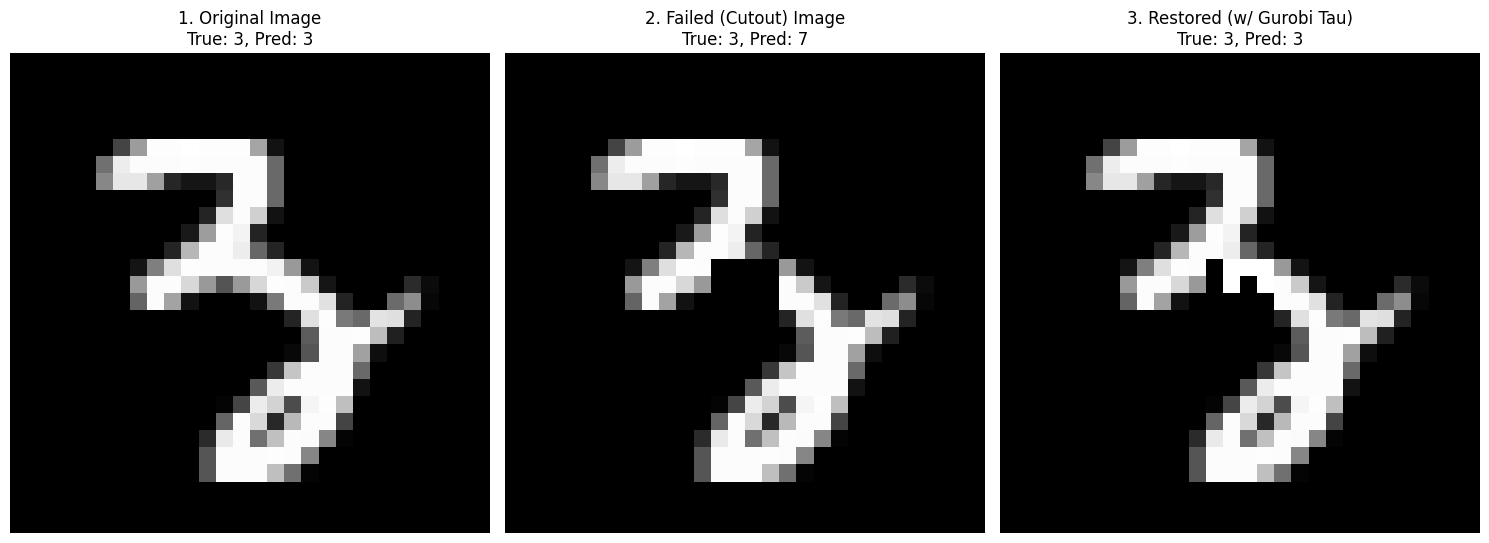


--- TEST 94/100: Image Index 894 ---
Running Gurobi to find corrective 'tau' patch for target 3...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 894 - True Label: 3
  Prediction (Original): 3 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 3 (Correct)
----------------------------------------


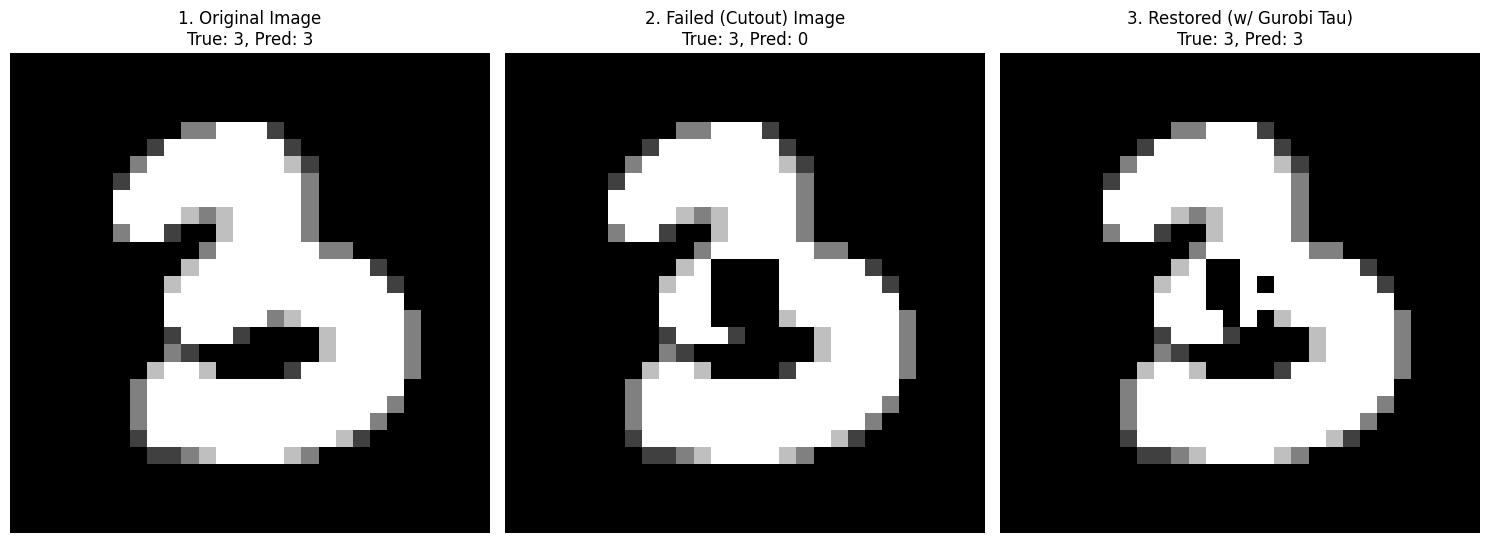


--- TEST 95/100: Image Index 9 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 9 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


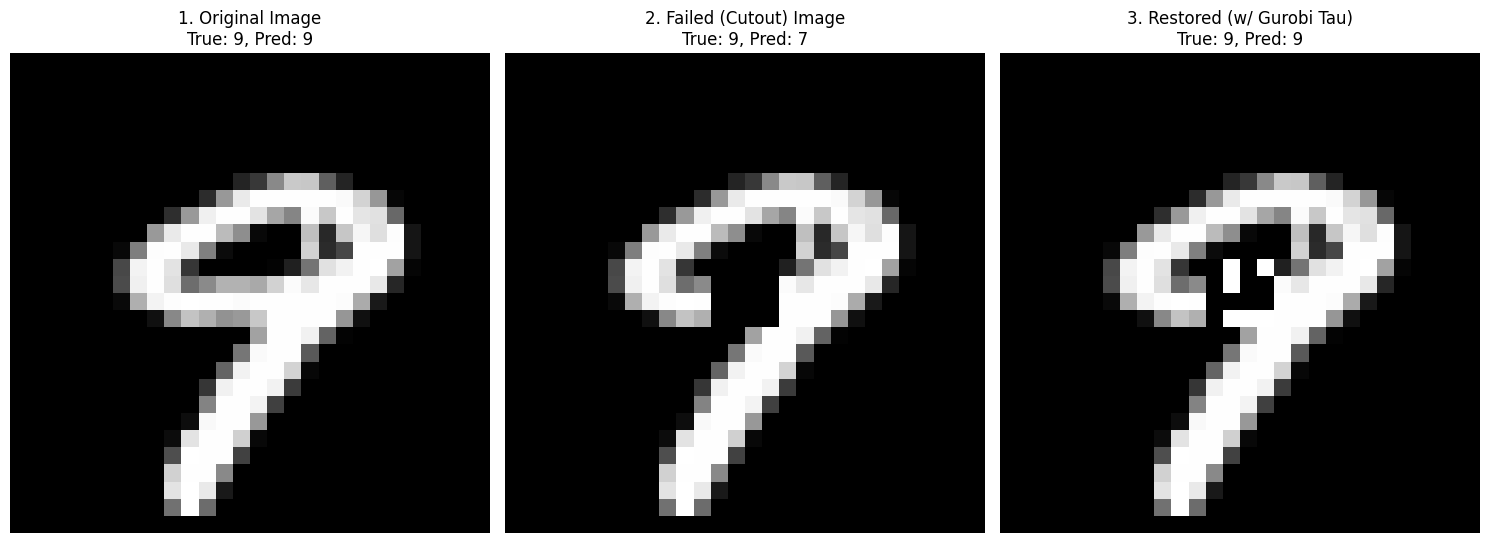


--- TEST 96/100: Image Index 920 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 920 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   4 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


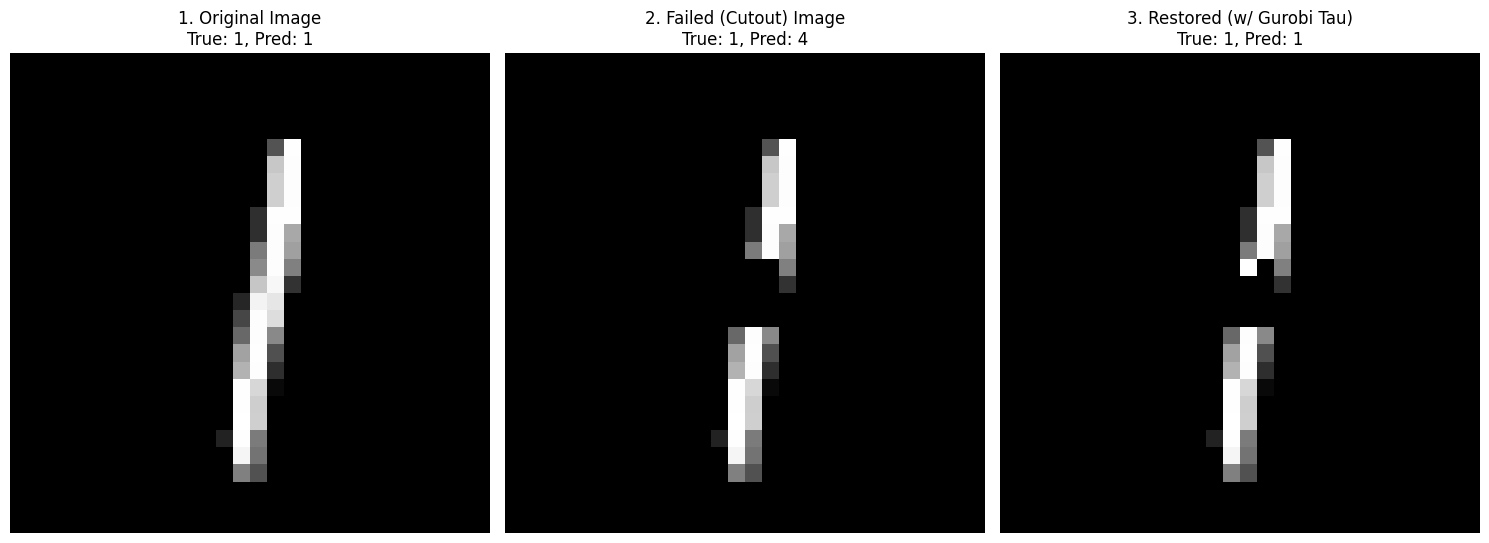


--- TEST 97/100: Image Index 956 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 956 - True Label: 1
  Prediction (Original): 1 (Correct)
  Prediction (Failed):   2 (Incorrect)
  Prediction (Restored): 1 (Correct)
----------------------------------------


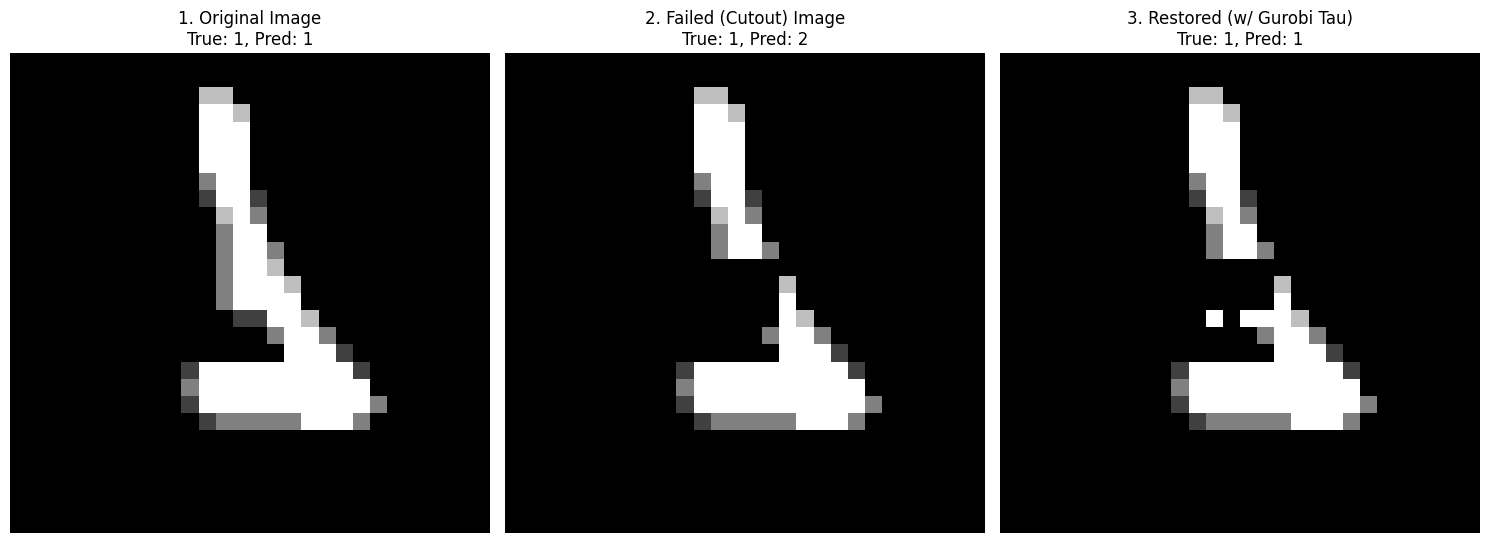


--- TEST 98/100: Image Index 962 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 962 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


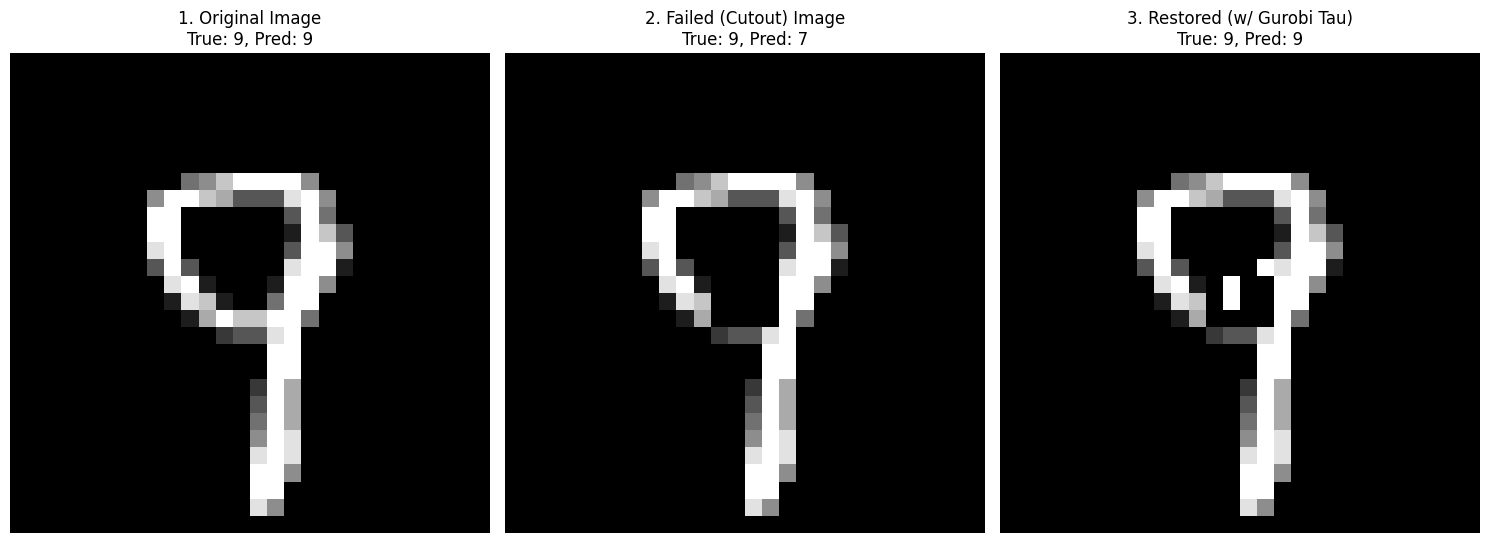


--- TEST 99/100: Image Index 965 ---
Running Gurobi to find corrective 'tau' patch for target 6...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 965 - True Label: 6
  Prediction (Original): 6 (Correct)
  Prediction (Failed):   0 (Incorrect)
  Prediction (Restored): 6 (Correct)
----------------------------------------


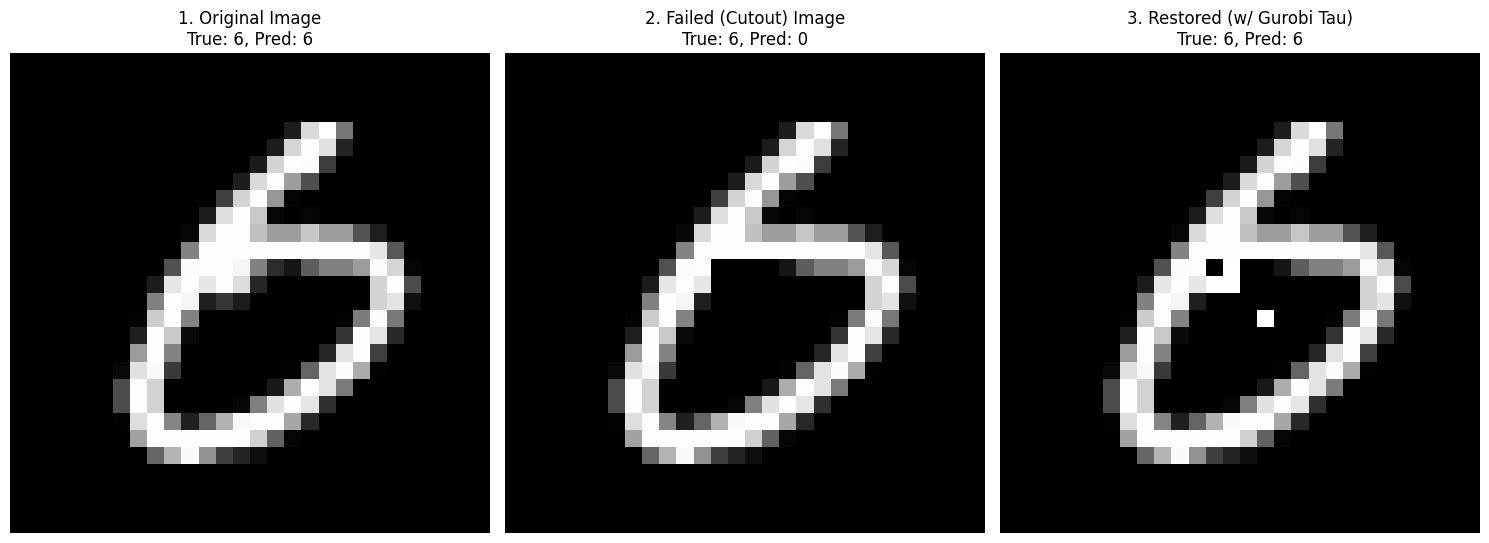


--- TEST 100/100: Image Index 966 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28750 continuous, 16 integer (16 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi found a solution. Preparing comparison...

----------------------------------------
Image 966 - True Label: 9
  Prediction (Original): 9 (Correct)
  Prediction (Failed):   7 (Incorrect)
  Prediction (Restored): 9 (Correct)
----------------------------------------


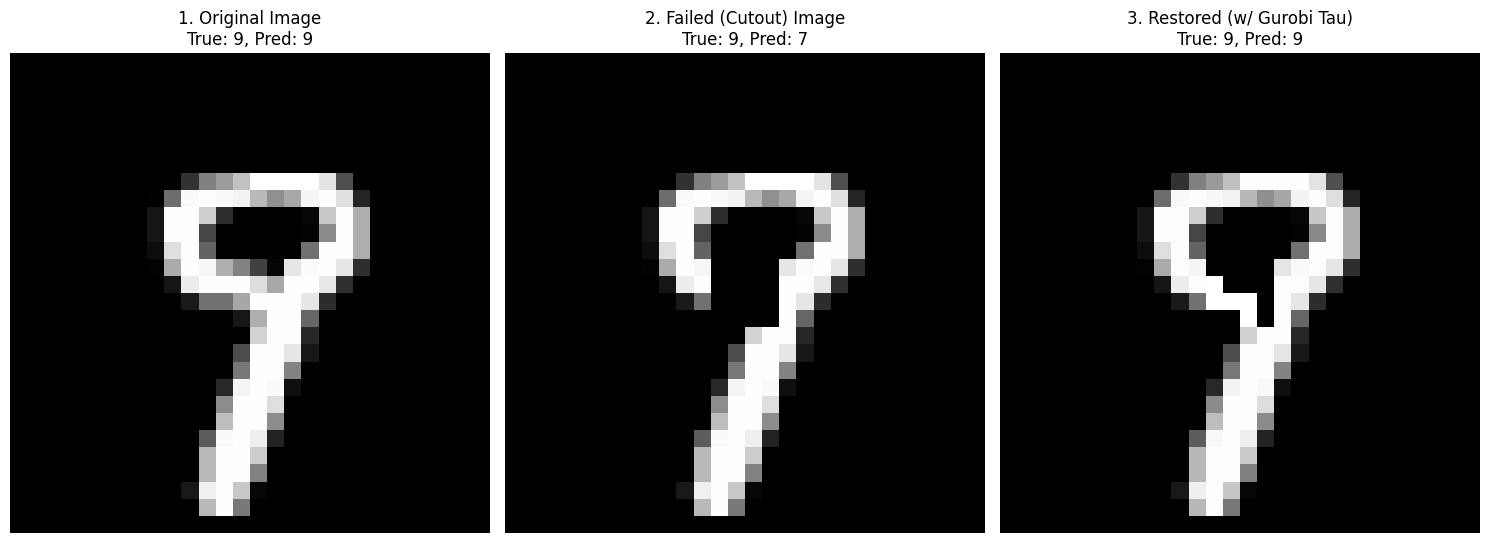

Total Images Processed: 100
  Gurobi Found a Fix (Success):   86
  Gurobi Failed (Infeasible/Timeout): 14
  Gurobi/Code Error:            0
---
Keras Confirmed Correct: 86
Restoration Accuracy: 86 / 100 = 86.00%


In [ ]:
print("\n 9. Running Full Verification Test on Multiple Images for binarised TAU")

#1 Find all available failed images
data_folder = "./cnn_failures/"
failed_images_to_test = []

if not os.path.exists(data_folder) or not os.listdir(data_folder):
    print(f"Error: Folder '{data_folder}' is empty or does not exist.")
    print("Please run Block 10 (generate_cutout_images_cnn) first.")
else:
    for filename in os.listdir(data_folder):
        if filename.startswith("failed_image_") and filename.endswith(".npy"):
            try:
                image_index_str = filename.split('_')[-1].split('.')[0]
                image_index = int(image_index_str)

                label_path = os.path.join(data_folder, f"failed_label_{image_index}.npy")
                image_path = os.path.join(data_folder, filename)

                if os.path.exists(label_path):
                    true_label = np.load(label_path).item()
                    failed_images_to_test.append((image_index, image_path, true_label))
                else:
                    print(f"Warning: Found image {filename} but missing label file. Skipping.")

            except Exception as e:
                print(f"Could not parse index from {filename}: {e}")

# 2. Set processing limit
num_to_process = len(failed_images_to_test)

if num_to_process == 0:
    print("No failed image files found in 'cnn_failures/'.")
    print("Please run Block 10 to generate these files first.")
else:
    print(f"Found {len(failed_images_to_test)} failed images. Processing all of them...")

    cor = 0 # "Corrected" / "Fixed"
    incor = 0 # "Gurobi Failed"
    unclassified = 0 # "Infeasible" or "Timeout"
    cnt = 0

    restored_correctly_count = 0

    # 3. Loop through each failed image and run the test
    for i in range(num_to_process):

        image_index, failed_image_path, true_label = failed_images_to_test[i]
        cnt += 1

        print("\n" + "="*50)
        print(f"--- TEST {i+1}/{num_to_process}: Image Index {image_index} ---")
        print("="*50)

        # a. The original (non-cutout) image from the test set
        original_image = x_test[image_index]

        # b. The failed (cutout) image
        failed_image = np.load(failed_image_path)

        # 5. Run Gurobi to get the corrective 'tau' patch
        print(f"Running Gurobi to find corrective 'tau' patch for target {true_label}...")

        # This now calls the GENERALIZED function. this we have defined above
        (tau_values, gurobi_prediction) = model_encoding(failed_image, true_label, num_conv_layers=N_LAYERS,tauType=0)

        if tau_values is not None:
            print("Gurobi found a solution. Preparing comparison...")

            # 6. Create the Restored image
            grid_size = 4 # Updated
            x_centre, y_centre = 14, 14
            grid_bound = grid_size // 2
            start_x, start_y = x_centre - grid_bound, y_centre - grid_bound

            tau_patch = np.array(tau_values).reshape(grid_size, grid_size)
            restored_image = failed_image.copy()
            restored_image[start_x:start_x + grid_size, start_y:start_y + grid_size, 0] += tau_patch
            restored_image = np.clip(restored_image, 0, 1)

            # 7. Get Predictions for all 3 images i.e. original vs perturbed vs restored
            def get_pred(image):
                img_batch = np.expand_dims(image, axis=0)
                pred = model_cnn.predict(img_batch, verbose=0)
                return np.argmax(pred)

            pred_original = get_pred(original_image)
            pred_failed = get_pred(failed_image)
            pred_restored = get_pred(restored_image)

            if pred_restored == true_label:
                restored_correctly_count += 1

            # results
            print("\n" + "-"*40)
            print(f"Image {image_index} - True Label: {true_label}")
            print(f"  Prediction (Original): {pred_original} {'(Correct)' if pred_original == true_label else '(Incorrect)'}")
            print(f"  Prediction (Failed):   {pred_failed} {'(Correct)' if pred_failed == true_label else '(Incorrect)'}")
            print(f"  Prediction (Restored): {pred_restored} {'(Correct)' if pred_restored == true_label else '(Incorrect)'}")
            print("-"*40)

            plt.figure(figsize=(15, 6))
            plt.subplot(1, 3, 1)
            plt.imshow(original_image.squeeze(), cmap='gray')
            plt.title(f"1. Original Image\nTrue: {true_label}, Pred: {pred_original}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(failed_image.squeeze(), cmap='gray')
            plt.title(f"2. Failed (Cutout) Image\nTrue: {true_label}, Pred: {pred_failed}")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(restored_image.squeeze(), cmap='gray')
            plt.title(f"3. Restored (w/ Gurobi Tau)\nTrue: {true_label}, Pred: {pred_restored}")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            cor += 1

        else:
            print(f"Gurobi could not find a corrective patch for image {image_index}.")
            unclassified += 1 # Gurobi was INFEASIBLE or TIMED OUT

    # print("\n" + "="*30)
    # print("FINAL RESULTS")
    # print("="*30)
    # print(f"Success (Fixed)={cor}, Failed (Gurobi error)={incor}, Unclassified (Not-Fixed)={unclassified}, Total={cnt}")
    # print(f"Total Processed Files: {cnt}")

    print(f"Total Images Processed: {cnt}")
    print(f"  Gurobi Found a Fix (Success):   {cor}")
    print(f"  Gurobi Failed (Infeasible/Timeout): {unclassified}")
    print(f"  Gurobi/Code Error:            {incor}")
    print(f"---")
    print(f"Keras Confirmed Correct: {restored_correctly_count}")

    if cnt > 0:
        accuracy = (restored_correctly_count / cnt) * 100
        print(f"Restoration Accuracy: {restored_correctly_count} / {cnt} = {accuracy:.2f}%")
    else:
        print("Restoration Accuracy: N/A (no images processed)")

In [ ]:
print("\n 10. Running Full Verification Test on Multiple Images for continuous TAU")

#1 Find all available failed images
data_folder = "./cnn_failures/"
failed_images_to_test = []

if not os.path.exists(data_folder) or not os.listdir(data_folder):
    print(f"Error: Folder '{data_folder}' is empty or does not exist.")
    print("Please run Block 10 (generate_cutout_images_cnn) first.")
else:
    for filename in os.listdir(data_folder):
        if filename.startswith("failed_image_") and filename.endswith(".npy"):
            try:
                image_index_str = filename.split('_')[-1].split('.')[0]
                image_index = int(image_index_str)

                label_path = os.path.join(data_folder, f"failed_label_{image_index}.npy")
                image_path = os.path.join(data_folder, filename)

                if os.path.exists(label_path):
                    true_label = np.load(label_path).item()
                    failed_images_to_test.append((image_index, image_path, true_label))
                else:
                    print(f"Warning: Found image {filename} but missing label file. Skipping.")

            except Exception as e:
                print(f"Could not parse index from {filename}: {e}")

# 2. Set processing limit
num_to_process = len(failed_images_to_test)

if num_to_process == 0:
    print("No failed image files found in 'cnn_failures/'.")
    print("Please run Block 10 to generate these files first.")
else:
    print(f"Found {len(failed_images_to_test)} failed images. Processing all of them...")

    cor = 0 # "Corrected" / "Fixed"
    incor = 0 # "Gurobi Failed"
    unclassified = 0 # "Infeasible" or "Timeout"
    cnt = 0

    restored_correctly_count = 0

    # 3. Loop through each failed image and run the test
    for i in range(num_to_process):

        image_index, failed_image_path, true_label = failed_images_to_test[i]
        cnt += 1

        print("\n" + "="*50)
        print(f"--- TEST {i+1}/{num_to_process}: Image Index {image_index} ---")
        print("="*50)

        # a. The original (non-cutout) image from the test set
        original_image = x_test[image_index]

        # b. The failed (cutout) image
        failed_image = np.load(failed_image_path)

        # 5. Run Gurobi to get the corrective 'tau' patch
        print(f"Running Gurobi to find corrective 'tau' patch for target {true_label}...")

        # This now calls the GENERALIZED function. this we have defined above
        (tau_values, gurobi_prediction) = model_encoding(failed_image, true_label, num_conv_layers=N_LAYERS,tauType=1)

        if tau_values is not None:
            print("Gurobi found a solution. Preparing comparison...")

            # 6. Create the Restored image
            grid_size = 4 # Updated
            x_centre, y_centre = 14, 14
            grid_bound = grid_size // 2
            start_x, start_y = x_centre - grid_bound, y_centre - grid_bound

            tau_patch = np.array(tau_values).reshape(grid_size, grid_size)
            restored_image = failed_image.copy()
            restored_image[start_x:start_x + grid_size, start_y:start_y + grid_size, 0] += tau_patch
            restored_image = np.clip(restored_image, 0, 1)

            # 7. Get Predictions for all 3 images i.e. original vs perturbed vs restored
            def get_pred(image):
                img_batch = np.expand_dims(image, axis=0)
                pred = model_cnn.predict(img_batch, verbose=0)
                return np.argmax(pred)

            pred_original = get_pred(original_image)
            pred_failed = get_pred(failed_image)
            pred_restored = get_pred(restored_image)

            if pred_restored == true_label:
                restored_correctly_count += 1

            # results
            print("\n" + "-"*40)
            print(f"Image {image_index} - True Label: {true_label}")
            print(f"  Prediction (Original): {pred_original} {'(Correct)' if pred_original == true_label else '(Incorrect)'}")
            print(f"  Prediction (Failed):   {pred_failed} {'(Correct)' if pred_failed == true_label else '(Incorrect)'}")
            print(f"  Prediction (Restored): {pred_restored} {'(Correct)' if pred_restored == true_label else '(Incorrect)'}")
            print("-"*40)

            plt.figure(figsize=(15, 6))
            plt.subplot(1, 3, 1)
            plt.imshow(original_image.squeeze(), cmap='gray')
            plt.title(f"1. Original Image\nTrue: {true_label}, Pred: {pred_original}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(failed_image.squeeze(), cmap='gray')
            plt.title(f"2. Failed (Cutout) Image\nTrue: {true_label}, Pred: {pred_failed}")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(restored_image.squeeze(), cmap='gray')
            plt.title(f"3. Restored (w/ Gurobi Tau)\nTrue: {true_label}, Pred: {pred_restored}")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            cor += 1

        else:
            print(f"Gurobi could not find a corrective patch for image {image_index}.")
            unclassified += 1 # Gurobi was INFEASIBLE or TIMED OUT

    # print("\n" + "="*30)
    # print("FINAL RESULTS")
    # print("="*30)
    # print(f"Success (Fixed)={cor}, Failed (Gurobi error)={incor}, Unclassified (Not-Fixed)={unclassified}, Total={cnt}")
    # print(f"Total Processed Files: {cnt}")

    print(f"Total Images Processed: {cnt}")
    print(f"  Gurobi Found a Fix (Success):   {cor}")
    print(f"  Gurobi Failed (Infeasible/Timeout): {unclassified}")
    print(f"  Gurobi/Code Error:            {incor}")
    print(f"---")
    print(f"Keras Confirmed Correct: {restored_correctly_count}")

    if cnt > 0:
        accuracy = (restored_correctly_count / cnt) * 100
        print(f"Restoration Accuracy: {restored_correctly_count} / {cnt} = {accuracy:.2f}%")
    else:
        print("Restoration Accuracy: N/A (no images processed)")


 10. Running Full Verification Test on Multiple Images for continuous TAU
Found 100 failed images. Processing all of them...

--- TEST 1/100: Image Index 1000 ---
Running Gurobi to find corrective 'tau' patch for target 9...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type                : MIP
  Linear constraint matrix    : 18243 rows, 28766 columns, 339316 nonzeros
  Variable types              : 28766 continuous, 0 integer (0 binary)
  General constraints         : 10584 constrs
  Matrix range                : [1e-05, 1e+00]
  Objective range             : [0e+00, 0e+00]
  Bounds range                : [1e+00, 1e+00]
  RHS range                   : [2e-03, 1e+00]
None
Starting Gurobi optimization...
Gurobi exited with status: 9
Gurobi could not find a corrective patch for image 1000.

--- TEST 2/100: Image Index 1004 ---
Running Gurobi to find corrective 'tau' patch for target 1...
Statistics for model 'CNN_Corrective_Encoding_ReLU_N2':
  Problem type         

KeyboardInterrupt: 